In [142]:
import seaborn as sns
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch,Pitch
events_df = sb.competition_events(
country="Germany",
division="1. Bundesliga",
season="2023/2024",
gender="male")
frames_df = sb.competition_frames(
country="Germany",
division="1. Bundesliga",
season="2023/2024",
gender="male")

frames_df.rename(columns={'event_uuid': 'id'}, inplace = True)
merged_df=pd.merge(frames_df, events_df,
how="left", on=["match_id","id"]) 

/opt/homebrew/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/statsbomb

In [228]:
# Print column names for events_df
print("Column names in events_df:")
for col in events_df.columns:
    print(col)

# Print column names for frames_df
print("Column names in frames_df:")
for col in frames_df.columns:
    print(col)

Column names in events_df:
50_50
bad_behaviour_card
ball_receipt_outcome
ball_recovery_offensive
ball_recovery_recovery_failure
block_deflection
block_offensive
block_save_block
carry_end_location
clearance_aerial_won
clearance_body_part
clearance_head
clearance_left_foot
clearance_other
clearance_right_foot
counterpress
dribble_no_touch
dribble_nutmeg
dribble_outcome
dribble_overrun
duel_outcome
duel_type
duration
foul_committed_advantage
foul_committed_card
foul_committed_offensive
foul_committed_penalty
foul_committed_type
foul_won_advantage
foul_won_defensive
foul_won_penalty
goalkeeper_body_part
goalkeeper_end_location
goalkeeper_outcome
goalkeeper_position
goalkeeper_punched_out
goalkeeper_shot_saved_off_target
goalkeeper_shot_saved_to_post
goalkeeper_success_in_play
goalkeeper_success_out
goalkeeper_technique
goalkeeper_type
id
index
injury_stoppage_in_chain
interception_outcome
location
match_id
minute
miscontrol_aerial_won
off_camera
out
pass_aerial_won
pass_angle
pass_assiste

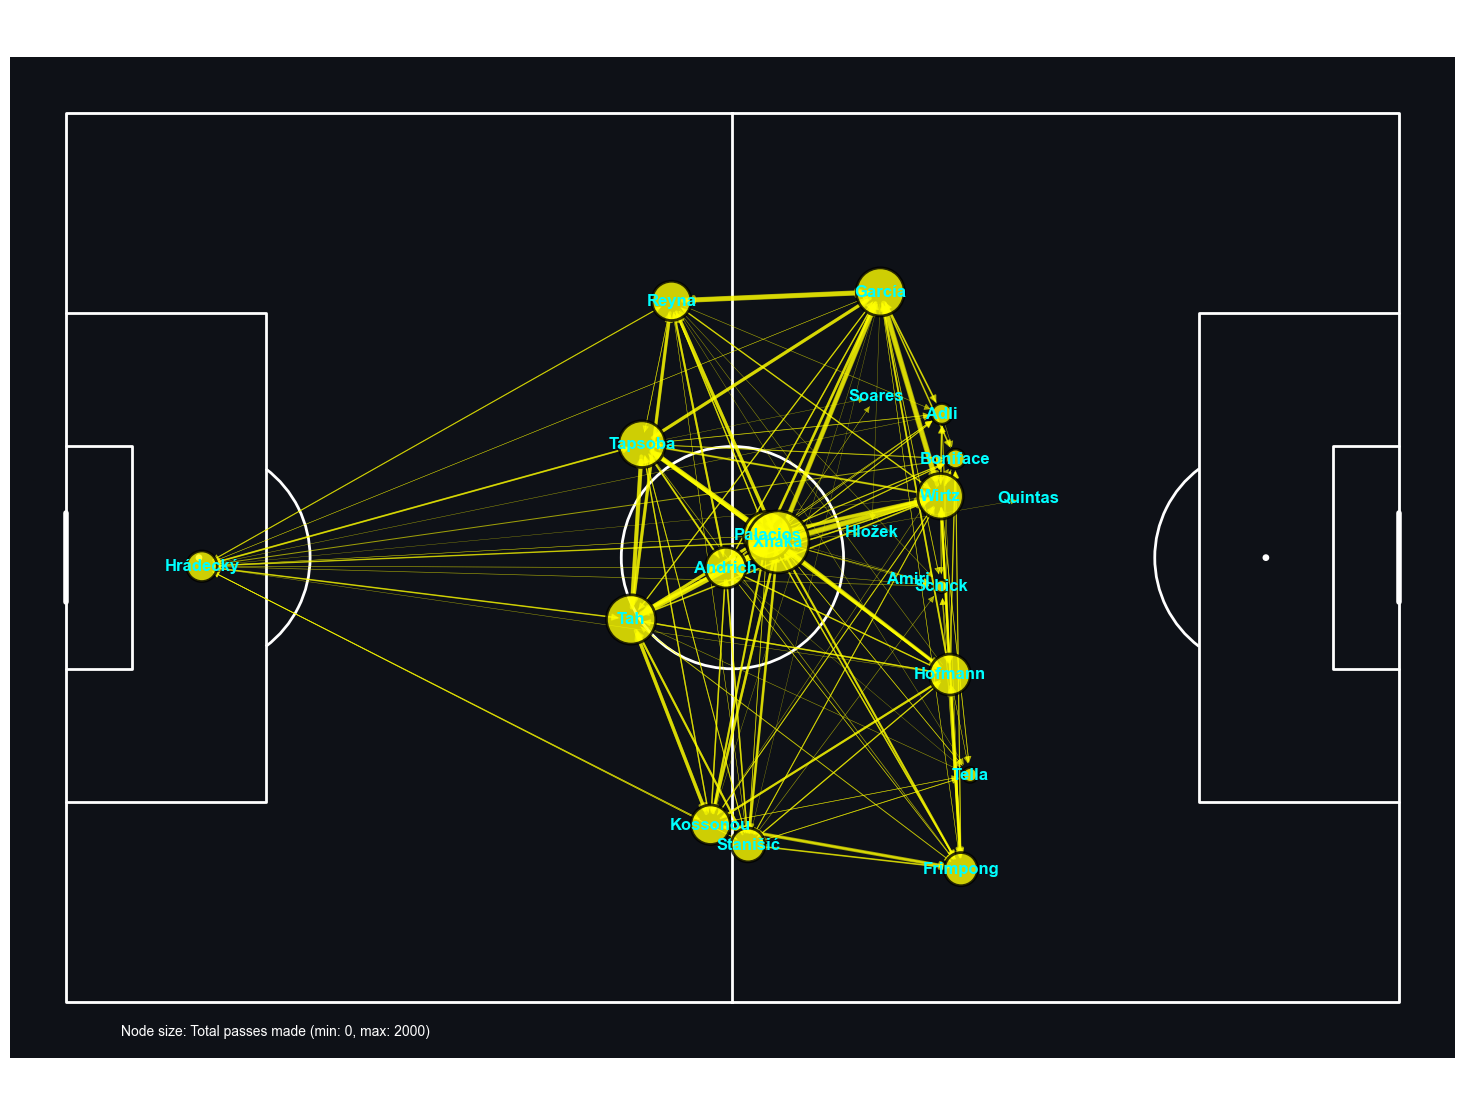


Top 5 passers:
Granit Xhaka: 3280 passes
Jonathan Tah: 2066 passes
Alejandro Grimaldo García: 1969 passes
Exequiel Alejandro Palacios: 1960 passes
Edmond Fayçal Tapsoba: 1854 passes

Top 5 pass combinations:
Exequiel Alejandro Palacios to Granit Xhaka: 467 passes
Granit Xhaka to Florian Wirtz: 393 passes
Jonathan Tah to Granit Xhaka: 385 passes
Alejandro Grimaldo García to Florian Wirtz: 370 passes
Granit Xhaka to Exequiel Alejandro Palacios: 356 passes


In [229]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mplsoccer import Pitch

# Filter passes for Bayer Leverkusen
team_name = 'Bayer Leverkusen'
team_passes = events_df[(events_df['team'] == team_name) & (events_df['type'] == 'Pass')]

# Create a DataFrame with pass connections
pass_connections = team_passes.groupby(['player', 'pass_recipient']).size().reset_index(name='pass_count')

# Create a directed graph
G = nx.DiGraph()

# Add nodes and edges (filter for significant connections)
min_passes = 20  # Increase the threshold to reduce clutter
for _, row in pass_connections.iterrows():
    if row['pass_count'] >= min_passes:
        G.add_edge(row['player'], row['pass_recipient'], weight=row['pass_count'])

# Calculate node sizes based on total passes made
node_sizes = dict(G.out_degree(weight='weight'))
max_passes = max(node_sizes.values())
node_sizes = {player: (count / max_passes) * 2000 for player, count in node_sizes.items()}  # Adjust size scaling

# Calculate node positions based on average player locations
player_positions = team_passes.groupby('player')['location'].apply(lambda x: np.mean(x.tolist(), axis=0)).to_dict()
pos = {player: (loc[0], 80 - loc[1]) for player, loc in player_positions.items() if player in G.nodes()}

# Create the plot
pitch = Pitch(pitch_type='statsbomb', pitch_color='#0E1117', line_color='white', stripe=False)
fig, ax = plt.subplots(figsize=(16, 11), constrained_layout=True)
pitch.draw(ax=ax)

# Draw edges
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_edge_weight = max(edge_weights)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='yellow', width=[w / max_edge_weight * 5 for w in edge_weights], alpha=0.6)

# Draw nodes
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=[node_sizes[node] for node in G.nodes()], node_color='yellow', edgecolors='black', linewidths=2, alpha=0.8)

# Simplify player labels to avoid clutter
labels = {node: node.split()[-1] for node in G.nodes()}  # Use last names only
nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=12, font_color='cyan', font_weight='bold')

# Customize the plot
ax.set_title(f"{team_name} Passing Network", fontsize=20, color='white', pad=20)
ax.set_xlim(-5, 125)
ax.set_ylim(-5, 85)

# Add a pitch outline
pitch_outline = plt.Rectangle((0, 0), 120, 80, fill=False, color='white')
ax.add_patch(pitch_outline)

# Add a legend
plt.text(5, -3, f"Node size: Total passes made (min: {min(node_sizes.values()):.0f}, max: {max(node_sizes.values()):.0f})", color='white')
plt.text(5, -7, f"Edge thickness: Passes between players (min: {min_passes}, max: {max_edge_weight})", color='white')

plt.tight_layout()
plt.show()

# Print top passers and pass combinations
top_passers = sorted(node_sizes.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 passers:")
for player, size in top_passers:
    print(f"{player}: {G.out_degree(player, weight='weight')} passes")

top_combinations = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
print("\nTop 5 pass combinations:")
for passer, receiver, data in top_combinations:
    print(f"{passer} to {receiver}: {data['weight']} passes")

In [144]:
import matplotlib.pyplot as plt

In [145]:
# Define the list of event types to include
touches = [
    'Shot', 'Foul Won', 'Miscontrol', 'Ball Receipt*', 'Carry', 
    'Block', 'Clearance', 'Duel'
]

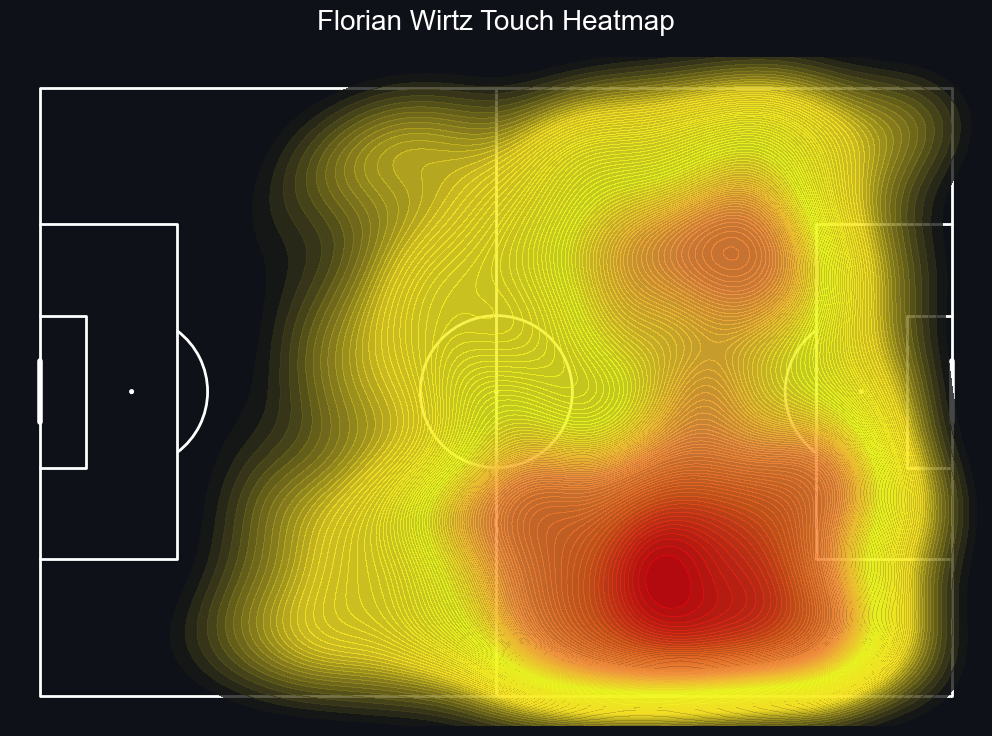

In [146]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import seaborn as sns

# Filter events for 'Florian Wirtz'
wirtz_events = events_df[
    (events_df['player'] == 'Florian Wirtz') & 
    (events_df['type'].isin(touches))
]

# Extract locations of touches
touch_locations = wirtz_events['location'].dropna().tolist()

# Separate x and y coordinates
x_coords = [loc[0] for loc in touch_locations]
y_coords = [loc[1] for loc in touch_locations]

# Set up the pitch using StatsBomb dimensions
pitch = Pitch(pitch_type='statsbomb', pitch_color='#0E1117', line_color='white', stripe=False)
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#0E1117')

# Create custom colormap
colors = ['#0E1117', '#fde725', '#f0f921', '#f89540', '#e8601c', '#dc050c']
n_bins = 256
cmap = plt.cm.colors.LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

# KDE plot parameters
kde = sns.kdeplot(
    x=x_coords,
    y=y_coords,
    cmap=cmap,
    fill=True,  # Use 'fill' instead of 'shade' for modern seaborn versions
    cbar=False,
    ax=ax,
    zorder=2,
    alpha=0.8,  # Increased alpha for more vibrant colors
    levels=100,  # Increased levels for smoother gradients
    thresh=0.03  # Lowered thresh to show more of the heatmap
)

# Flip the y-axis
ax.invert_yaxis()

# Remove axis labels and ticks
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

# Add title
ax.set_title('Florian Wirtz Touch Heatmap', fontsize=20, color='white', pad=20)

# Adjust layout and display the plot
plt.tight_layout(pad=3)
plt.show()

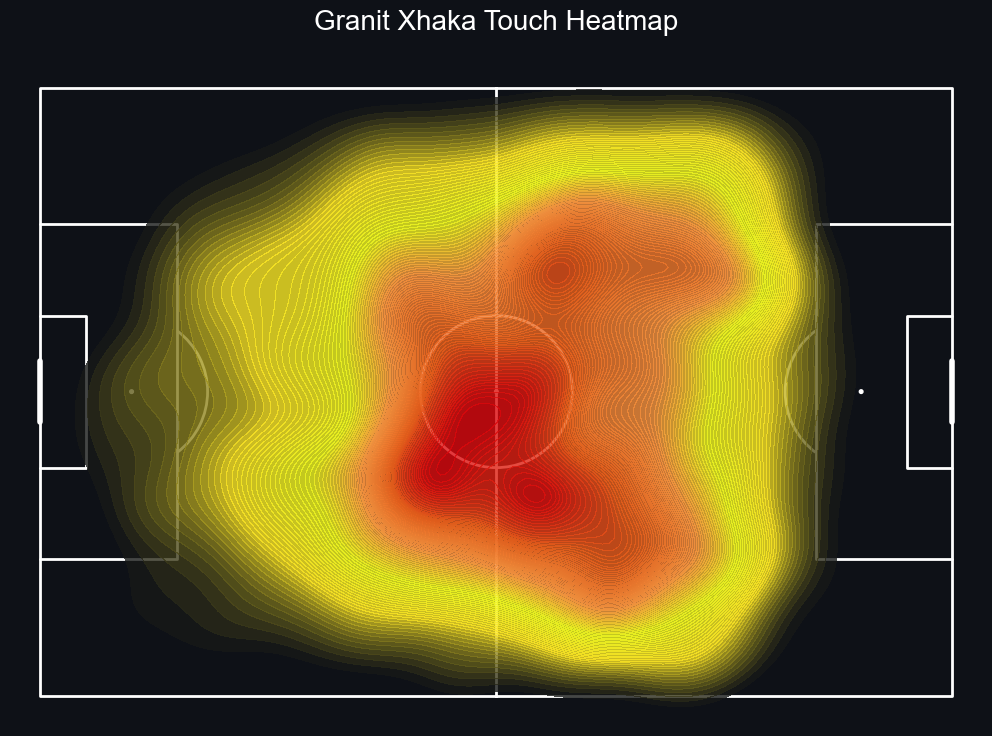

In [147]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import seaborn as sns

# Filter events for 'Granit Xhaka'
xhaka_events = events_df[
    (events_df['player'] == 'Granit Xhaka') & 
    (events_df['type'].isin(touches))
]

# Extract locations of touches
touch_locations = xhaka_events['location'].dropna().tolist()

# Separate x and y coordinates
x_coords = [loc[0] for loc in touch_locations]
y_coords = [loc[1] for loc in touch_locations]

# Set up the pitch using StatsBomb dimensions
pitch = Pitch(pitch_type='statsbomb', pitch_color='#0E1117', line_color='white', stripe=False)
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#0E1117')

# Create custom colormap
colors = ['#0E1117', '#fde725', '#f0f921', '#f89540', '#e8601c', '#dc050c']
n_bins = 256
cmap = plt.cm.colors.LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

# KDE plot parameters
kde = sns.kdeplot(
    x=x_coords,
    y=y_coords,
    cmap=cmap,
    fill=True,  # Use 'fill' instead of 'shade' for modern seaborn versions
    cbar=False,
    ax=ax,
    zorder=2,
    alpha=0.8,  # Increased alpha for more vibrant colors
    levels=100,  # Increased levels for smoother gradients
    thresh=0.03  # Lowered thresh to show more of the heatmap
)

# Flip the y-axis
ax.invert_yaxis()

# Remove axis labels and ticks
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

# Add title
ax.set_title('Granit Xhaka Touch Heatmap', fontsize=20, color='white', pad=20)

# Adjust layout and display the plot
plt.tight_layout(pad=3)
plt.show()

type
Ball Receipt*    3098
Carry            2771
Duel               69
Block              65
Foul Won           49
Clearance          46
Shot               44
Miscontrol         23
Name: count, dtype: int64


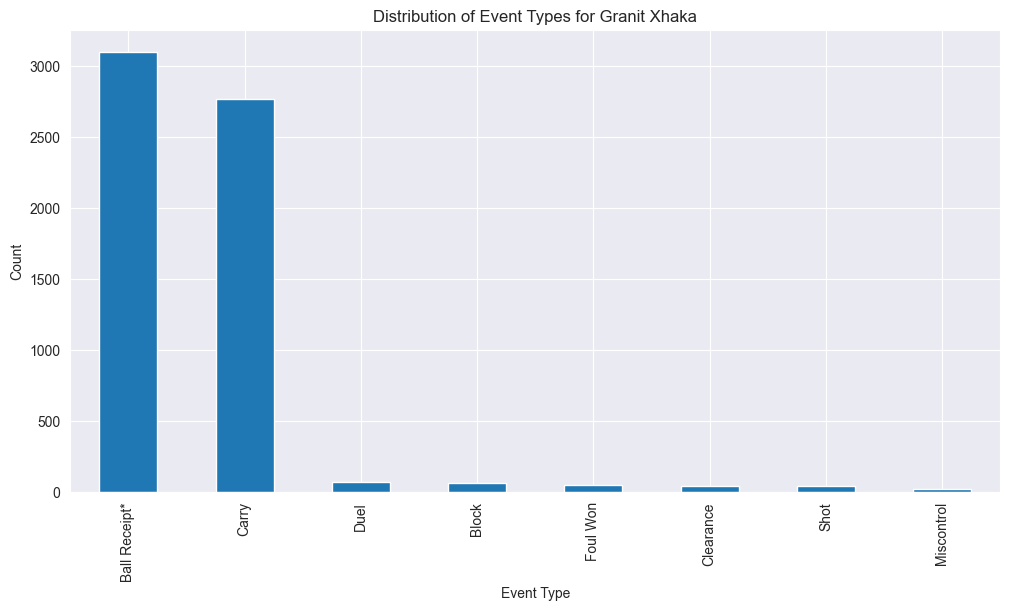

In [148]:
# Count the number of each event type for Granit Xhaka
event_counts = xhaka_events['type'].value_counts()
print(event_counts)

# Plot the distribution of event types
event_counts.plot(kind='bar', figsize=(12, 6), title='Distribution of Event Types for Granit Xhaka')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.show()

In [149]:
# Filter events for 'Granit Xhaka'
xhaka_events = events_df[events_df['player'] == 'Granit Xhaka']

# Filter for pass events
passes = xhaka_events[xhaka_events['type'] == 'Pass']

# Check if any pass events are found
if passes.empty:
    print("No pass events found for Granit Xhaka.")
else:
    print(f"Number of pass events found: {passes.shape[0]}")
    print(passes.head())


Number of pass events found: 3299
    50_50 bad_behaviour_card ball_receipt_outcome ball_recovery_offensive  \
221   NaN                NaN                  NaN                     NaN   
230   NaN                NaN                  NaN                     NaN   
232   NaN                NaN                  NaN                     NaN   
243   NaN                NaN                  NaN                     NaN   
248   NaN                NaN                  NaN                     NaN   

    ball_recovery_recovery_failure block_deflection block_offensive  \
221                            NaN              NaN             NaN   
230                            NaN              NaN             NaN   
232                            NaN              NaN             NaN   
243                            NaN              NaN             NaN   
248                            NaN              NaN             NaN   

    block_save_block carry_end_location clearance_aerial_won  ...  \
221    

In [10]:
  # Calculate pass accuracy
total_passes = passes.shape[0]
successful_passes = passes[passes['pass_outcome'].isna()].shape[0]
pass_accuracy = successful_passes / total_passes * 100
print(f"Pass Accuracy: {pass_accuracy:.2f}%")


Pass Accuracy: 92.30%


In [150]:
# Calculate total passes
total_passes = passes.shape[0]

# Calculate successful passes
successful_passes = passes[passes['pass_outcome'].isna()].shape[0]

# Calculate unsuccessful passes
unsuccessful_passes = passes[~passes['pass_outcome'].isna()].shape[0]

# Calculate pass accuracy
if total_passes > 0:
    pass_accuracy = successful_passes / total_passes * 100
    unsuccessful_pass_percentage = unsuccessful_passes / total_passes * 100
    print(f"Pass Accuracy: {pass_accuracy:.2f}%")
    print(f"Unsuccessful Pass Percentage: {unsuccessful_pass_percentage:.2f}%")
else:
    print("No pass events found for Granit Xhaka.")

Pass Accuracy: 92.30%
Unsuccessful Pass Percentage: 7.70%


In [12]:
# Filter events for 'Granit Xhaka'
xhaka_events = events_df[events_df['player'] == 'Granit Xhaka']

# Get unique match IDs
unique_match_ids = xhaka_events['match_id'].unique()

# Print unique match IDs
print("Unique match IDs for Granit Xhaka:")
print(unique_match_ids)

# Print the number of unique matches
print(f"Number of unique matches: {len(unique_match_ids)}")

Unique match IDs for Granit Xhaka:
[3895302 3895292 3895333 3895340 3895348 3895286 3895220 3895250 3895266
 3895275 3895180 3895134 3895121 3895107 3895074 3895139 3895086 3895309
 3895258 3895244 3895232 3895210 3895202 3895194 3895182 3895167 3895158
 3895153 3895113 3895095 3895067 3895060 3895052]
Number of unique matches: 33


In [151]:
   opponents = {}

In [152]:
   for match_id in unique_match_ids:
       # Filter events for the specific match
       match_events = events_df[events_df['match_id'] == match_id]
       
       # Get the teams involved in the match
       teams = match_events['team'].unique()
       
       # Identify Xhaka's team
       xhaka_team = xhaka_events[xhaka_events['match_id'] == match_id]['team'].iloc[0]
       
       # Identify the opponent team
       opponent_team = [team for team in teams if team != xhaka_team][0]
       
       # Store the opponent team in the dictionary
       opponents[match_id] = opponent_team

In [153]:
   print("Opponents for each match Granit Xhaka played in:")
   for match_id, opponent in opponents.items():
       print(f"Match ID: {match_id}, Opponent: {opponent}")

Opponents for each match Granit Xhaka played in:
Match ID: 3895302, Opponent: Werder Bremen
Match ID: 3895292, Opponent: Union Berlin
Match ID: 3895333, Opponent: Eintracht Frankfurt
Match ID: 3895340, Opponent: Bochum
Match ID: 3895348, Opponent: Augsburg
Match ID: 3895286, Opponent: Hoffenheim
Match ID: 3895220, Opponent: Darmstadt 98
Match ID: 3895250, Opponent: FSV Mainz 05
Match ID: 3895266, Opponent: Wolfsburg
Match ID: 3895275, Opponent: Freiburg
Match ID: 3895180, Opponent: Eintracht Frankfurt
Match ID: 3895134, Opponent: Hoffenheim
Match ID: 3895121, Opponent: Freiburg
Match ID: 3895107, Opponent: FC Köln
Match ID: 3895074, Opponent: Bayern Munich
Match ID: 3895139, Opponent: Union Berlin
Match ID: 3895086, Opponent: FC Heidenheim
Match ID: 3895309, Opponent: Borussia Dortmund
Match ID: 3895258, Opponent: FC Köln
Match ID: 3895244, Opponent: FC Heidenheim
Match ID: 3895232, Opponent: Bayern Munich
Match ID: 3895210, Opponent: Borussia Mönchengladbach
Match ID: 3895202, Opponen

In [154]:
   if 'x' not in events_df.columns:
       events_df[['x', 'y']] = events_df['location'].apply(pd.Series)

/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_88916/3769400664.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['x', 'y']] = events_df['location'].apply(pd.Series)
/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_88916/3769400664.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['x', 'y']] = events_df['location'].apply(pd.Series)


In [155]:
   if 'pass_end_x' not in events_df.columns:
       events_df[['pass_end_x', 'pass_end_y']] = events_df['pass_end_location'].apply(pd.Series)

/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_88916/807102536.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['pass_end_x', 'pass_end_y']] = events_df['pass_end_location'].apply(pd.Series)
/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_88916/807102536.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['pass_end_x', 'pass_end_y']] = events_df['pass_end_location'].apply(pd.Series)


In [156]:
   xhaka_f3rd_passes = events_df[
       (events_df['player'] == 'Granit Xhaka') & 
       (events_df['type'] == "Pass") & 
       (events_df['x'] < 80) & 
       (events_df['pass_end_x'] > 80)
   ]

In [157]:
xhaka_f3rd_passes_count = xhaka_f3rd_passes.shape[0]

In [158]:
print(f"Number of final third passes by Granit Xhaka: {xhaka_f3rd_passes_count}")

Number of final third passes by Granit Xhaka: 419


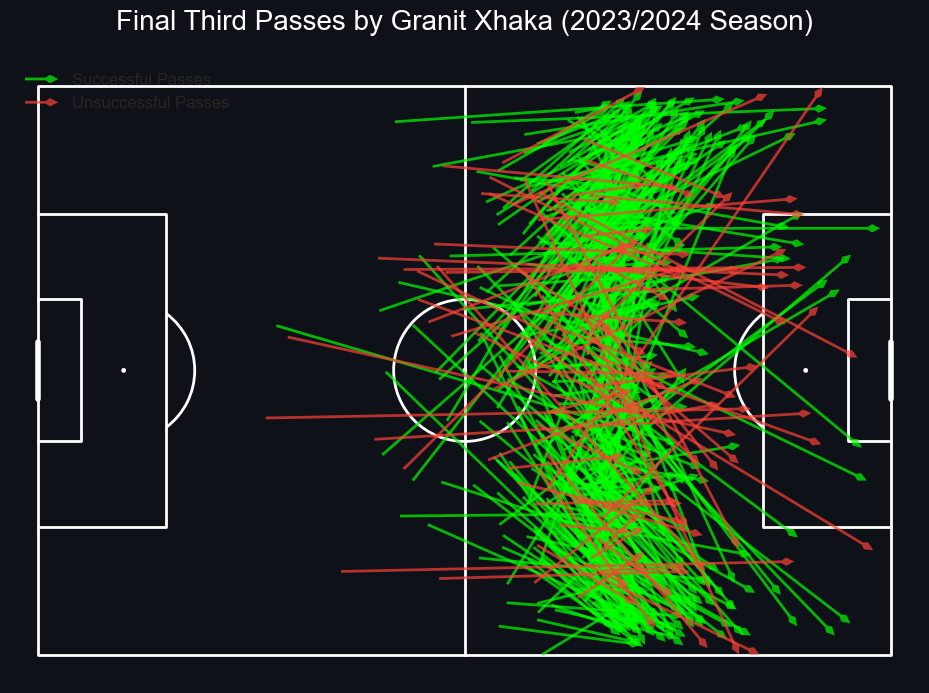

In [159]:
# Set up the pitch using StatsBomb dimensions
pitch = Pitch(pitch_type='statsbomb', pitch_color='#0E1117', line_color='white', stripe=False)
fig, ax = pitch.draw(figsize=(10, 7))
fig.set_facecolor('#0E1117')

# Plot successful passes
successful_passes = xhaka_f3rd_passes[xhaka_f3rd_passes['pass_outcome'].isna()]
pitch.arrows(successful_passes['x'], successful_passes['y'],
             successful_passes['pass_end_x'], successful_passes['pass_end_y'],
             ax=ax, color='#00FF00', width=2, headwidth=3, headlength=3, label='Successful Passes', alpha=0.7)

# Plot unsuccessful passes
unsuccessful_passes = xhaka_f3rd_passes[~xhaka_f3rd_passes['pass_outcome'].isna()]
pitch.arrows(unsuccessful_passes['x'], unsuccessful_passes['y'],
             unsuccessful_passes['pass_end_x'], unsuccessful_passes['pass_end_y'],
             ax=ax, color='#FF4136', width=2, headwidth=3, headlength=3, label='Unsuccessful Passes', alpha=0.7)

# Add title and legend
ax.set_title('Final Third Passes by Granit Xhaka (2023/2024 Season)', fontsize=20, color='white', pad=20)
ax.legend(loc='upper left', fontsize=12, frameon=False, facecolor='#0E1117', edgecolor='#0E1117')

# Show the plot
plt.tight_layout()
plt.show()

In [160]:
   wirtz_f3rd_passes = events_df[
       (events_df['player'] == 'Florian Wirtz') & 
       (events_df['type'] == "Pass") & 
       (events_df['x'] < 80) & 
       (events_df['pass_end_x'] > 80)
   ]

In [161]:
wirtz_f3rd_passes_count = wirtz_f3rd_passes.shape[0]
print(f"Number of final third passes by Florian Wirtz: {wirtz_f3rd_passes_count}")

Number of final third passes by Florian Wirtz: 153


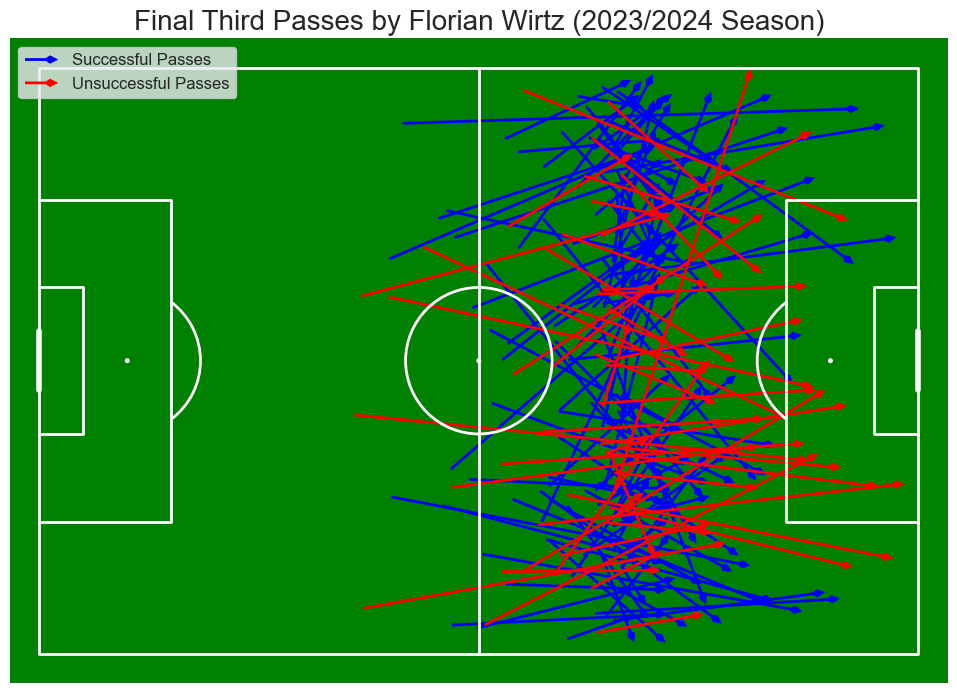

In [162]:
# Plot final third passes on a pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white', line_zorder=2)
fig, ax = pitch.draw(figsize=(10, 7))

# Plot successful passes
successful_passes = wirtz_f3rd_passes[wirtz_f3rd_passes['pass_outcome'].isna()]
pitch.arrows(successful_passes['x'], successful_passes['y'],
             successful_passes['pass_end_x'], successful_passes['pass_end_y'],
             ax=ax, color='blue', width=2, headwidth=3, headlength=3, label='Successful Passes')

# Plot unsuccessful passes
unsuccessful_passes = wirtz_f3rd_passes[~wirtz_f3rd_passes['pass_outcome'].isna()]
pitch.arrows(unsuccessful_passes['x'], unsuccessful_passes['y'],
             unsuccessful_passes['pass_end_x'], unsuccessful_passes['pass_end_y'],
             ax=ax, color='red', width=2, headwidth=3, headlength=3, label='Unsuccessful Passes')

# Add title and legend
ax.set_title('Final Third Passes by Florian Wirtz (2023/2024 Season)', fontsize=20)
ax.legend(loc='upper left', fontsize=12)

# Show the plot
plt.show()

In [163]:
# Extract carry_end_x and carry_end_y from carry_end_location
events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(lambda loc: pd.Series(loc) if isinstance(loc, list) else pd.Series([None, None]))

# Filter for carries by Granit Xhaka that start before the final third and end in the final third
xhaka_final_third_carries = events_df[
    (events_df['player'] == 'Granit Xhaka') & 
    (events_df['type'] == "Carry") & 
    (events_df['x'] < 80) & 
    (events_df['carry_end_x'] > 80)
]

# Count the number of such carries by Granit Xhaka
xhaka_final_third_carry_count = xhaka_final_third_carries.shape[0]

# Display the result
print(f"Number of final third carries by Granit Xhaka: {xhaka_final_third_carry_count}")

Number of final third carries by Granit Xhaka: 63


/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_88916/2851064281.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(lambda loc: pd.Series(loc) if isinstance(loc, list) else pd.Series([None, None]))
/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_88916/2851064281.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(lambda loc: pd.Series(loc) if is

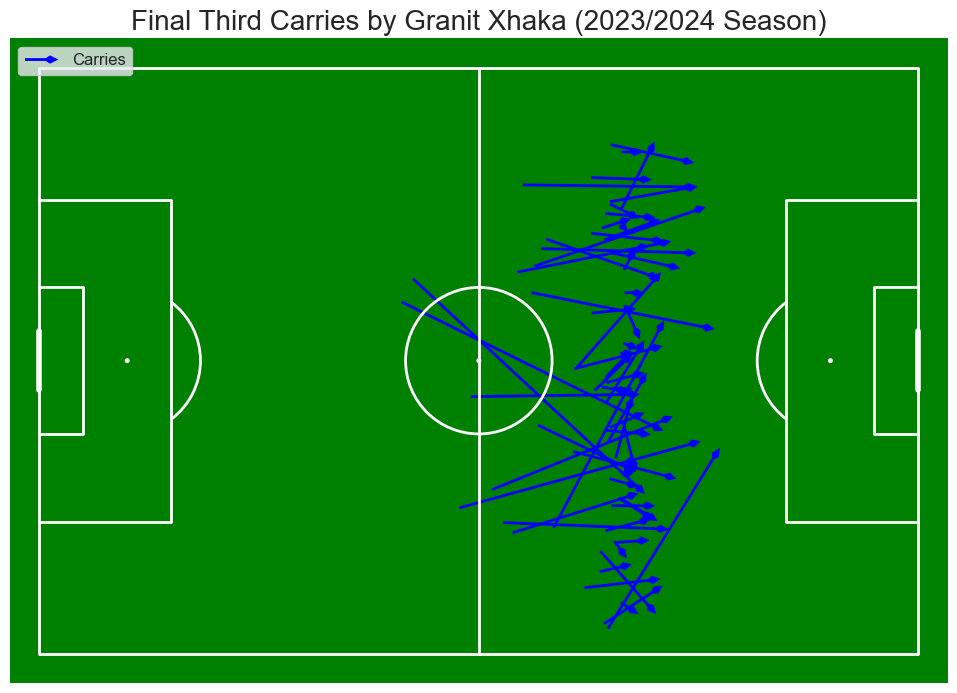

In [164]:
# Plot final third carries on a pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white', line_zorder=2)
fig, ax = pitch.draw(figsize=(10, 7))

# Plot carries
pitch.arrows(xhaka_final_third_carries['x'], xhaka_final_third_carries['y'],
             xhaka_final_third_carries['carry_end_x'], xhaka_final_third_carries['carry_end_y'],
             ax=ax, color='blue', width=2, headwidth=3, headlength=3, label='Carries')

# Add title and legend
ax.set_title('Final Third Carries by Granit Xhaka (2023/2024 Season)', fontsize=20)
ax.legend(loc='upper left', fontsize=12)

# Show the plot
plt.show()

In [165]:
# Extract carry_end_x and carry_end_y from carry_end_location
events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(lambda loc: pd.Series(loc) if isinstance(loc, list) else pd.Series([None, None]))

# Filter for carries by Granit Xhaka that start before the final third and end in the final third
wirtz_final_third_carries = events_df[
    (events_df['player'] == 'Florian Wirtz') & 
    (events_df['type'] == "Carry") & 
    (events_df['x'] < 80) & 
    (events_df['carry_end_x'] > 80)
]

# Count the number of such carries by Granit Xhaka
wirtz_final_third_carry_count = wirtz_final_third_carries.shape[0]

# Display the result
print(f"Number of final third carries by Florian Wirtz: {wirtz_final_third_carry_count}")

Number of final third carries by Florian Wirtz: 123


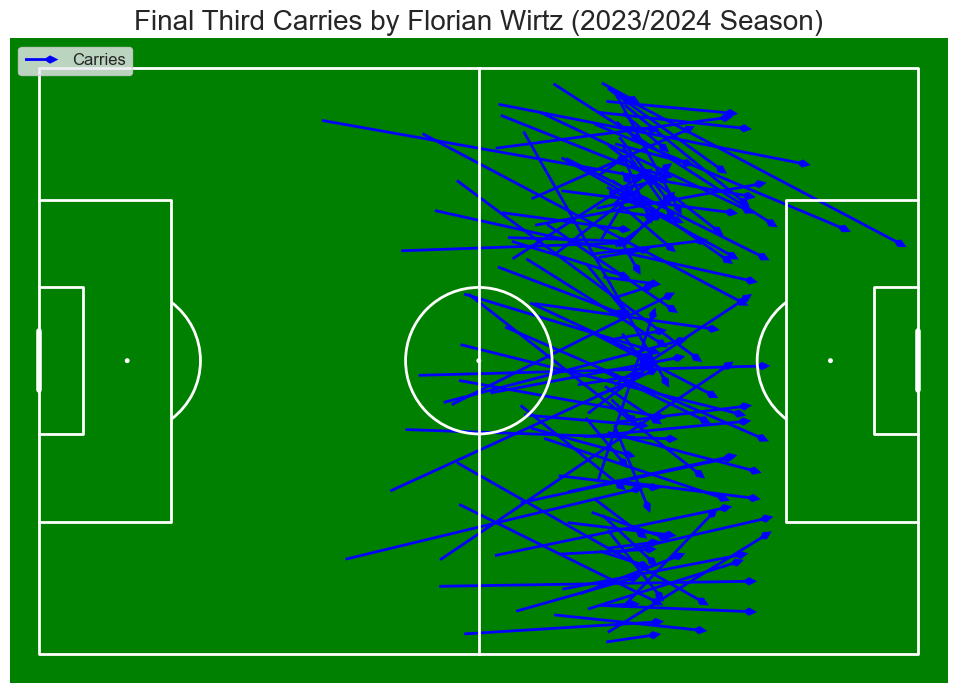

In [166]:
# Plot final third carries on a pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white', line_zorder=2)
fig, ax = pitch.draw(figsize=(10, 7))

# Plot carries
pitch.arrows(wirtz_final_third_carries['x'], wirtz_final_third_carries['y'],
             wirtz_final_third_carries['carry_end_x'], wirtz_final_third_carries['carry_end_y'],
             ax=ax, color='blue', width=2, headwidth=3, headlength=3, label='Carries')

# Add title and legend
ax.set_title('Final Third Carries by Florian Wirtz (2023/2024 Season)', fontsize=20)
ax.legend(loc='upper left', fontsize=12)

# Show the plot
plt.show()

In [167]:
# Filter passes in the final third
final_third_passes = events_df[
    (events_df['type'] == "Pass") & 
    (events_df['x'] < 80) & 
    (events_df['pass_end_x'] > 80)
]

# Count the number of final third passes by each player
final_third_passes_count = final_third_passes.groupby('player').size().reset_index(name='count')

# Display the results
print(final_third_passes_count)

                                 player  count
0                           Adam Hložek      7
1                           Adrian Beck      7
2                         Alassane Pléa      5
3             Alejandro Grimaldo García    127
4                   Aleksandar Pavlović      8
5                             Alex Král      5
6                       Alexander Nübel      2
7                       Alphonso Davies      7
8                             Amin Sarr      1
9                            Amine Adli     28
10                       Andreas Müller      2
11                      Andrej Kramarić      4
12                       András Schäfer      1
13                       Angelo Stiller      9
14                        Ansgar Knauff      2
15                         Anthony Caci     11
16                         Anthony Jung      6
17                      Anthony Losilla      5
18                      Anthony Rouault      2
19                          Anton Stach     15
20           

In [168]:
# Filter passes in the final third for Bayer Leverkusen players
final_third_passes = events_df[
    (events_df['type'] == "Pass") & 
    (events_df['x'] < 80) & 
    (events_df['pass_end_x'] > 80) & 
    (events_df['team'] == "Bayer Leverkusen")
]

# Count the number of final third passes by each player
final_third_passes_count = final_third_passes.groupby('player').size().reset_index(name='count')

# Sort the results in descending order
sorted_final_third_passes_count = final_third_passes_count.sort_values(by='count', ascending=False)

# Adjust display options to show all rows
pd.set_option('display.max_rows', None)

# Display the sorted results
print(sorted_final_third_passes_count)

                            player  count
8                     Granit Xhaka    419
5            Edmond Fayçal Tapsoba    222
6      Exequiel Alejandro Palacios    184
12                    Jonathan Tah    174
18                 Odilon Kossonou    164
7                    Florian Wirtz    153
21                  Robert Andrich    143
1        Alejandro Grimaldo García    127
20     Piero Martín Hincapié Reyna    118
11                   Jonas Hofmann    108
13                  Josip Stanišić    106
10                Jeremie Frimpong     36
14                  Lukáš Hrádecký     31
2                       Amine Adli     28
22            Victor Okoh Boniface     24
16                    Nathan Tella     12
15                    Nadiem Amiri      8
19                   Patrik Schick      8
0                      Adam Hložek      7
9     Gustavo Adolfo Puerta Molano      4
3   Arthur Augusto de Matos Soares      4
17                     Noah Mbamba      3
4           Borja Iglesias Quintas

In [170]:
 #Extract carry_end_x and carry_end_y from carry_end_location
events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(lambda loc: pd.Series(loc) if isinstance(loc, list) else pd.Series([None, None]))

# Filter carries for Bayer Leverkusen players that start before the final third and end in the final third
final_third_carries = events_df[
    (events_df['team'] == 'Bayer Leverkusen') & 
    (events_df['type'] == "Carry") & 
    (events_df['x'] < 80) & 
    (events_df['carry_end_x'] > 80)
]

# Count the number of final third carries by each player
final_third_carry_count = final_third_carries.groupby('player').size().reset_index(name='count')

# Sort the results in descending order
sorted_final_third_carry_count = final_third_carry_count.sort_values(by='count', ascending=False)

# Adjust display options to show all rows
pd.set_option('display.max_rows', None)

# Display the sorted results
print(sorted_final_third_carry_count)

                            player  count
7                    Florian Wirtz    123
10                Jeremie Frimpong     75
8                     Granit Xhaka     63
1        Alejandro Grimaldo García     60
11                   Jonas Hofmann     54
16                 Odilon Kossonou     51
5            Edmond Fayçal Tapsoba     51
18     Piero Martín Hincapié Reyna     45
13                  Josip Stanišić     43
20            Victor Okoh Boniface     31
6      Exequiel Alejandro Palacios     27
19                  Robert Andrich     25
2                       Amine Adli     23
12                    Jonathan Tah     19
15                    Nathan Tella     12
17                   Patrik Schick     11
0                      Adam Hložek      9
3   Arthur Augusto de Matos Soares      6
4           Borja Iglesias Quintas      3
14                    Nadiem Amiri      2
9     Gustavo Adolfo Puerta Molano      1


In [171]:
# Merge the two counts on player name
final_third_progressions = pd.merge(final_third_passes_count, final_third_carry_count, on='player', how='outer', suffixes=('_passes', '_carries')).fillna(0)

# Sum the counts of passes and carries to get total progressions
final_third_progressions['total_progressions'] = final_third_progressions['count_passes'] + final_third_progressions['count_carries']

# Sort the results in descending order
sorted_final_third_progressions = final_third_progressions.sort_values(by='total_progressions', ascending=False)

# Adjust display options to show all rows
pd.set_option('display.max_rows', None)

# Display the sorted results
print(sorted_final_third_progressions)

# Display the total count of final third progressions
total_progressions_count = sorted_final_third_progressions['total_progressions'].sum()
print(f"Total final third progressions for Bayer Leverkusen players: {total_progressions_count}")

                            player  count_passes  count_carries  \
8                     Granit Xhaka           419           63.0   
7                    Florian Wirtz           153          123.0   
5            Edmond Fayçal Tapsoba           222           51.0   
18                 Odilon Kossonou           164           51.0   
6      Exequiel Alejandro Palacios           184           27.0   
12                    Jonathan Tah           174           19.0   
1        Alejandro Grimaldo García           127           60.0   
21                  Robert Andrich           143           25.0   
20     Piero Martín Hincapié Reyna           118           45.0   
11                   Jonas Hofmann           108           54.0   
13                  Josip Stanišić           106           43.0   
10                Jeremie Frimpong            36           75.0   
22            Victor Okoh Boniface            24           31.0   
2                       Amine Adli            28           23.

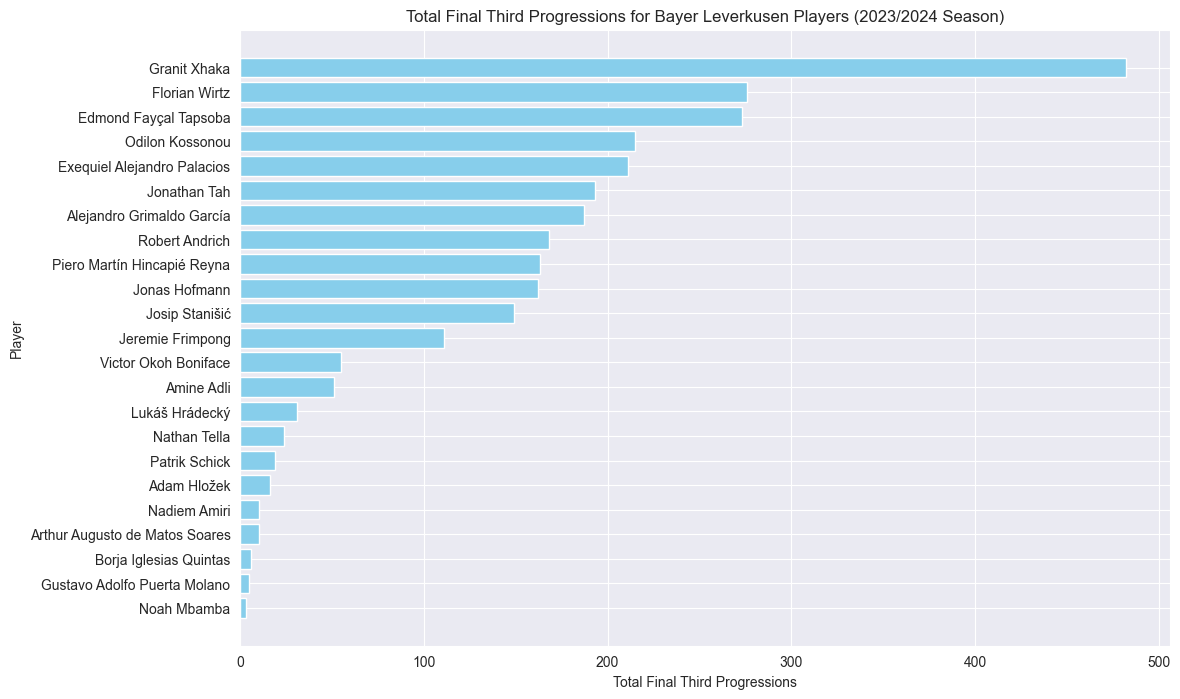

In [172]:
# Plotting the data
plt.figure(figsize=(12, 8))
plt.barh(sorted_final_third_progressions['player'], sorted_final_third_progressions['total_progressions'], color='skyblue')
plt.xlabel('Total Final Third Progressions')
plt.ylabel('Player')
plt.title('Total Final Third Progressions for Bayer Leverkusen Players (2023/2024 Season)')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest values on top
plt.show()

In [173]:
# Check unique values in the 'pass_outcome' column
unique_pass_outcomes = events_df['pass_outcome'].unique()
print("Unique values in 'pass_outcome':")
print(unique_pass_outcomes)

Unique values in 'pass_outcome':
[nan 'Incomplete' 'Pass Offside' 'Out' 'Unknown' 'Injury Clearance']


In [174]:
# Count key passes and assists for Granit Xhaka
key_passes = events_df[(events_df['player'] == 'Granit Xhaka') & (events_df['type'] == 'Pass') & (events_df['pass_shot_assist'] == True)]
assists = events_df[(events_df['player'] == 'Granit Xhaka') & (events_df['type'] == 'Pass') & (events_df['pass_goal_assist'] == True)]

print(f"Key Passes for Granit Xhaka: {key_passes.shape[0]}")
print(f"Assists for Granit Xhaka: {assists.shape[0]}")

Key Passes for Granit Xhaka: 41
Assists for Granit Xhaka: 0


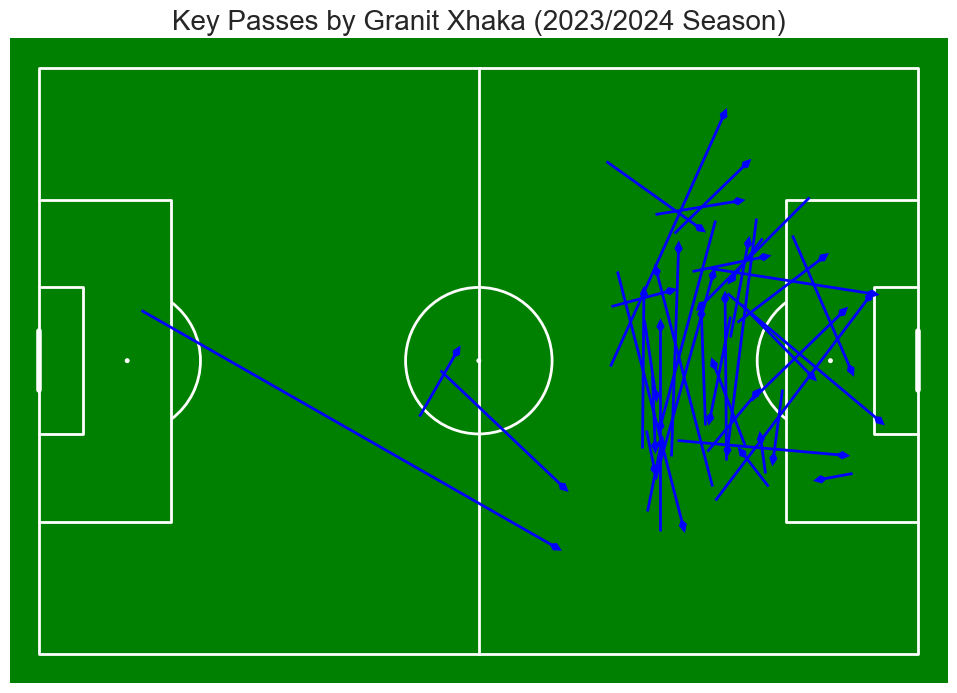

In [175]:

# Set up the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

# Plot key passes
for i, row in key_passes.iterrows():
    pitch.arrows(row['location'][0], row['location'][1], row['pass_end_location'][0], row['pass_end_location'][1],
                 ax=ax, color='blue', width=2, headwidth=3, headlength=3)

# Add title
ax.set_title('Key Passes by Granit Xhaka (2023/2024 Season)', fontsize=20)

# Show the plot
plt.show()

In [176]:
# Count key passes and assists for Granit Xhaka
key_passes_wirtz = events_df[(events_df['player'] == 'Florian Wirtz') & (events_df['type'] == 'Pass') & (events_df['pass_shot_assist'] == True)]
assists_wirtz = events_df[(events_df['player'] == 'Florian Wirtz') & (events_df['type'] == 'Pass') & (events_df['pass_goal_assist'] == True)]

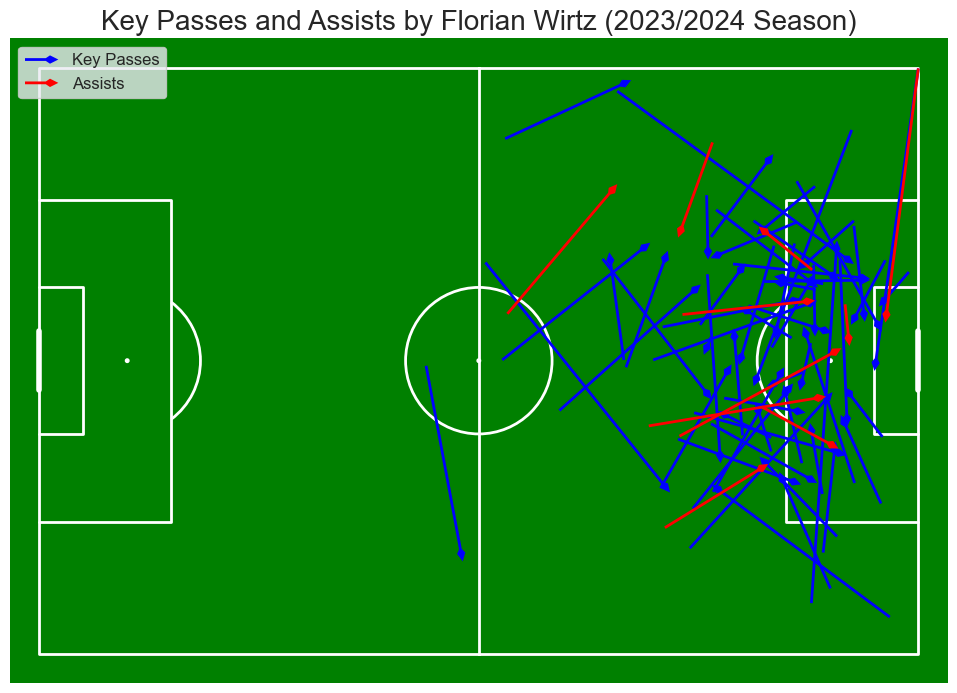

Key Passes for Florian Wirtz: 61
Assists for Florian Wirtz: 10


In [177]:
# Set up the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='green', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

# Plot key passes
key_passes = pitch.arrows(key_passes_wirtz['location'].apply(lambda x: x[0]), 
                          key_passes_wirtz['location'].apply(lambda x: x[1]),
                          key_passes_wirtz['pass_end_location'].apply(lambda x: x[0]), 
                          key_passes_wirtz['pass_end_location'].apply(lambda x: x[1]),
                          ax=ax, color='blue', width=2, headwidth=3, headlength=3, label='Key Passes')

# Plot assists
assists = pitch.arrows(assists_wirtz['location'].apply(lambda x: x[0]), 
                       assists_wirtz['location'].apply(lambda x: x[1]),
                       assists_wirtz['pass_end_location'].apply(lambda x: x[0]), 
                       assists_wirtz['pass_end_location'].apply(lambda x: x[1]),
                       ax=ax, color='red', width=2, headwidth=3, headlength=3, label='Assists')

# Add title
ax.set_title('Key Passes and Assists by Florian Wirtz (2023/2024 Season)', fontsize=20)

# Add legend
ax.legend(loc='upper left', fontsize=12)

# Show the plot
plt.show()

# Print the counts
print(f"Key Passes for Florian Wirtz: {key_passes_wirtz.shape[0]}")
print(f"Assists for Florian Wirtz: {assists_wirtz.shape[0]}")

In [178]:
# Define key passes (including both shot assists and goal assists)
key_passes = events_df[
    (events_df['type'] == 'Pass') & 
    ((events_df['pass_shot_assist'] == True) | (events_df['pass_goal_assist'] == True))
]

# Filter key passes for Bayer Leverkusen players
bayer_leverkusen_key_passes = key_passes[key_passes['team'] == 'Bayer Leverkusen']

# Count the number of key passes by each Bayer Leverkusen player
bayer_leverkusen_key_passes_count = bayer_leverkusen_key_passes.groupby('player').size().reset_index(name='count')

# Sort the results in descending order
sorted_bayer_leverkusen_key_passes_count = bayer_leverkusen_key_passes_count.sort_values(by='count', ascending=False)

# Display the sorted results
print("Key Passes (Shot Assists + Goal Assists) by Bayer Leverkusen Players:")
print(sorted_bayer_leverkusen_key_passes_count)

# Optionally, you can separate shot assists and goal assists
shot_assists = events_df[(events_df['type'] == 'Pass') & (events_df['pass_shot_assist'] == True) & (events_df['team'] == 'Bayer Leverkusen')]
goal_assists = events_df[(events_df['type'] == 'Pass') & (events_df['pass_goal_assist'] == True) & (events_df['team'] == 'Bayer Leverkusen')]

shot_assists_count = shot_assists.groupby('player').size().reset_index(name='shot_assists')
goal_assists_count = goal_assists.groupby('player').size().reset_index(name='goal_assists')

# Merge the results
detailed_assists = pd.merge(shot_assists_count, goal_assists_count, on='player', how='outer').fillna(0)
detailed_assists['total_key_passes'] = detailed_assists['shot_assists'] + detailed_assists['goal_assists']
detailed_assists = detailed_assists.sort_values('total_key_passes', ascending=False)

print("\nDetailed Breakdown of Key Passes:")
print(detailed_assists)

Key Passes (Shot Assists + Goal Assists) by Bayer Leverkusen Players:
                            player  count
11                   Jonas Hofmann     76
1        Alejandro Grimaldo García     76
7                    Florian Wirtz     71
10                Jeremie Frimpong     43
8                     Granit Xhaka     41
6      Exequiel Alejandro Palacios     27
2                       Amine Adli     22
20                  Robert Andrich     21
21            Victor Okoh Boniface     21
15                    Nathan Tella     15
13                  Josip Stanišić     13
17                 Odilon Kossonou     11
0                      Adam Hložek      8
5            Edmond Fayçal Tapsoba      7
18                   Patrik Schick      7
4           Borja Iglesias Quintas      5
12                    Jonathan Tah      5
19     Piero Martín Hincapié Reyna      5
3   Arthur Augusto de Matos Soares      5
9     Gustavo Adolfo Puerta Molano      1
14                    Nadiem Amiri      1
16    

In [179]:
# Filter key passes for Bayer Leverkusen players
bayer_leverkusen_key_passes = key_passes[key_passes['team'] == 'Bayer Leverkusen']

# Count the number of key passes by each Bayer Leverkusen player
bayer_leverkusen_key_passes_count = bayer_leverkusen_key_passes.groupby('player').size().reset_index(name='count')

# Sort the results in descending order
sorted_bayer_leverkusen_key_passes_count = bayer_leverkusen_key_passes_count.sort_values(by='count', ascending=False)

# Display the sorted results
print(sorted_bayer_leverkusen_key_passes_count)

                            player  count
11                   Jonas Hofmann     76
1        Alejandro Grimaldo García     76
7                    Florian Wirtz     71
10                Jeremie Frimpong     43
8                     Granit Xhaka     41
6      Exequiel Alejandro Palacios     27
2                       Amine Adli     22
20                  Robert Andrich     21
21            Victor Okoh Boniface     21
15                    Nathan Tella     15
13                  Josip Stanišić     13
17                 Odilon Kossonou     11
0                      Adam Hložek      8
5            Edmond Fayçal Tapsoba      7
18                   Patrik Schick      7
4           Borja Iglesias Quintas      5
12                    Jonathan Tah      5
19     Piero Martín Hincapié Reyna      5
3   Arthur Augusto de Matos Soares      5
9     Gustavo Adolfo Puerta Molano      1
14                    Nadiem Amiri      1
16                     Noah Mbamba      1


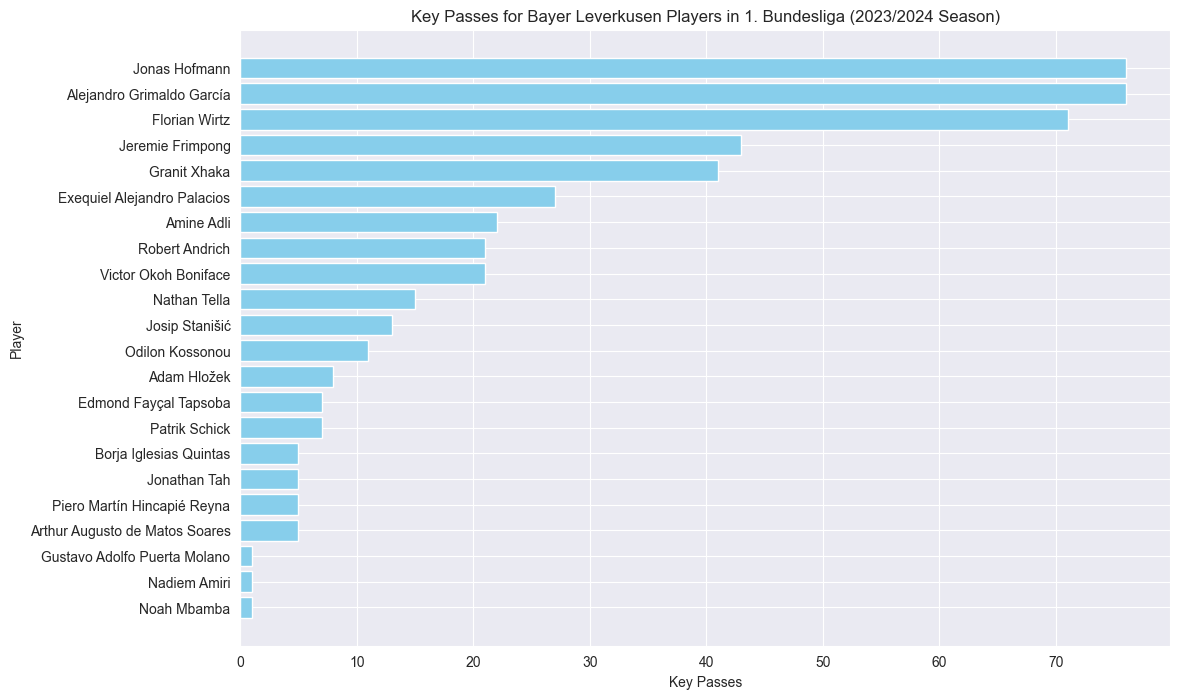

In [180]:
# Plotting the data
plt.figure(figsize=(12, 8))
plt.barh(sorted_bayer_leverkusen_key_passes_count['player'], sorted_bayer_leverkusen_key_passes_count['count'], color='skyblue')
plt.xlabel('Key Passes')
plt.ylabel('Player')
plt.title('Key Passes for Bayer Leverkusen Players in 1. Bundesliga (2023/2024 Season)')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest values on top
plt.show()

In [181]:

# Filter passes for Bayer Leverkusen players
bayer_leverkusen_passes = events_df[(events_df['team'] == 'Bayer Leverkusen') & (events_df['type'] == 'Pass')]

# Initialize a list to store the results
pass_accuracy_list = []

# Calculate pass accuracy for each player
for player in bayer_leverkusen_passes['player'].unique():
    player_passes = bayer_leverkusen_passes[bayer_leverkusen_passes['player'] == player]
    total_passes = player_passes.shape[0]
    successful_passes = player_passes[player_passes['pass_outcome'].isna()].shape[0]
    unsuccessful_passes = player_passes[~player_passes['pass_outcome'].isna()].shape[0]
    
    if total_passes > 0:
        pass_accuracy = successful_passes / total_passes * 100
        unsuccessful_pass_percentage = unsuccessful_passes / total_passes * 100
        pass_accuracy_list.append({
            'player': player,
            'total_passes': total_passes,
            'successful_passes': successful_passes,
            'unsuccessful_passes': unsuccessful_passes,
            'pass_accuracy': pass_accuracy,
            'unsuccessful_pass_percentage': unsuccessful_pass_percentage
        })

# Convert the list to a DataFrame
pass_accuracy_df = pd.DataFrame(pass_accuracy_list)

# Sort the DataFrame by pass accuracy in descending order
sorted_pass_accuracy_df = pass_accuracy_df.sort_values(by='pass_accuracy', ascending=False)

# Display the sorted results
print(sorted_pass_accuracy_df[['player', 'total_passes', 'successful_passes', 'unsuccessful_passes', 'pass_accuracy', 'unsuccessful_pass_percentage']])

                            player  total_passes  successful_passes  \
23                     Matěj Kovář            17                 17   
21                     Noah Mbamba            19                 19   
19    Gustavo Adolfo Puerta Molano            43                 41   
4                     Jonathan Tah          2167               2057   
22                    Nadiem Amiri            98                 91   
9      Piero Martín Hincapié Reyna          1423               1314   
15     Exequiel Alejandro Palacios          2022               1867   
6                     Granit Xhaka          3299               3045   
2            Edmond Fayçal Tapsoba          1946               1783   
5                  Odilon Kossonou          1422               1288   
3                   Robert Andrich          1501               1359   
20                  Josip Stanišić          1072                963   
18  Arthur Augusto de Matos Soares           108                 94   
17    

In [182]:
import pandas as pd
import numpy as np
from scipy import stats

# Assuming we have the events_df from the previous data fetch

# Filter passes for Bayer Leverkusen players only
bayer_passes = events_df[(events_df['team'] == 'Bayer Leverkusen') & (events_df['type'] == 'Pass')]

# Calculate pass accuracy for each Bayer Leverkusen player
pass_accuracy_list = []

for player in bayer_passes['player'].unique():
    player_passes = bayer_passes[bayer_passes['player'] == player]
    total_passes = player_passes.shape[0]
    successful_passes = player_passes[player_passes['pass_outcome'].isna()].shape[0]
    
    if total_passes > 0:
        pass_accuracy = (successful_passes / total_passes) * 100
        pass_accuracy_list.append({
            'player': player,
            'total_passes': total_passes,
            'successful_passes': successful_passes,
            'pass_accuracy': pass_accuracy
        })

pass_accuracy_df = pd.DataFrame(pass_accuracy_list)

# 1. Set a minimum pass threshold (e.g., 100 passes)
min_passes = 100
filtered_df = pass_accuracy_df[pass_accuracy_df['total_passes'] >= min_passes]

# 2. Calculate confidence intervals
def confidence_interval(success, total, confidence=0.95):
    if total == 0:
        return 0, 0
    z = stats.norm.ppf((1 + confidence) / 2)
    p = float(success) / total
    se = np.sqrt(p * (1 - p) / total)
    return p - z * se, p + z * se

filtered_df['ci_lower'], filtered_df['ci_upper'] = zip(*filtered_df.apply(lambda row: confidence_interval(row['successful_passes'], row['total_passes']), axis=1))

# 3. Calculate weighted average
total_passes = filtered_df['total_passes'].sum()
weighted_accuracy = (filtered_df['pass_accuracy'] * filtered_df['total_passes']).sum() / total_passes

# Sort by pass accuracy and reset index
filtered_df = filtered_df.sort_values('pass_accuracy', ascending=False).reset_index(drop=True)

# Display results
print("Pass Accuracy Comparison for Bayer Leverkusen Players (minimum {} passes):".format(min_passes))
print(filtered_df[['player', 'total_passes', 'pass_accuracy', 'ci_lower', 'ci_upper']])
print("\nWeighted Average Pass Accuracy for Bayer Leverkusen: {:.2f}%".format(weighted_accuracy))

Pass Accuracy Comparison for Bayer Leverkusen Players (minimum 100 passes):
                            player  total_passes  pass_accuracy  ci_lower  \
0                     Jonathan Tah          2167      94.923858  0.939996   
1      Piero Martín Hincapié Reyna          1423      92.340126  0.909583   
2      Exequiel Alejandro Palacios          2022      92.334322  0.911747   
3                     Granit Xhaka          3299      92.300697  0.913910   
4            Edmond Fayçal Tapsoba          1946      91.623844  0.903930   
5                  Odilon Kossonou          1422      90.576653  0.890582   
6                   Robert Andrich          1501      90.539640  0.890591   
7                   Josip Stanišić          1072      89.832090  0.880229   
8   Arthur Augusto de Matos Soares           108      87.037037  0.807021   
9                      Adam Hložek           155      84.516129  0.788212   
10                   Florian Wirtz          1841      83.813145  0.821306   


/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_88916/758058569.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['ci_lower'], filtered_df['ci_upper'] = zip(*filtered_df.apply(lambda row: confidence_interval(row['successful_passes'], row['total_passes']), axis=1))
/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_88916/758058569.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['ci_lower'], filtered_df['ci_upper'] = zip(*filtered_df.apply(lambda row: confide

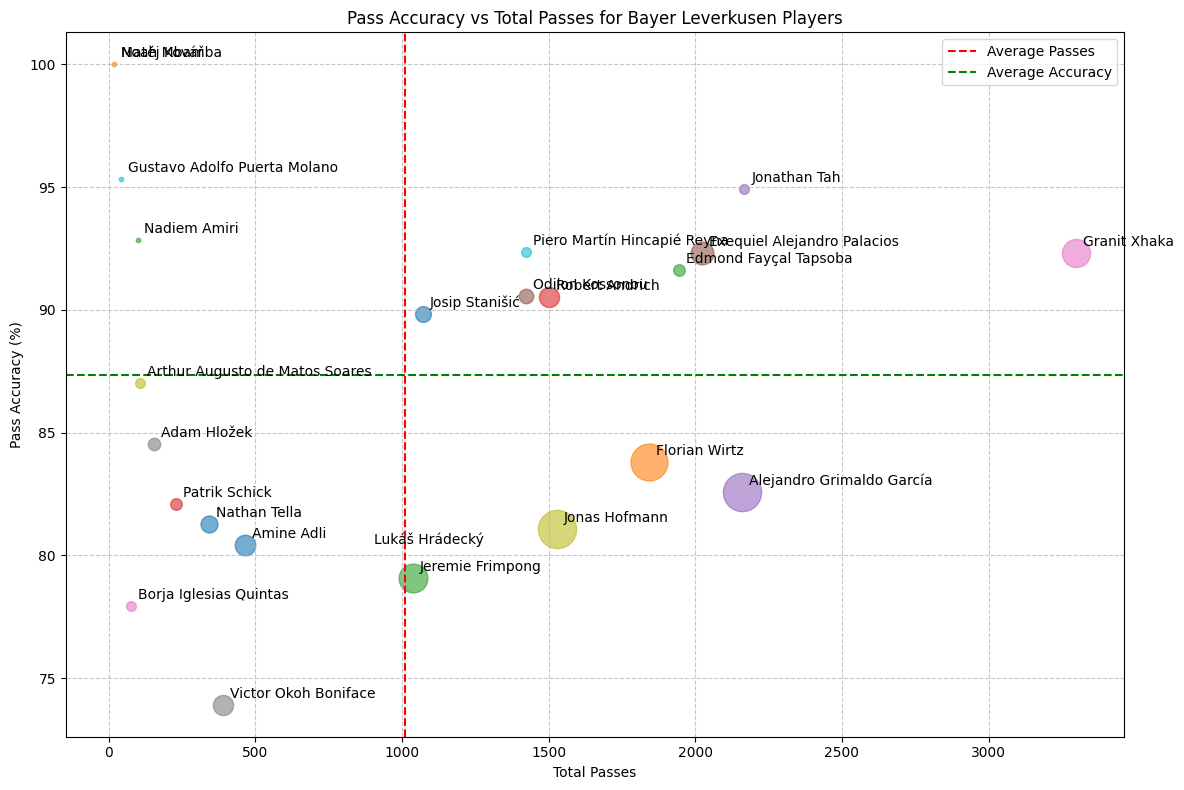

In [44]:
# Merge the key passes count with our pass accuracy data
pass_accuracy_df = pd.merge(pass_accuracy_df, sorted_bayer_leverkusen_key_passes_count, on='player', how='left')

# Fill any NaN values in the 'count' column with 0
pass_accuracy_df['count'] = pass_accuracy_df['count'].fillna(0)

# Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each player
for _, player in pass_accuracy_df.iterrows():
    ax.scatter(player['total_passes'], player['pass_accuracy'], 
               s=player['count']*10,  # Adjust size based on key passes count
               alpha=0.6)
    ax.annotate(player['player'], 
                (player['total_passes'], player['pass_accuracy']),
                xytext=(5, 5), textcoords='offset points')

# Set labels and title
ax.set_xlabel('Total Passes')
ax.set_ylabel('Pass Accuracy (%)')
ax.set_title('Pass Accuracy vs Total Passes for Bayer Leverkusen Players')

# Add a grid for better readability
ax.grid(True, linestyle='--', alpha=0.7)

# Add a vertical line for average number of passes
avg_passes = pass_accuracy_df['total_passes'].mean()
ax.axvline(x=avg_passes, color='r', linestyle='--', label='Average Passes')

# Add a horizontal line for average pass accuracy
avg_accuracy = pass_accuracy_df['pass_accuracy'].mean()
ax.axhline(y=avg_accuracy, color='g', linestyle='--', label='Average Accuracy')

# Add legend
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [183]:
unique_event_types = events_df['type'].unique()
print("Unique event types:")
for event_type in sorted(unique_event_types):
    print(event_type)

Unique event types:
50/50
Bad Behaviour
Ball Receipt*
Ball Recovery
Block
Carry
Clearance
Dispossessed
Dribble
Dribbled Past
Duel
Error
Foul Committed
Foul Won
Goal Keeper
Half End
Half Start
Injury Stoppage
Interception
Miscontrol
Offside
Own Goal Against
Own Goal For
Pass
Player Off
Player On
Pressure
Referee Ball-Drop
Shield
Shot
Starting XI
Substitution
Tactical Shift


In [184]:
# Define defensive actions
defensive_actions = ['Pressure', 'Interception', 'Ball Recovery', 'Block', 'Clearance', 'Duel']

# Filter Xhaka's defensive actions
xhaka_defensive_actions = events_df[(events_df['player'] == 'Granit Xhaka') & (events_df['type'].isin(defensive_actions))]

# Count each type of defensive action
action_counts = xhaka_defensive_actions['type'].value_counts()

print("Granit Xhaka's Defensive Actions:")
print(action_counts)

# Calculate total defensive actions
total_defensive_actions = action_counts.sum()
print(f"\nTotal Defensive Actions: {total_defensive_actions}")

Granit Xhaka's Defensive Actions:
type
Pressure         309
Ball Recovery    191
Duel              69
Block             65
Clearance         46
Interception      18
Name: count, dtype: int64

Total Defensive Actions: 698


Defensive Actions by Bayer Leverkusen Players:
type                            Ball Recovery  Block  Clearance  Duel  \
player                                                                  
Adam Hložek                                20      7          3    17   
Alejandro Grimaldo García                 158     66         43    65   
Amine Adli                                 38     19          7    36   
Arthur Augusto de Matos Soares              8      5          7     7   
Borja Iglesias Quintas                      7      2          1    11   
Edmond Fayçal Tapsoba                     136     37         71    64   
Exequiel Alejandro Palacios               136     39         23    68   
Florian Wirtz                             161     58          4    69   
Granit Xhaka                              191     65         46    69   
Gustavo Adolfo Puerta Molano                2      2          1     5   
Jeremie Frimpong                          111     54         18    45   
Jona

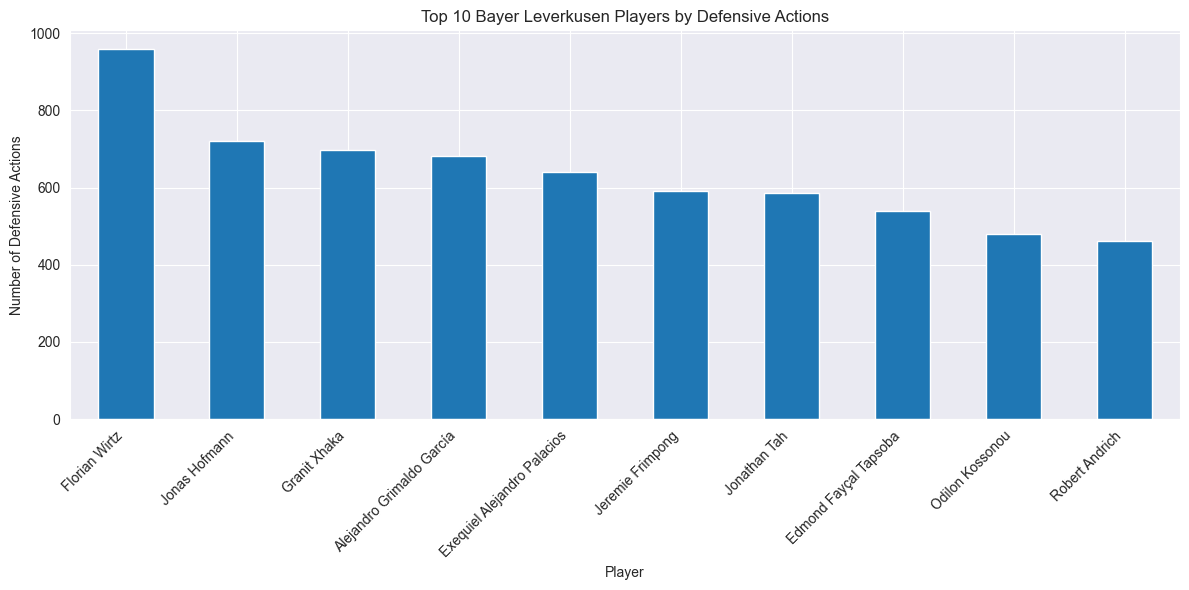

In [185]:
# Define defensive actions
defensive_actions = ['Pressure', 'Interception', 'Ball Recovery', 'Block', 'Clearance', 'Duel']

# Filter defensive actions for all Bayer Leverkusen players
leverkusen_defensive_actions = events_df[(events_df['team'] == 'Bayer Leverkusen') & (events_df['type'].isin(defensive_actions))]

# Group by player and count each type of defensive action
player_action_counts = leverkusen_defensive_actions.groupby('player')['type'].value_counts().unstack(fill_value=0)

# Calculate total defensive actions for each player
player_total_actions = player_action_counts.sum(axis=1).sort_values(ascending=False)

# Display the results
print("Defensive Actions by Bayer Leverkusen Players:")
print(player_action_counts)

print("\nTotal Defensive Actions by Player:")
print(player_total_actions)

# Calculate and display team totals
team_totals = player_action_counts.sum()
print("\nTeam Totals for Each Defensive Action:")
print(team_totals)
print(f"\nTotal Team Defensive Actions: {team_totals.sum()}")

# Highlight Granit Xhaka's stats
if 'Granit Xhaka' in player_total_actions:
    xhaka_total = player_total_actions['Granit Xhaka']
    xhaka_rank = player_total_actions.rank(ascending=False)['Granit Xhaka']
    print(f"\nGranit Xhaka's Total Defensive Actions: {xhaka_total}")
    print(f"Rank among Bayer Leverkusen players: {xhaka_rank:.0f}")

# Visualize top 10 players by total defensive actions
plt.figure(figsize=(12, 6))
player_total_actions.head(10).plot(kind='bar')
plt.title("Top 10 Bayer Leverkusen Players by Defensive Actions")
plt.xlabel("Player")
plt.ylabel("Number of Defensive Actions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [186]:
# Filter for Bayer Leverkusen's starting lineups
bayer_starting_lineups = events_df[(events_df['type'] == 'Starting XI') & (events_df['team'] == 'Bayer Leverkusen')]

# Extract formations
bayer_formations = bayer_starting_lineups['tactics'].apply(lambda x: x['formation'] if isinstance(x, dict) else None)

print("Starting formations used by Bayer Leverkusen:")
print(bayer_formations.value_counts())

# Calculate the total number of matches
total_matches = len(bayer_formations)

# Calculate the percentage for each formation
formation_percentages = (bayer_formations.value_counts() / total_matches * 100).round(2)

print("\nPercentage of matches for each formation:")
for formation, percentage in formation_percentages.items():
    print(f"{formation}: {percentage}%")

print(f"\nTotal matches analyzed: {total_matches}")

Starting formations used by Bayer Leverkusen:
tactics
3421    25
343      8
3412     1
Name: count, dtype: int64

Percentage of matches for each formation:
3421: 73.53%
343: 23.53%
3412: 2.94%

Total matches analyzed: 34


In [188]:
# Assuming events_df contains StatsBomb event data
# First, let's check if position information is available
if 'position' in events_df.columns:
    # Extract unique player-position pairs
    player_positions = events_df[['player', 'position']].drop_duplicates().set_index('player')['position'].to_dict()
else:
    print("Position information not available in the dataset. Using fallback method.")
    # Use our fallback method if position data is not available
    player_positions = {player: infer_position(loc[0]) for player, loc in player_positions.items() if player in G.nodes()}
    # Assign goalkeeper manually
    goalkeeper = min(pos, key=lambda k: pos[k][0])
    player_positions[goalkeeper] = 'Goalkeeper'


In [189]:
# Assuming events_df contains StatsBomb event data
# First, let's check if position information is available
if 'position' in events_df.columns:
    # Extract unique player-position pairs
    player_positions = events_df[['player', 'position']].drop_duplicates().set_index('player')['position'].to_dict()
else:
    print("Position information not available in the dataset. Using fallback method.")
    # Use our fallback method if position data is not available
    player_positions = {player: infer_position(loc[0]) for player, loc in player_positions.items() if player in G.nodes()}
    # Assign goalkeeper manually
    goalkeeper = min(pos, key=lambda k: pos[k][0])
    player_positions[goalkeeper] = 'Goalkeeper'

# Map StatsBomb positions to our simplified categories
position_mapping = {
    'Goalkeeper': 'Goalkeeper',
    'Right Back': 'Defender',
    'Left Back': 'Defender',
    'Center Back': 'Defender',
    'Right Wing Back': 'Defender',
    'Left Wing Back': 'Defender',
    'Defensive Midfield': 'Midfielder',
    'Central Midfield': 'Midfielder',
    'Right Midfield': 'Midfielder',
    'Left Midfield': 'Midfielder',
    'Attacking Midfield': 'Midfielder',
    'Right Wing': 'Forward',
    'Left Wing': 'Forward',
    'Center Forward': 'Forward',
    'Secondary Striker': 'Forward'
}

# Apply the mapping
player_positions = {player: position_mapping.get(pos, 'Midfielder') for player, pos in player_positions.items()}

In [190]:
position_related_columns = [col for col in events_df.columns if 'position' in col.lower()]
print("Columns potentially related to position:", position_related_columns)

Columns potentially related to position: ['goalkeeper_position', 'position']


In [191]:
if 'position' in events_df.columns:
    print("\nUnique values in the 'position' column:")
    unique_positions = events_df['position'].unique()
    for position in unique_positions:
        if isinstance(position, str):
            print(position)
        elif isinstance(position, dict):
            print(f"Dictionary: {position}")
        elif pd.isna(position):
            print("NaN (missing value)")
        else:
            print(f"Other type: {type(position)} - {position}")
else:
    print("\nNo 'position' column found in the dataset.")


Unique values in the 'position' column:
NaN (missing value)
Right Center Forward
Left Center Forward
Center Back
Right Center Back
Right Wing Back
Goalkeeper
Left Center Back
Left Defensive Midfield
Right Defensive Midfield
Center Forward
Left Wing Back
Right Center Midfield
Right Attacking Midfield
Left Center Midfield
Left Attacking Midfield
Center Defensive Midfield
Center Attacking Midfield
Right Back
Left Back
Right Wing
Left Wing
Right Midfield
Left Midfield


NameError: name 'node_colors' is not defined

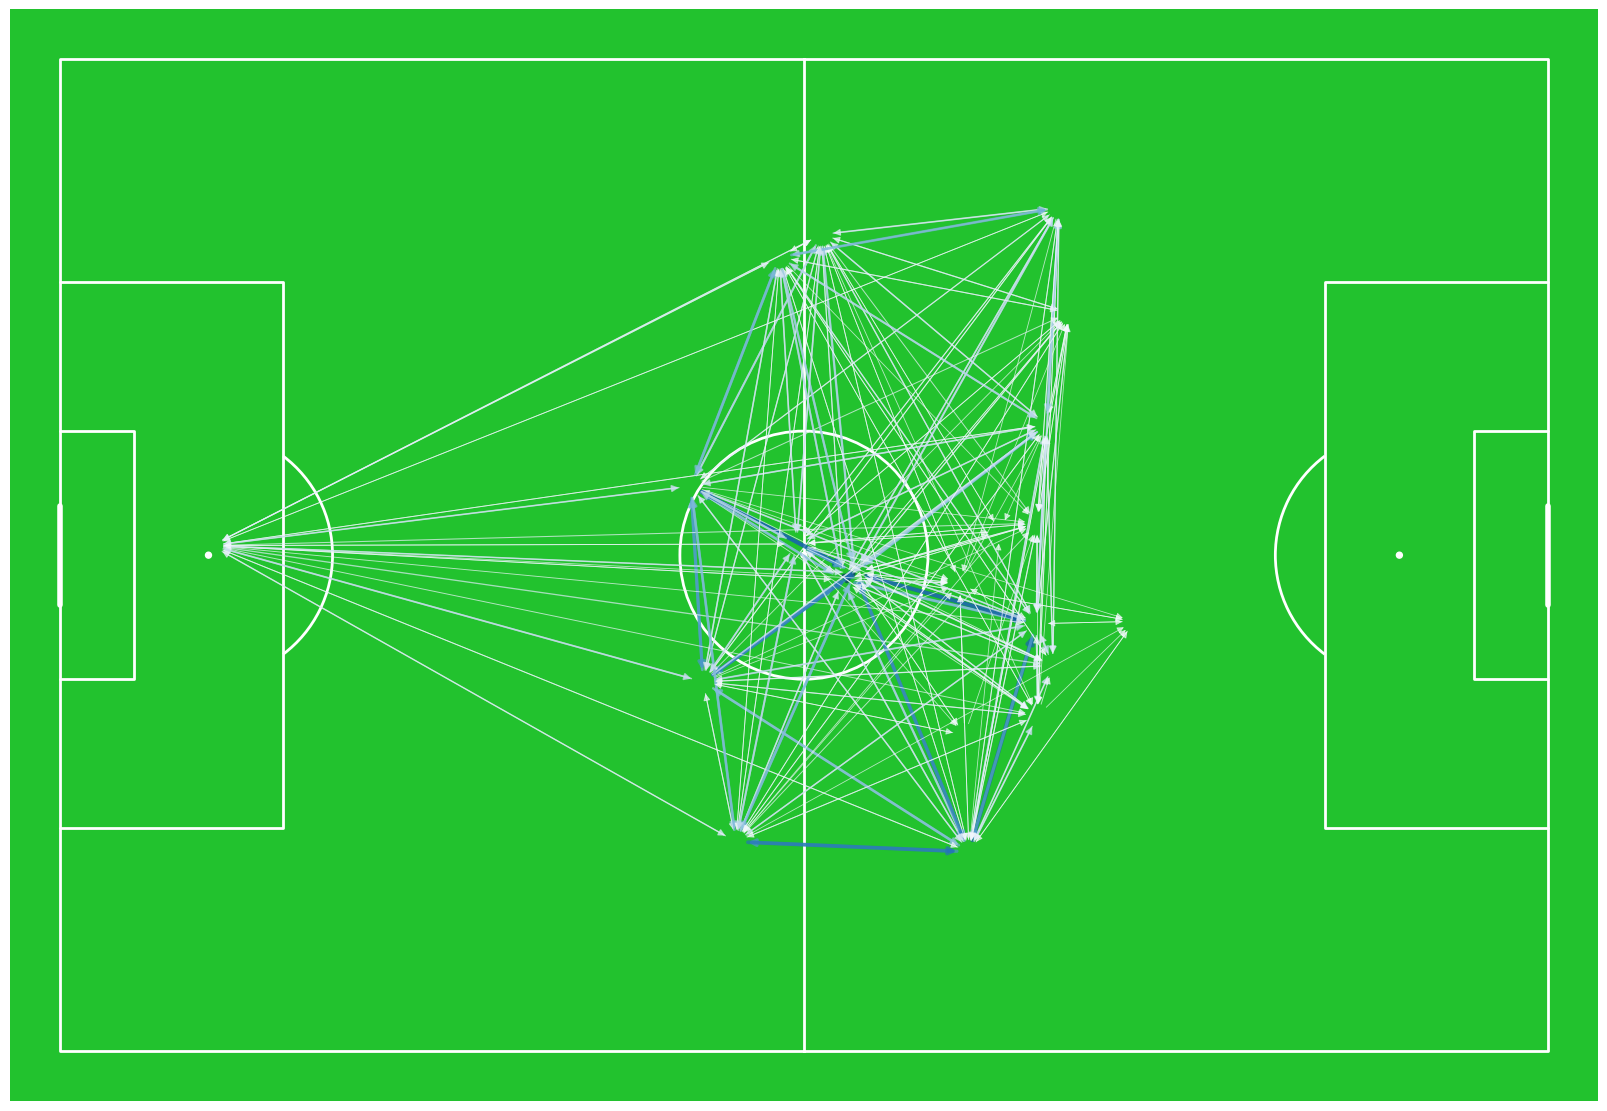

In [192]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch

# ... (previous data preparation code remains the same)

# Increase minimum passes threshold
min_passes = 10

# Get top passers
top_passers = sorted(node_sizes.items(), key=lambda x: x[1], reverse=True)[:7]
top_passer_names = [player for player, _ in top_passers]

# Create a mapping of player names to numbers for non-top passers
player_numbers = {player: str(i+1) for i, player in enumerate(G.nodes()) if player not in top_passer_names}

# Adjust node sizes to be more proportional
max_node_size = 1000
min_node_size = 100
node_sizes = {player: (count / max_passes) * (max_node_size - min_node_size) + min_node_size for player, count in node_sizes.items()}

# Create the plot
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22c22e', line_color='white', stripe=False)
fig, ax = plt.subplots(figsize=(16, 11), constrained_layout=True)
pitch.draw(ax=ax)

# Draw edges
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_weight = max(edge_weights)
edge_widths = [(w / max_weight) * 3 + 0.5 for w in edge_weights]

edges = nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color=edge_weights,
    edge_cmap=plt.cm.Blues,
    edge_vmin=min_passes,
    edge_vmax=max_weight,
    width=edge_widths,
    alpha=0.7, arrows=True, arrowsize=10
)

# Draw nodes
nodes = nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=[node_sizes[node] for node in G.nodes()],
    node_color=node_colors,
    alpha=0.8
)

# Draw labels
labels = {}
for node in G.nodes():
    if node in top_passer_names:
        labels[node] = node
    else:
        labels[node] = player_numbers[node]

nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8, font_weight='bold')

# Customize the plot
ax.set_title("Bayer Leverkusen Passing Network", fontsize=20, pad=20)
ax.set_xlim(-5, 125)
ax.set_ylim(-5, 85)

# Add vertical lines to divide the pitch into thirds
ax.axvline(x=40, color='white', linestyle='--', alpha=0.5)
ax.axvline(x=80, color='white', linestyle='--', alpha=0.5)

# Add a colorbar for edge weights
sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=plt.Normalize(vmin=min_passes, vmax=max_weight))
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
cbar.set_label('Number of passes', fontsize=12)

# Add a legend for node colors
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=pos,
                              markerfacecolor=color, markersize=10)
                   for pos, color in position_colors.items()]
ax.legend(handles=legend_elements, loc='upper left', title='Player Positions')

plt.show()

# Print top passers and pass combinations
print("\nTop 7 passers:")
for player, size in top_passers:
    print(f"{player} ({player_numbers.get(player, '')}): {G.out_degree(player, weight='weight')} passes")

top_combinations = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
print("\nTop 5 pass combinations:")
for passer, receiver, data in top_combinations:
    print(f"{passer} ({player_numbers.get(passer, '')}) to {receiver} ({player_numbers.get(receiver, '')}): {data['weight']} passes")

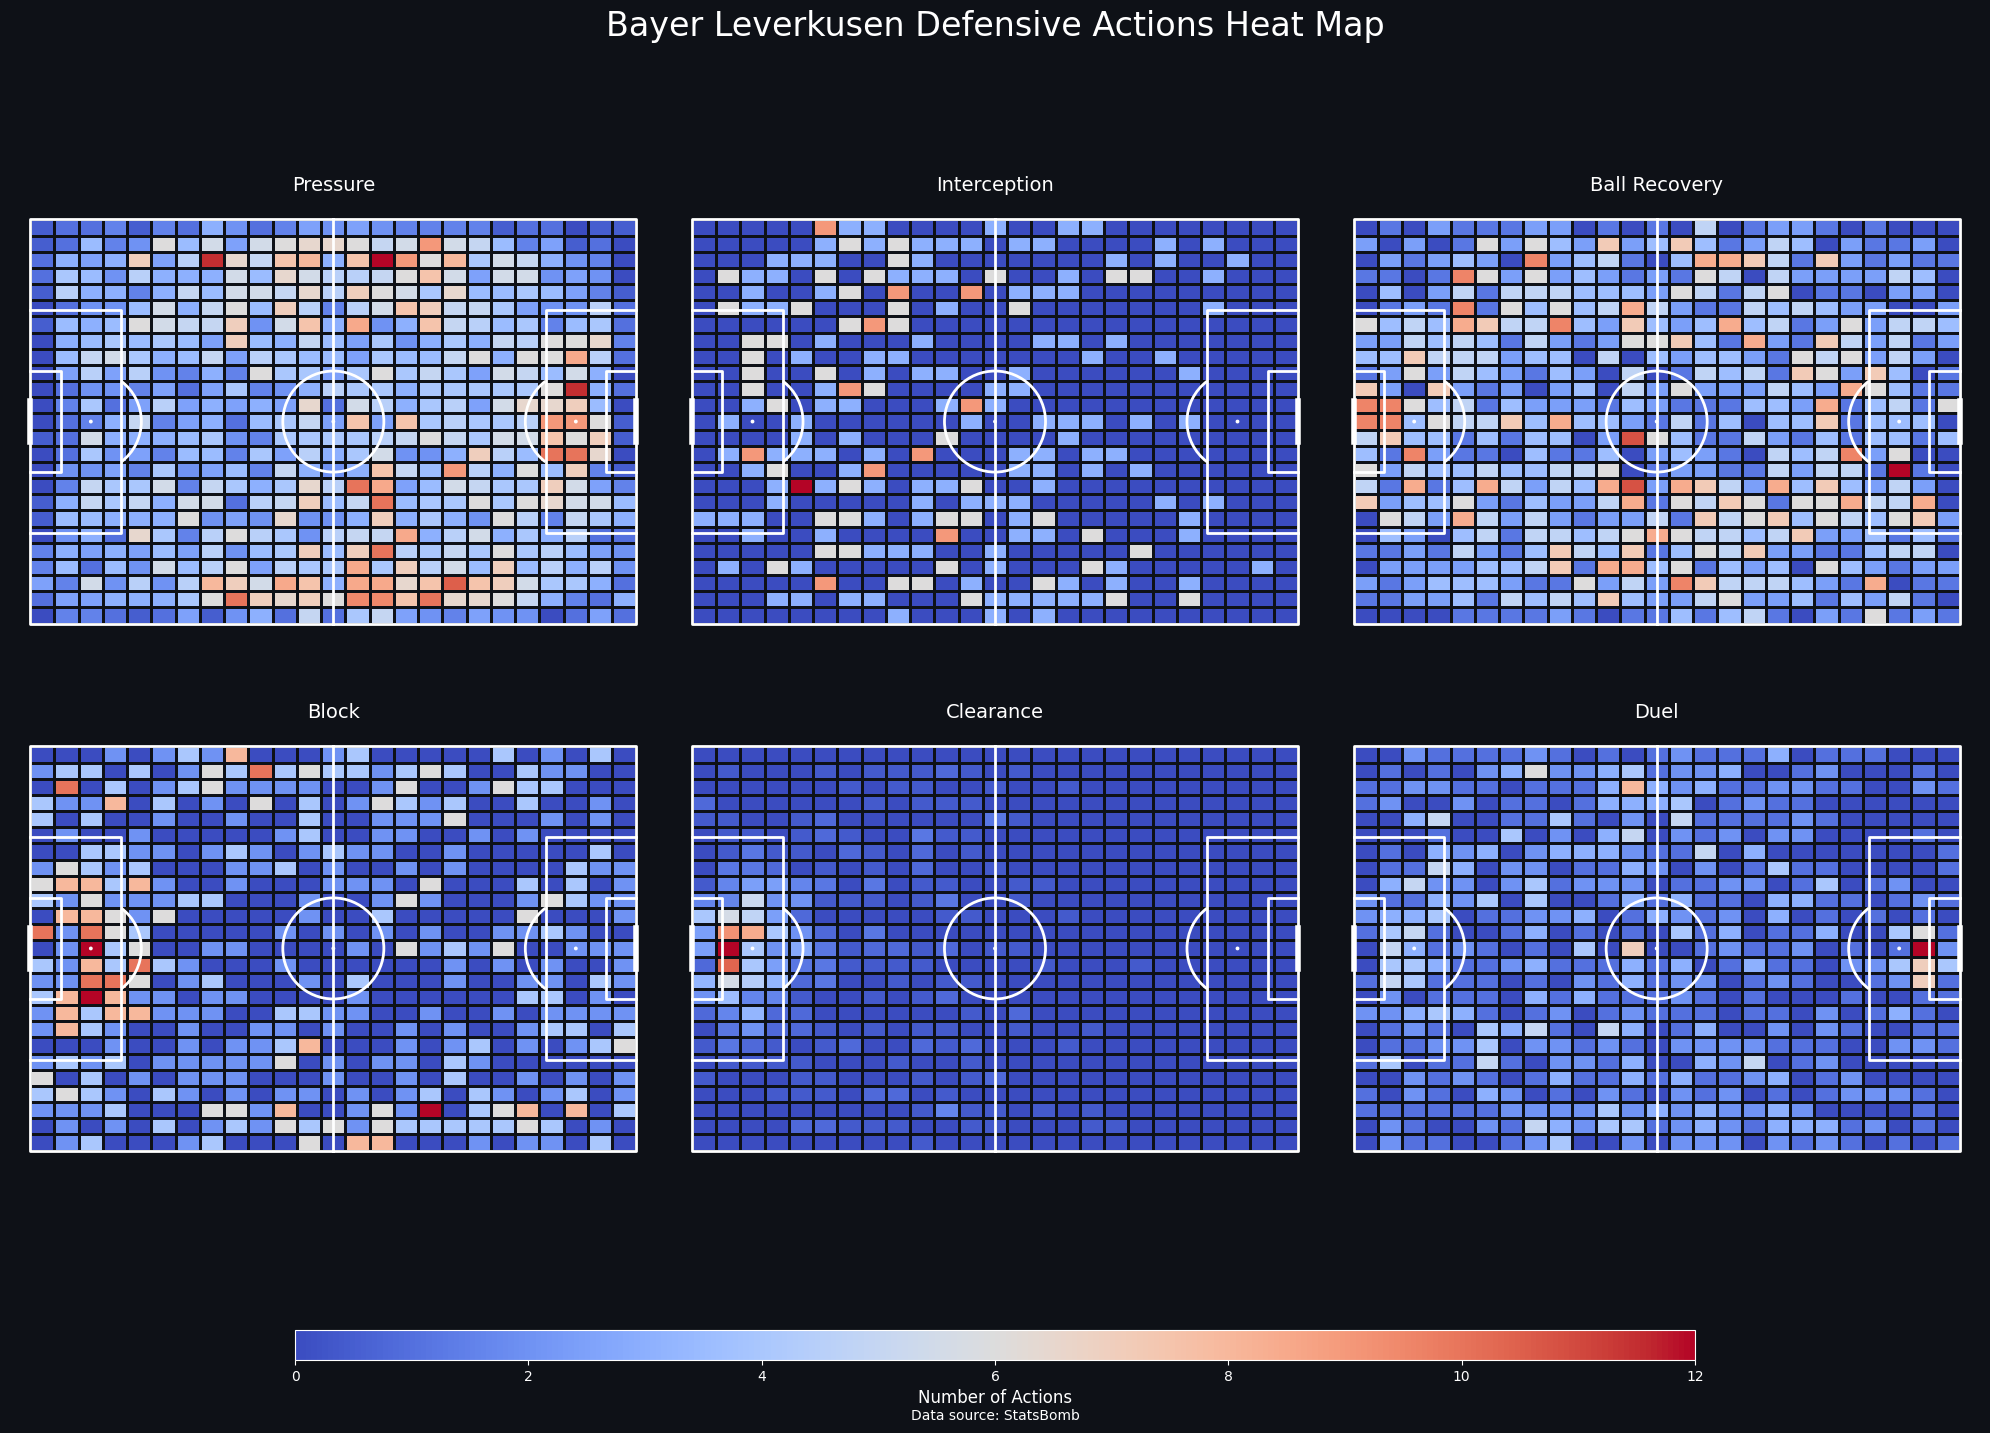

Defensive Action Counts:
type
Pressure         4786
Ball Recovery    1751
Duel              864
Block             616
Clearance         552
Interception      265
Name: count, dtype: int64


/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_88916/1360574760.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=action_counts.index, y=action_counts.values, palette='coolwarm')


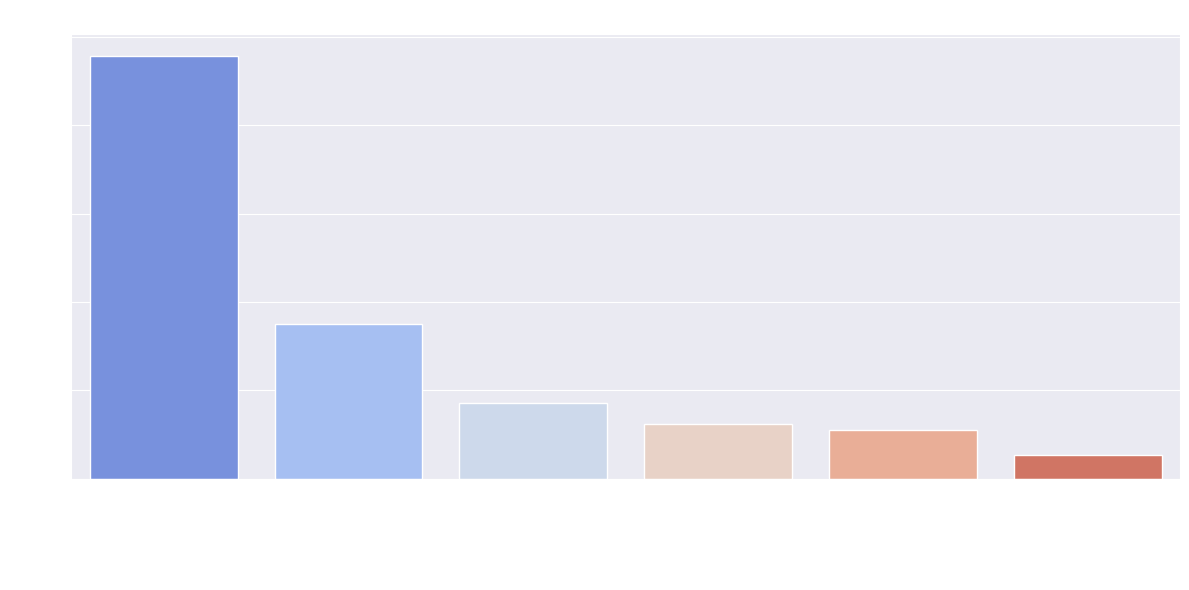

In [193]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import seaborn as sns

# Set up the plot with improved styling
plt.style.use('default')
fig, axs = plt.subplots(2, 3, figsize=(20, 15))
fig.suptitle("Bayer Leverkusen Defensive Actions Heat Map", fontsize=24, y=0.95, color='white')
fig.patch.set_facecolor('#0E1117')

# Flatten axs for easier iteration
axs = axs.flatten()

# Create heat maps for each defensive action
for idx, action in enumerate(defensive_actions):
    actions = leverkusen_defensive_actions[leverkusen_defensive_actions['type'] == action]
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#0E1117', line_color='white', line_zorder=2)
    
    # Draw the pitch on the existing axis
    pitch.draw(ax=axs[idx])
    
    # Create and plot the heat map
    bin_statistic = pitch.bin_statistic(actions['x'], actions['y'], statistic='count', bins=(25, 25))
    hm = pitch.heatmap(bin_statistic, ax=axs[idx], cmap='coolwarm', edgecolors='#0E1117', zorder=1)
    
    # Add labels
    axs[idx].set_title(f"{action}", fontsize=14, color='white')
    axs[idx].set_facecolor('#0E1117')

# Remove the existing color bar
for cbar in fig.get_axes():
    if cbar.get_label() == '<colorbar>':
        cbar.remove()

# Add a single color bar at the bottom
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(hm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Number of Actions', fontsize=12, color='white')
cbar.ax.xaxis.set_tick_params(color='white')
cbar.outline.set_edgecolor('white')
plt.setp(plt.getp(cbar.ax.axes, 'xticklabels'), color='white')

# Adjust layout
plt.tight_layout()
fig.subplots_adjust(bottom=0.1, top=0.9)

# Add a footnote
plt.figtext(0.5, 0.01, "Data source: StatsBomb", ha="center", fontsize=10, color='white')

plt.show()

# Print summary statistics
action_counts = leverkusen_defensive_actions['type'].value_counts()
print("Defensive Action Counts:")
print(action_counts)

# Create a styled bar plot of action counts
plt.figure(figsize=(12, 6))
sns.set_style("darkgrid")
sns.barplot(x=action_counts.index, y=action_counts.values, palette='coolwarm')
plt.title("Bayer Leverkusen Defensive Actions Distribution", fontsize=16, color='white')
plt.xlabel("Action Type", fontsize=12, color='white')
plt.ylabel("Count", fontsize=12, color='white')
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.show()

/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_88916/4010058385.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  match_stats = events_df.groupby('match_id').apply(get_match_stats).reset_index(drop=True)


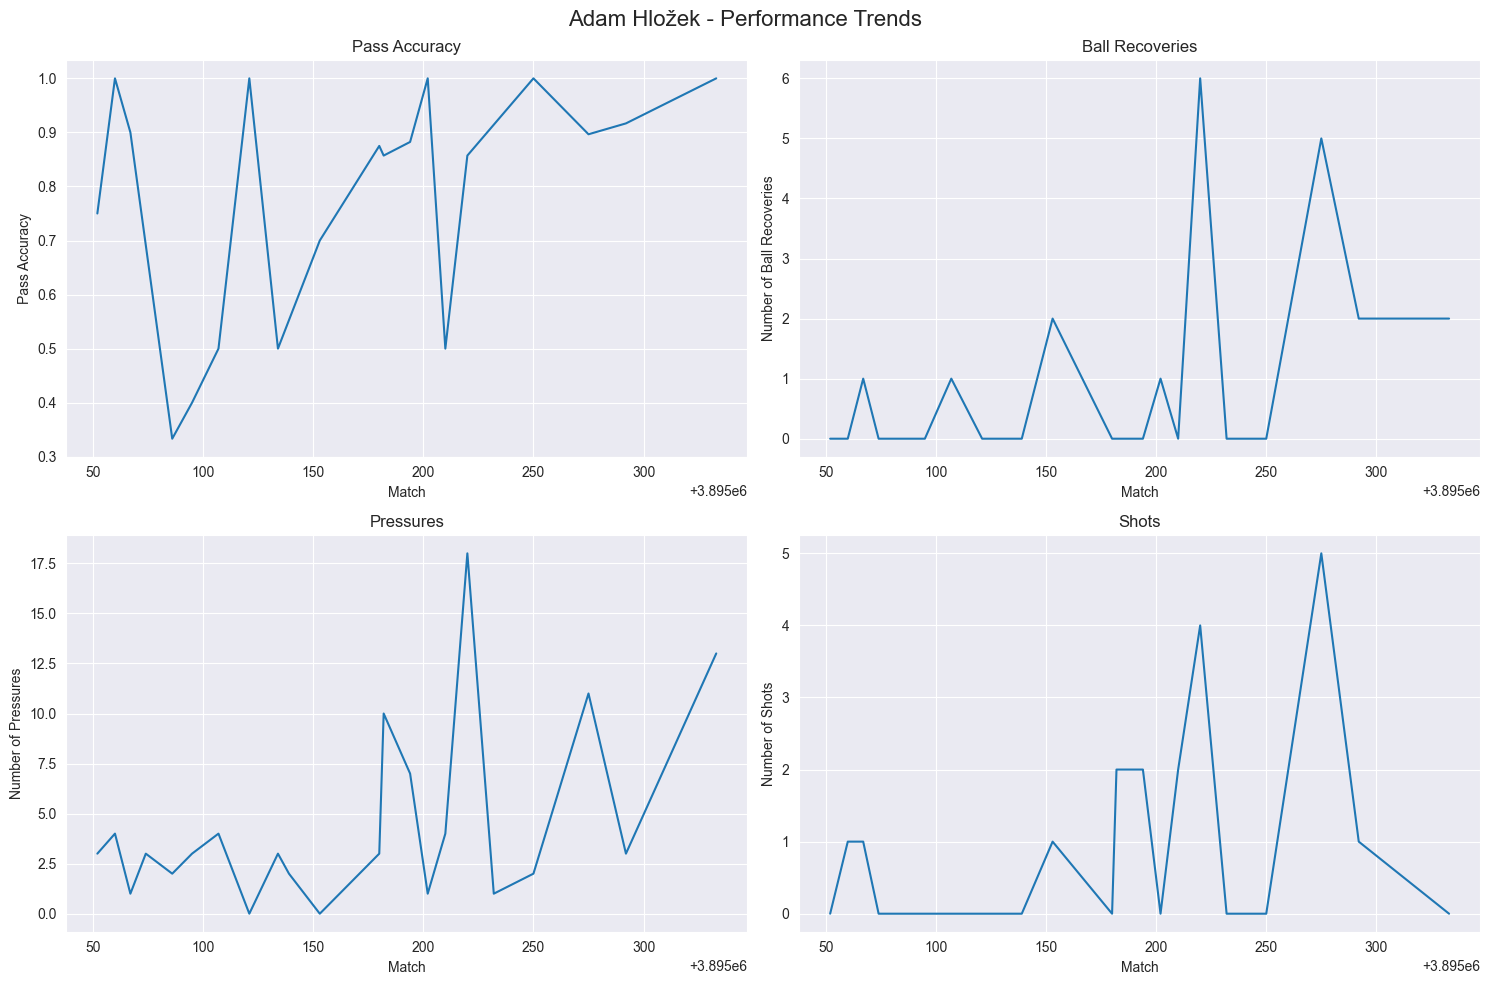


Summary Statistics for Adam Hložek:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     22.000000          22.000000        22.000000  22.000000  22.000000   
mean       7.045455           5.954545         0.909091   4.454545   0.863636   
std        7.858737           7.227443         1.659291   4.595311   1.390288   
min        0.000000           0.000000         0.000000   0.000000   0.000000   
25%        2.000000           1.000000         0.000000   2.000000   0.000000   
50%        3.500000           2.000000         0.000000   3.000000   0.000000   
75%       10.000000           8.500000         1.000000   4.000000   1.000000   
max       29.000000          26.000000         6.000000  18.000000   5.000000   

       pass_accuracy      match_id  
count      19.000000  2.200000e+01  
mean        0.782536  3.895166e+06  
std         0.224395  8.041747e+01  
min         0.333333  3.895052e+06  
25%         0.600000  3.895098e+06  
50%        

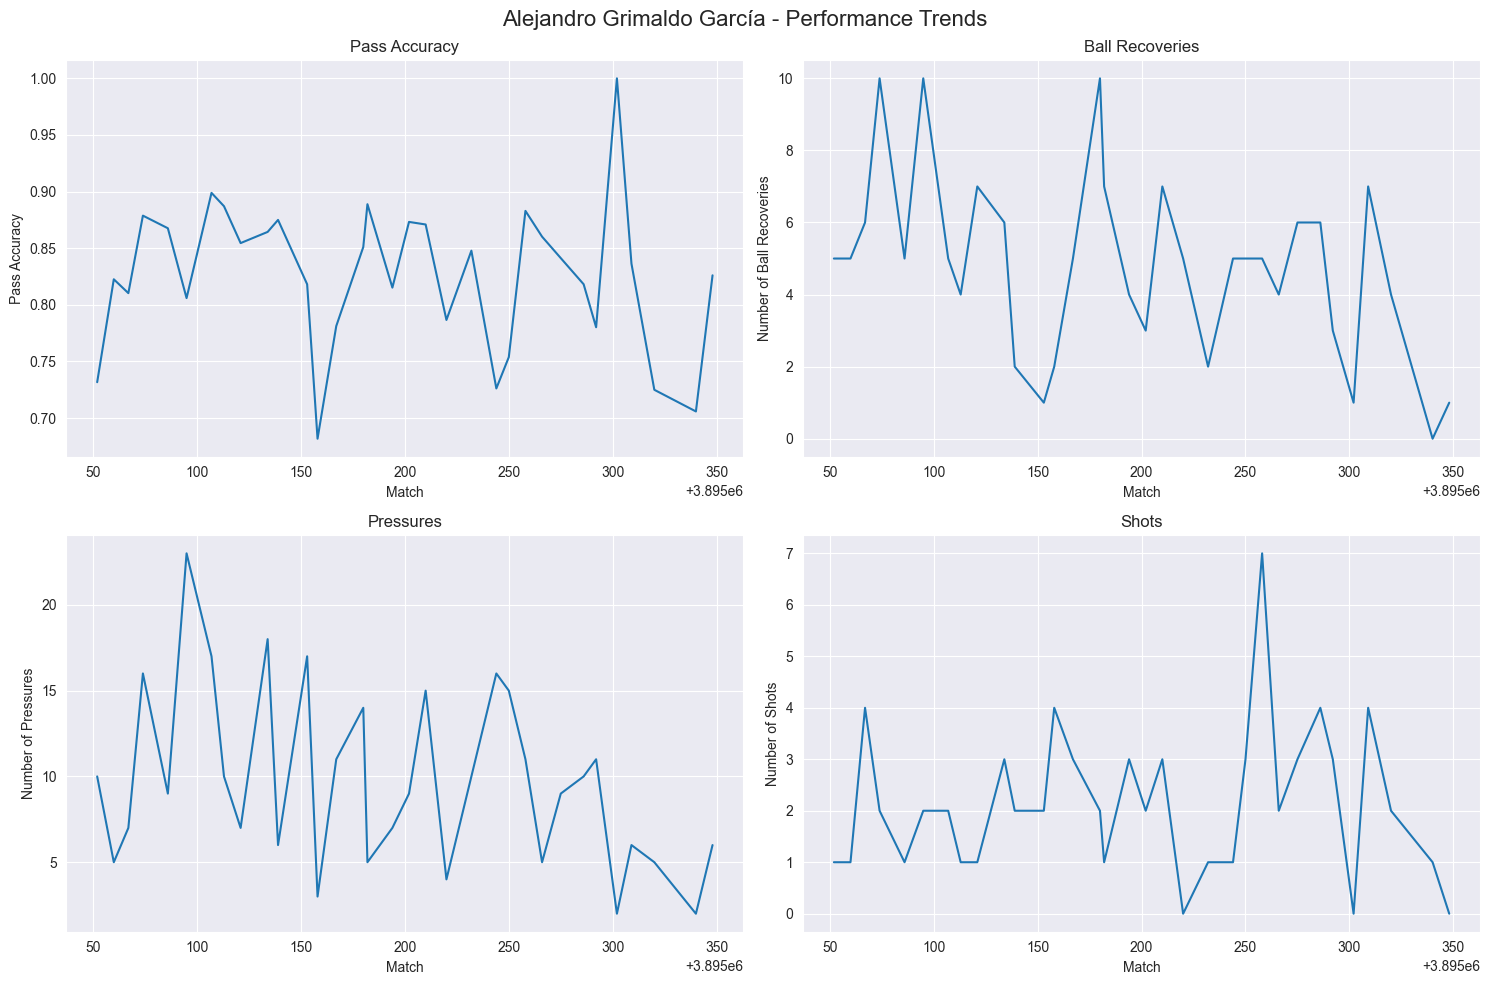


Summary Statistics for Alejandro Grimaldo García:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     33.000000          33.000000        33.000000  33.000000  33.000000   
mean      65.424242          54.030303         4.787879   9.727273   2.151515   
std       20.868682          17.829899         2.534235   5.185754   1.460334   
min       10.000000          10.000000         0.000000   2.000000   0.000000   
25%       55.000000          47.000000         3.000000   6.000000   1.000000   
50%       66.000000          54.000000         5.000000   9.000000   2.000000   
75%       84.000000          63.000000         6.000000  14.000000   3.000000   
max       94.000000          83.000000        10.000000  23.000000   7.000000   

       pass_accuracy      match_id  
count      33.000000  3.300000e+01  
mean        0.826313  3.895195e+06  
std         0.065817  8.803248e+01  
min         0.681818  3.895052e+06  
25%         0.786667  3.895121e+06

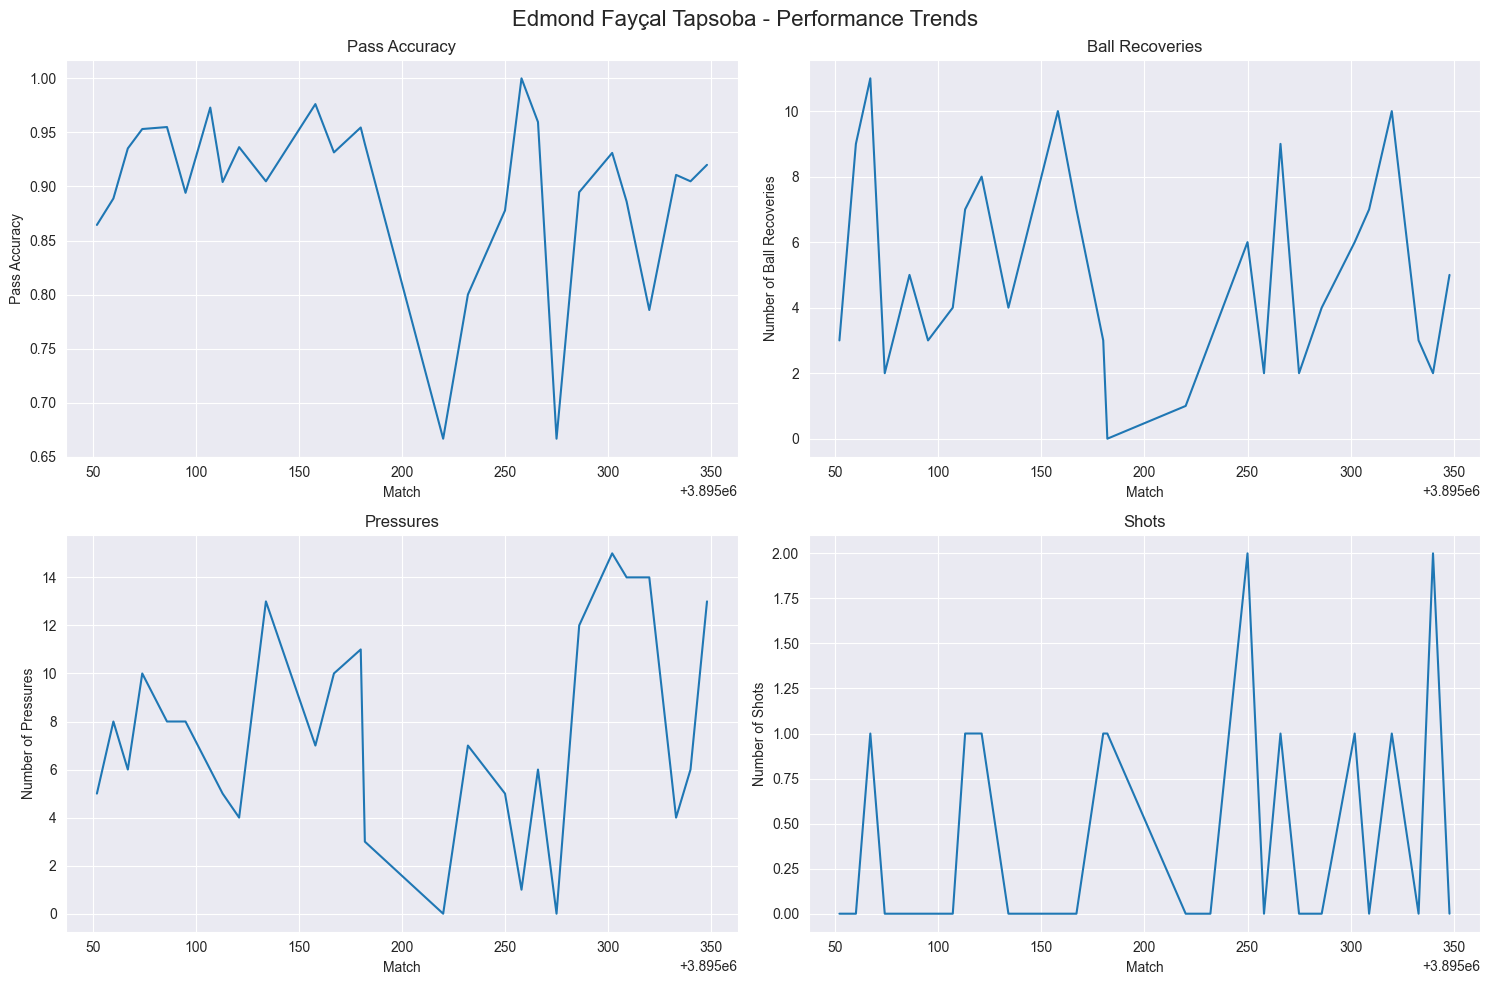


Summary Statistics for Edmond Fayçal Tapsoba:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     27.000000          27.000000        27.000000  27.000000  27.000000   
mean      72.074074          66.037037         5.037037   7.444444   0.444444   
std       29.500881          28.098017         3.044307   4.272752   0.640513   
min        3.000000           2.000000         0.000000   0.000000   0.000000   
25%       57.500000          51.000000         3.000000   5.000000   0.000000   
50%       76.000000          70.000000         4.000000   7.000000   0.000000   
75%       90.000000          83.000000         7.000000  10.500000   1.000000   
max      111.000000         106.000000        11.000000  15.000000   2.000000   

       pass_accuracy      match_id  
count      27.000000  2.700000e+01  
mean        0.896825  3.895198e+06  
std         0.081798  9.803228e+01  
min         0.666667  3.895052e+06  
25%         0.887482  3.895110e+06  
5

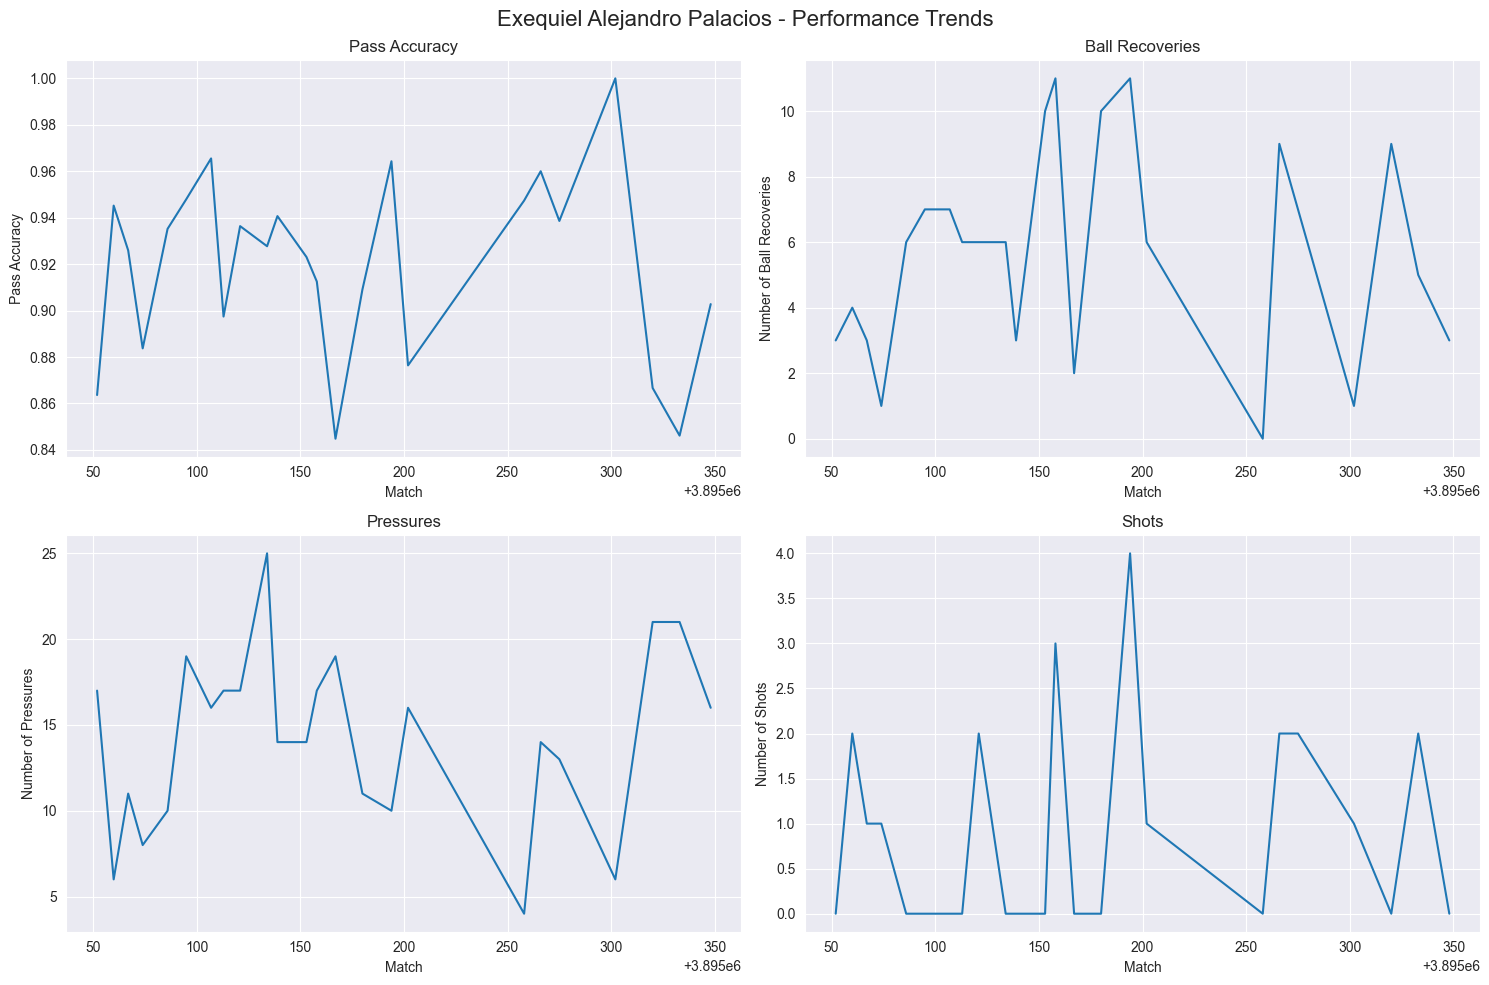


Summary Statistics for Exequiel Alejandro Palacios:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     24.000000          24.000000        24.000000  24.000000  24.000000   
mean      84.250000          77.791667         5.666667  14.250000   0.875000   
std       32.788187          31.918346         3.252647   5.235747   1.153916   
min       17.000000          17.000000         0.000000   4.000000   0.000000   
25%       64.500000          55.750000         3.000000  10.750000   0.000000   
50%       82.000000          76.000000         6.000000  15.000000   0.000000   
75%      110.500000         104.000000         7.500000  17.000000   2.000000   
max      150.000000         144.000000        11.000000  25.000000   4.000000   

       pass_accuracy      match_id  
count      24.000000  2.400000e+01  
mean        0.919210  3.895175e+06  
std         0.040044  9.279930e+01  
min         0.844828  3.895052e+06  
25%         0.894007  3.895104e+

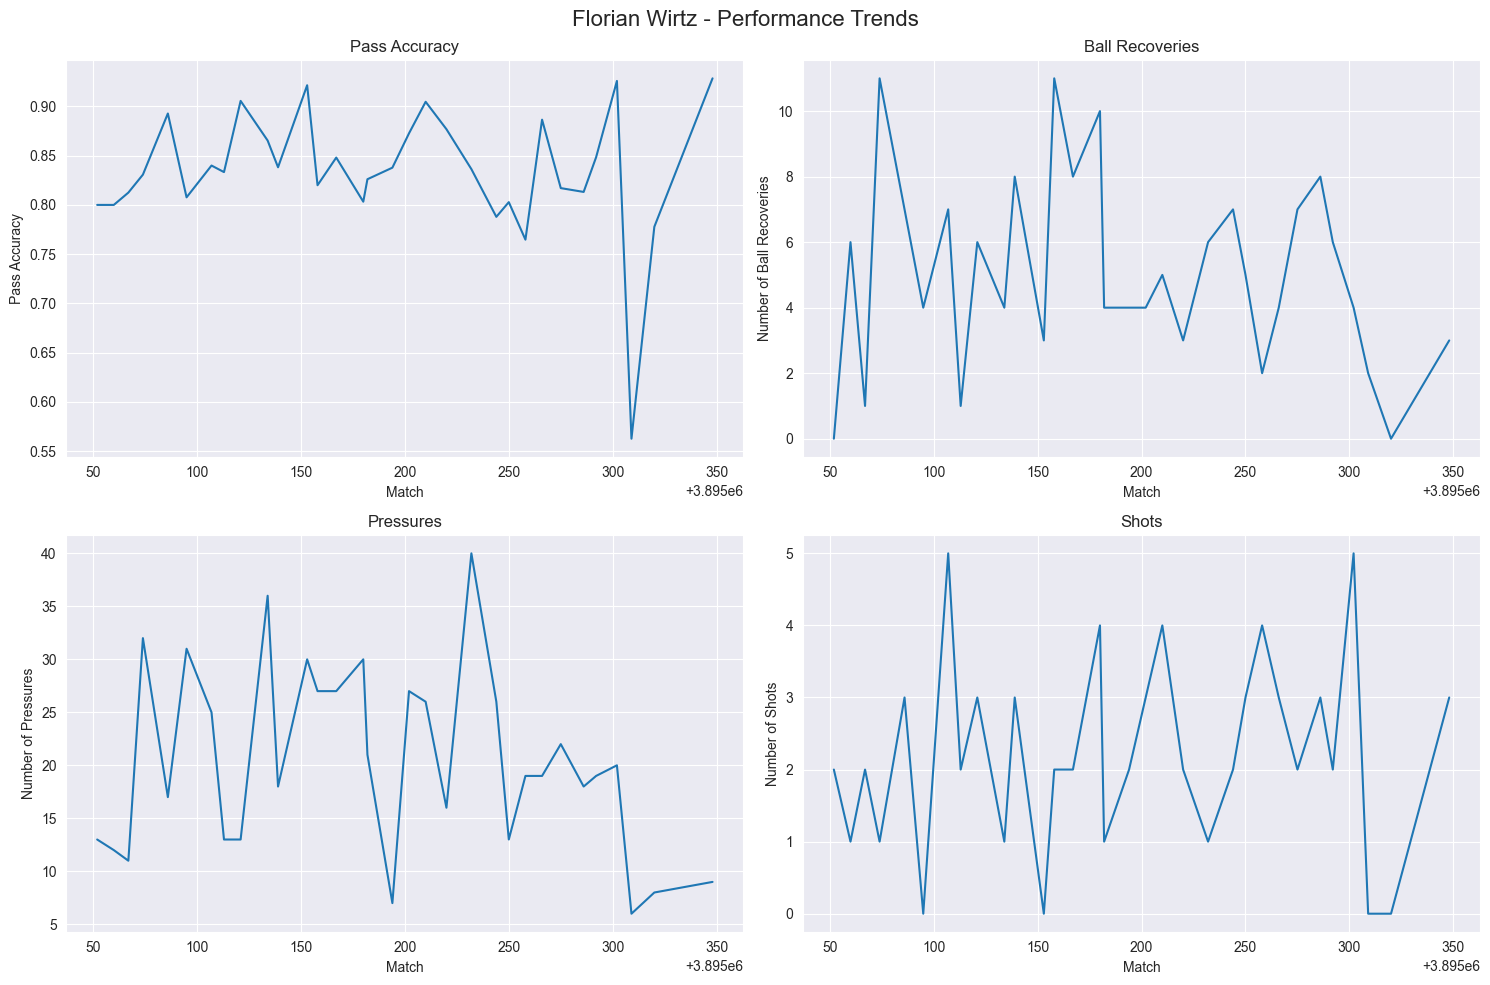


Summary Statistics for Florian Wirtz:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     32.000000          32.000000        32.000000  32.000000  32.000000   
mean      57.531250          48.218750         5.031250  20.343750   2.218750   
std       23.140503          19.679258         2.912535   8.749597   1.361554   
min       14.000000           9.000000         0.000000   6.000000   0.000000   
25%       46.750000          39.250000         3.000000  13.000000   1.000000   
50%       62.500000          51.000000         4.500000  19.000000   2.000000   
75%       69.500000          57.000000         7.000000  27.000000   3.000000   
max      100.000000          86.000000        11.000000  40.000000   5.000000   

       pass_accuracy      match_id  
count      32.000000  3.200000e+01  
mean        0.834050  3.895190e+06  
std         0.066337  8.544344e+01  
min         0.562500  3.895052e+06  
25%         0.806589  3.895119e+06  
50%      

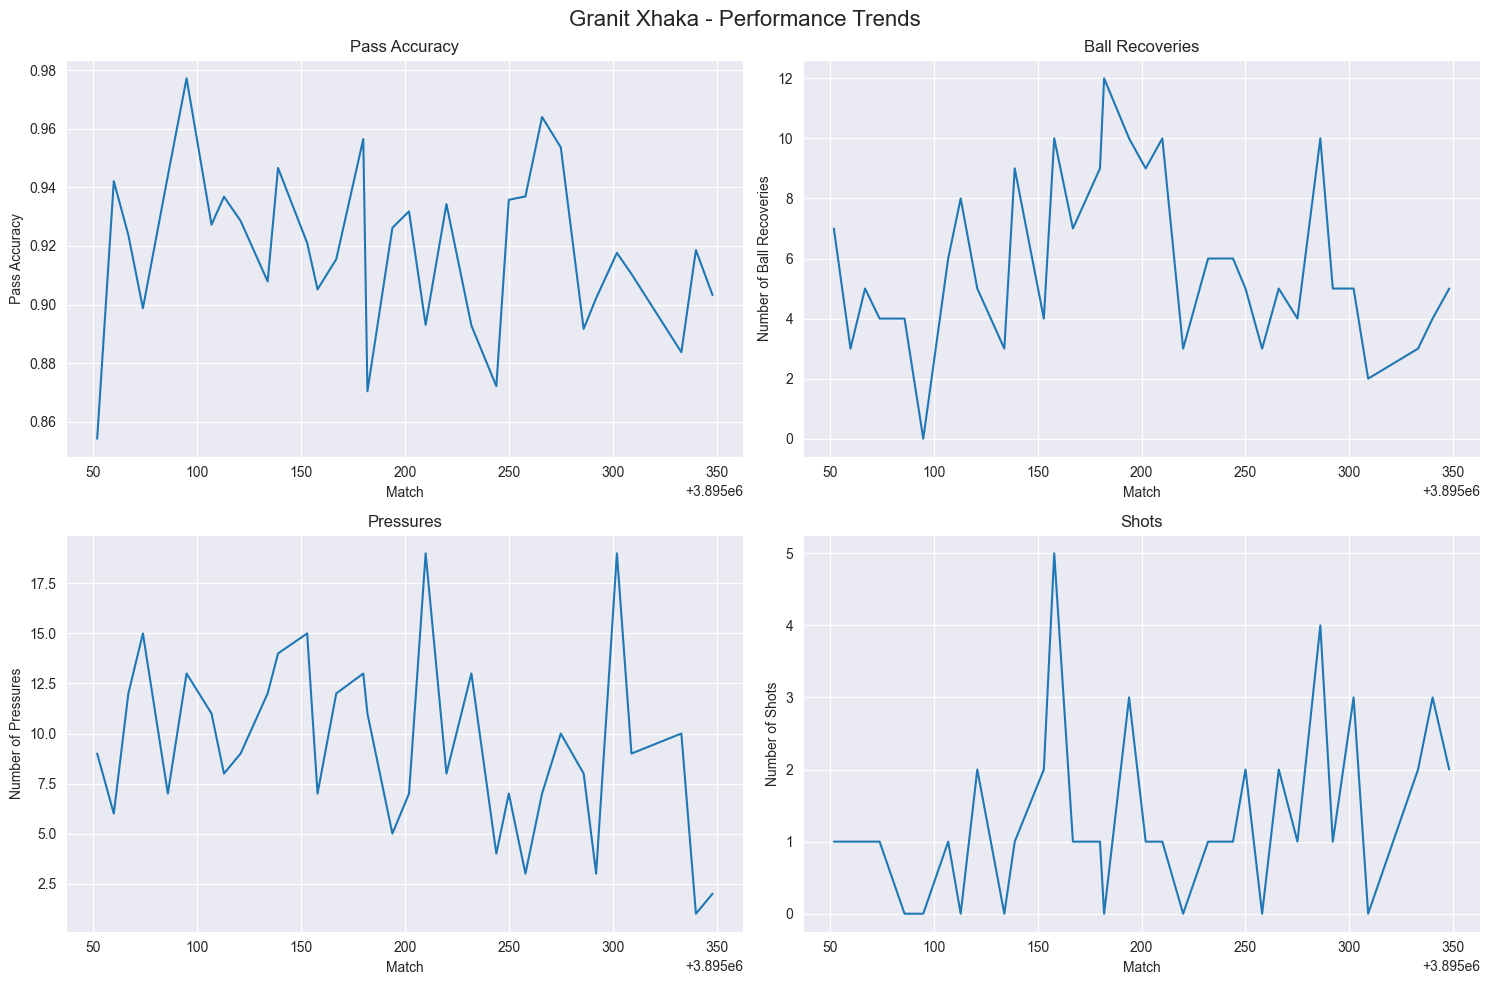


Summary Statistics for Granit Xhaka:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     33.000000          33.000000        33.000000  33.000000  33.000000   
mean      99.969697          92.272727         5.787879   9.363636   1.333333   
std       31.531219          30.217206         2.825747   4.456864   1.216210   
min       31.000000          28.000000         0.000000   1.000000   0.000000   
25%       85.000000          75.000000         4.000000   7.000000   1.000000   
50%      108.000000          94.000000         5.000000   9.000000   1.000000   
75%      118.000000         109.000000         8.000000  12.000000   2.000000   
max      167.000000         161.000000        12.000000  19.000000   5.000000   

       pass_accuracy      match_id  
count      33.000000  3.300000e+01  
mean        0.918917  3.895195e+06  
std         0.027942  8.863621e+01  
min         0.854167  3.895052e+06  
25%         0.902174  3.895121e+06  
50%       

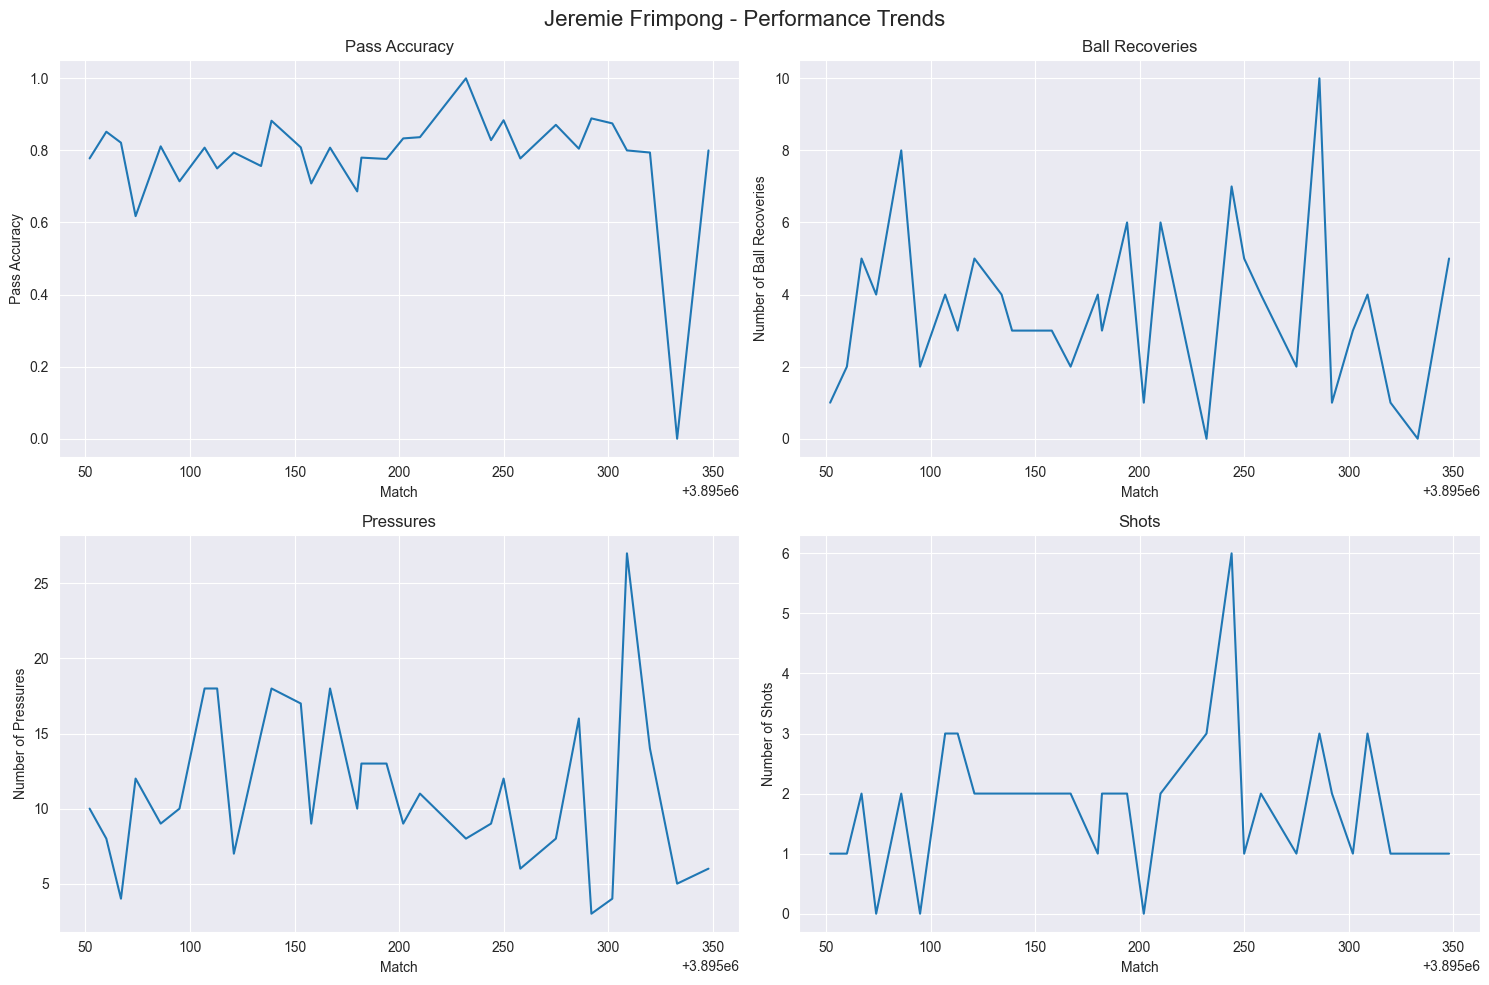


Summary Statistics for Jeremie Frimpong:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     31.000000          31.000000        31.000000  31.000000  31.000000   
mean      33.483871          26.483871         3.580645  11.193548   1.806452   
std       16.253966          12.961150         2.291640   5.344276   1.166743   
min        2.000000           0.000000         0.000000   3.000000   0.000000   
25%       27.000000          21.000000         2.000000   8.000000   1.000000   
50%       34.000000          27.000000         3.000000  10.000000   2.000000   
75%       45.000000          34.500000         5.000000  14.500000   2.000000   
max       76.000000          59.000000        10.000000  27.000000   6.000000   

       pass_accuracy      match_id  
count      31.000000  3.100000e+01  
mean        0.778914  3.895192e+06  
std         0.160589  8.944428e+01  
min         0.000000  3.895052e+06  
25%         0.777047  3.895117e+06  
50%   

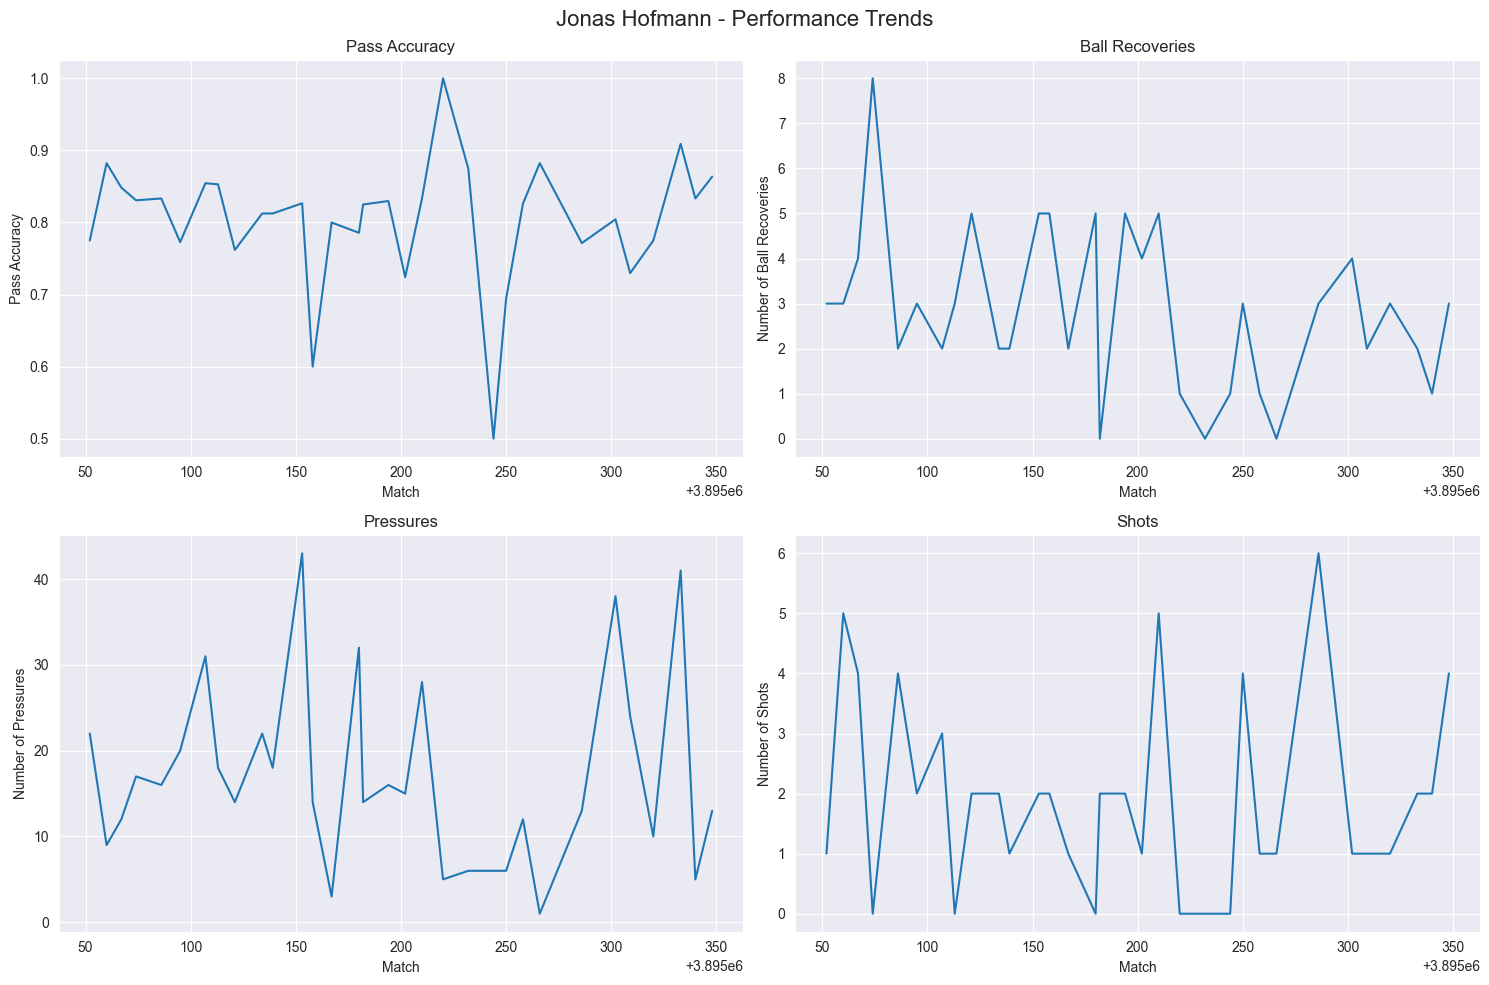


Summary Statistics for Jonas Hofmann:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     32.000000          32.000000        32.000000  32.000000  32.000000   
mean      47.750000          38.718750         2.875000  17.000000   1.937500   
std       22.871309          19.346141         1.809473  10.889474   1.644885   
min        4.000000           2.000000         0.000000   1.000000   0.000000   
25%       35.750000          26.500000         2.000000   9.750000   1.000000   
50%       46.000000          37.500000         3.000000  14.500000   2.000000   
75%       66.000000          55.250000         4.000000  22.000000   2.250000   
max       94.000000          78.000000         8.000000  43.000000   6.000000   

       pass_accuracy      match_id  
count      32.000000  3.200000e+01  
mean        0.803942  3.895194e+06  
std         0.089187  9.001449e+01  
min         0.500000  3.895052e+06  
25%         0.774432  3.895119e+06  
50%      

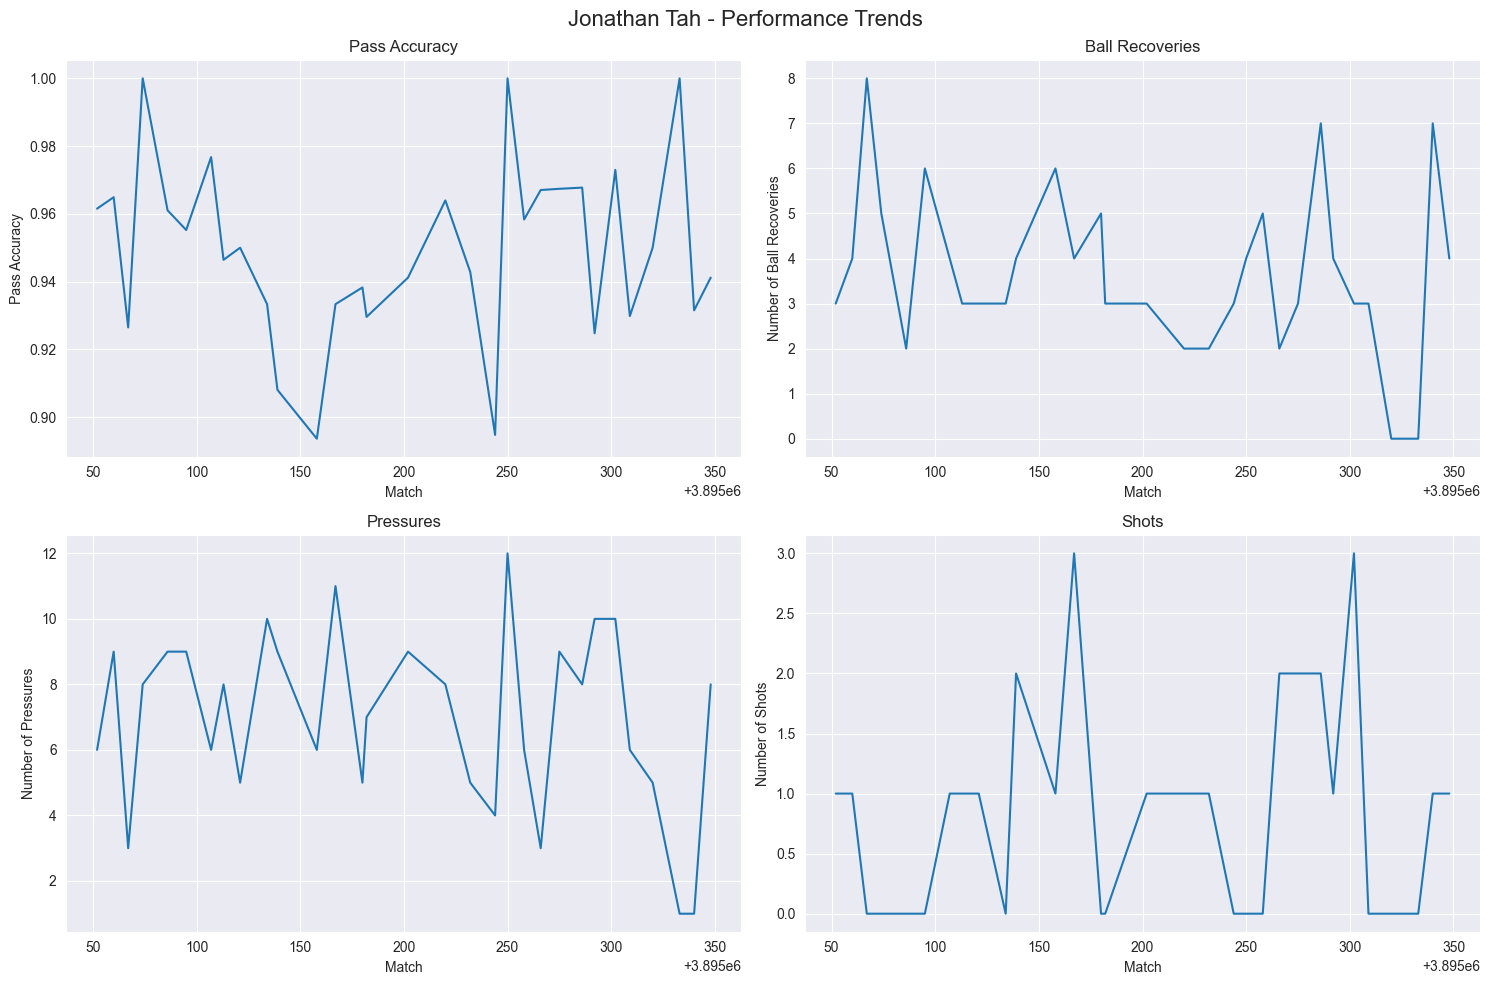


Summary Statistics for Jonathan Tah:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     31.000000          31.000000        31.000000  31.000000  31.000000   
mean      69.903226          66.354839         3.709677   6.967742   0.838710   
std       25.043103          24.100551         1.829272   2.774694   0.898027   
min        4.000000           4.000000         0.000000   1.000000   0.000000   
25%       57.000000          53.000000         3.000000   5.000000   0.000000   
50%       71.000000          66.000000         3.000000   8.000000   1.000000   
75%       86.500000          82.000000         4.500000   9.000000   1.000000   
max      120.000000         115.000000         8.000000  12.000000   3.000000   

       pass_accuracy      match_id  
count      31.000000  3.100000e+01  
mean        0.949419  3.895200e+06  
std         0.026878  9.383414e+01  
min         0.893617  3.895052e+06  
25%         0.932420  3.895117e+06  
50%       

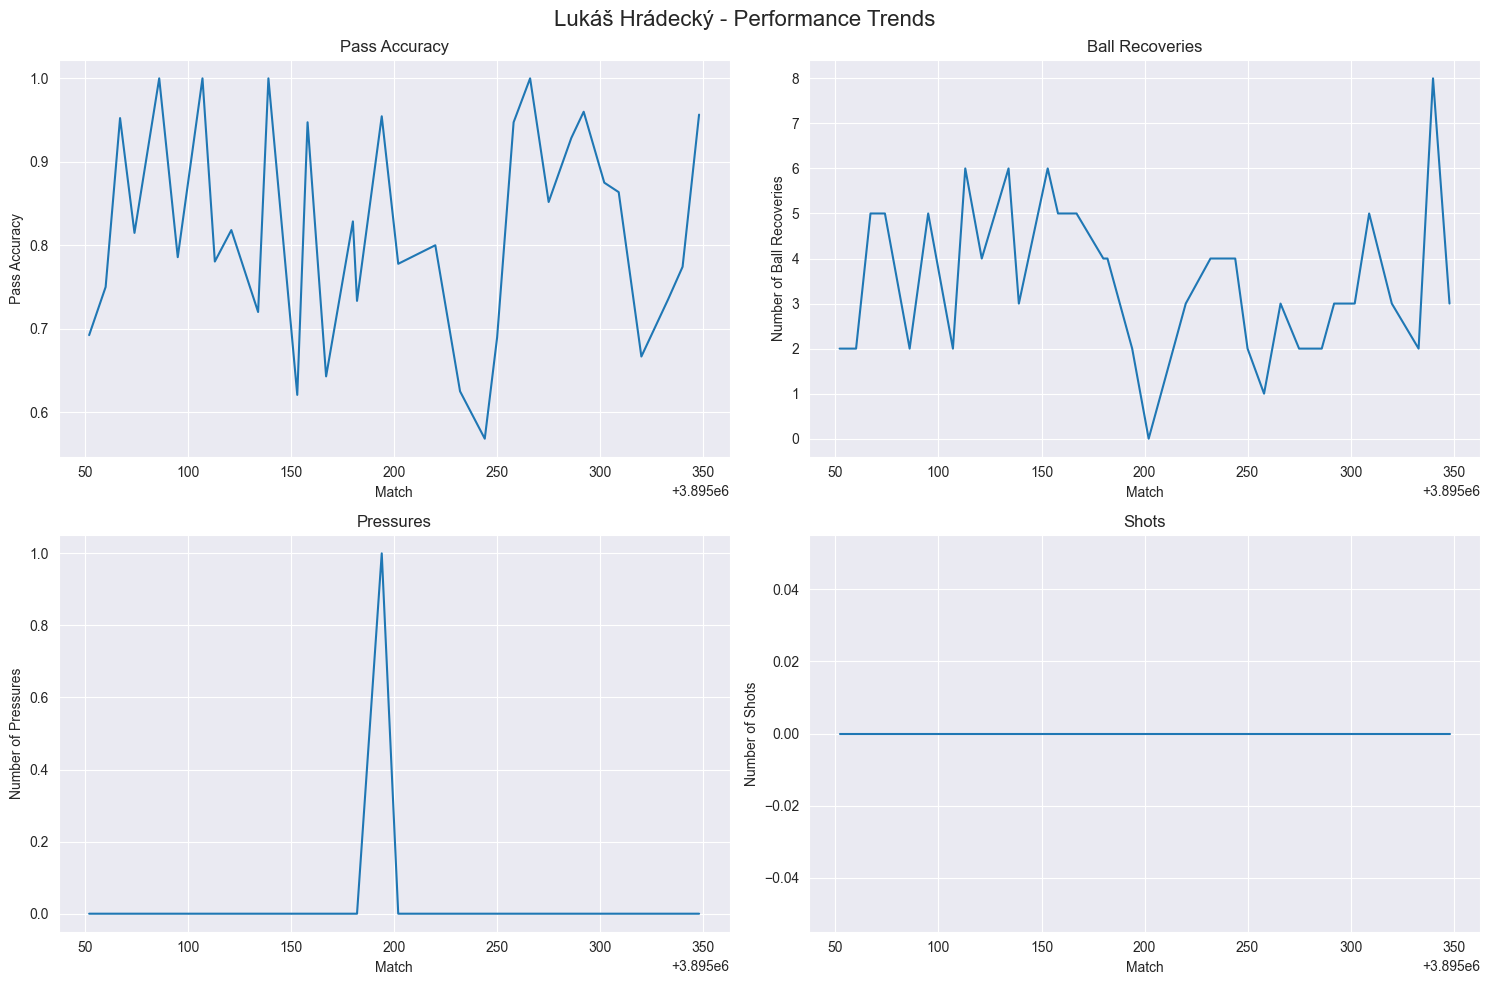


Summary Statistics for Lukáš Hrádecký:
       total_passes  successful_passes  ball_recoveries  pressures  shots  \
count     33.000000          33.000000        33.000000  33.000000   33.0   
mean      26.727273          21.424242         3.515152   0.030303    0.0   
std        7.242551           5.037548         1.716122   0.174078    0.0   
min       10.000000          10.000000         0.000000   0.000000    0.0   
25%       22.000000          18.000000         2.000000   0.000000    0.0   
50%       27.000000          21.000000         3.000000   0.000000    0.0   
75%       30.000000          24.000000         5.000000   0.000000    0.0   
max       44.000000          32.000000         8.000000   1.000000    0.0   

       pass_accuracy      match_id  
count      33.000000  3.300000e+01  
mean        0.820029  3.895199e+06  
std         0.127438  9.123186e+01  
min         0.568182  3.895052e+06  
25%         0.733333  3.895121e+06  
50%         0.814815  3.895194e+06  
75%    

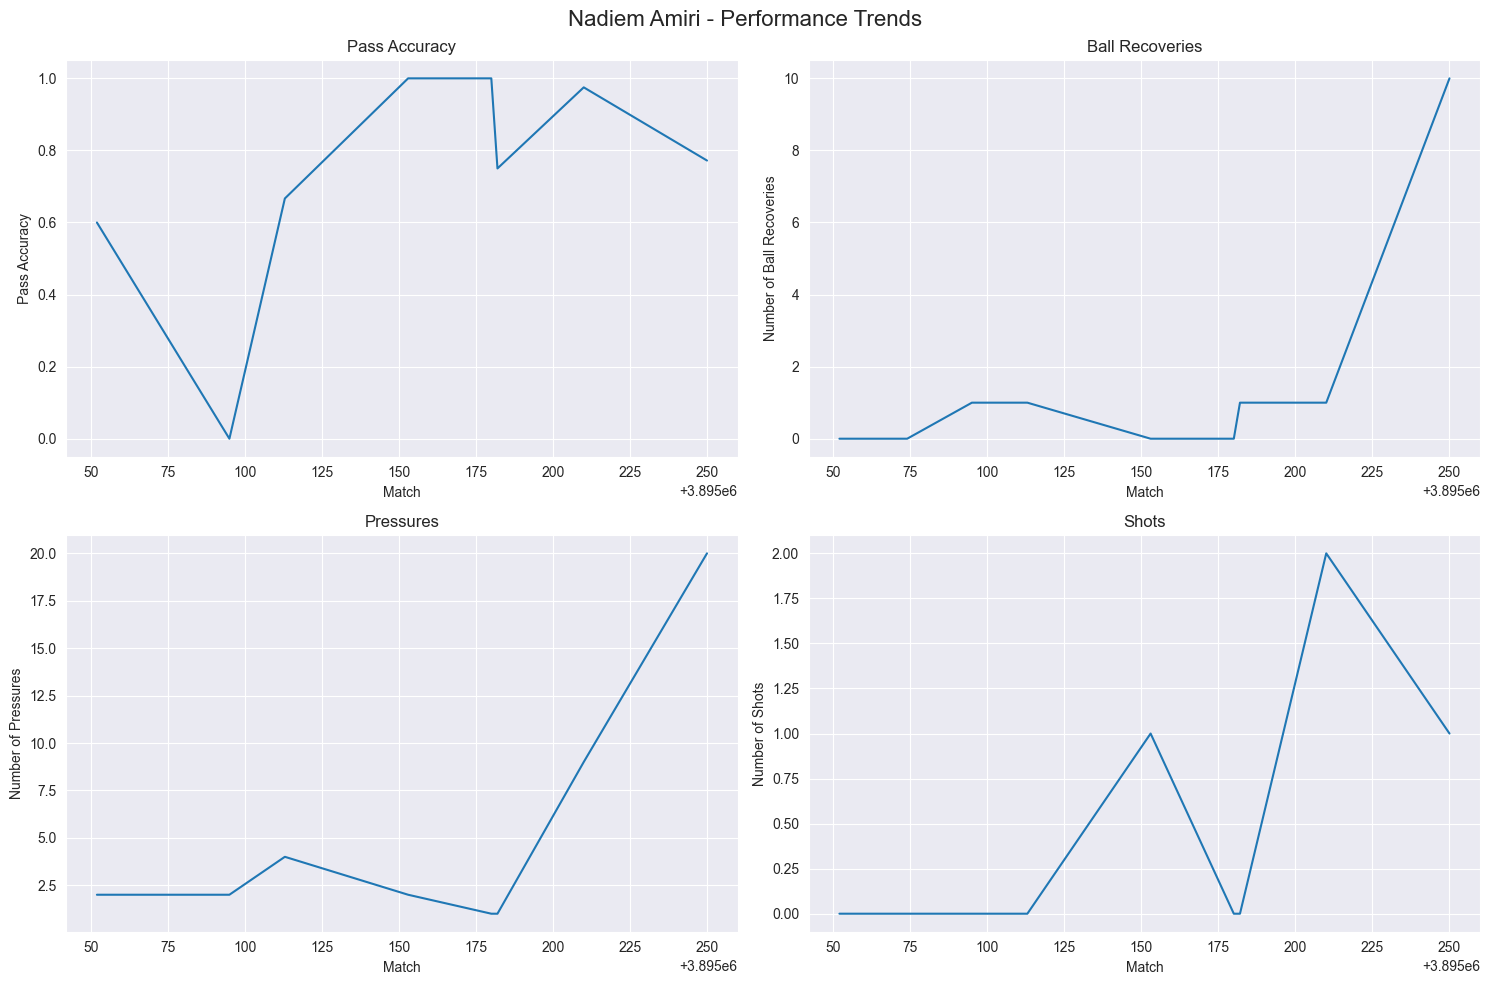


Summary Statistics for Nadiem Amiri:
       total_passes  successful_passes  ball_recoveries  pressures     shots  \
count      9.000000           9.000000         9.000000   9.000000  9.000000   
mean      17.222222          15.000000         1.555556   4.777778  0.444444   
std       29.680708          27.463612         3.205897   6.220486  0.726483   
min        0.000000           0.000000         0.000000   1.000000  0.000000   
25%        1.000000           1.000000         0.000000   2.000000  0.000000   
50%        4.000000           3.000000         1.000000   2.000000  0.000000   
75%        5.000000           4.000000         1.000000   4.000000  1.000000   
max       80.000000          78.000000        10.000000  20.000000  2.000000   

       pass_accuracy      match_id  
count       8.000000  9.000000e+00  
mean        0.720450  3.895145e+06  
std         0.329732  6.625728e+01  
min         0.000000  3.895052e+06  
25%         0.650000  3.895095e+06  
50%         0.76096

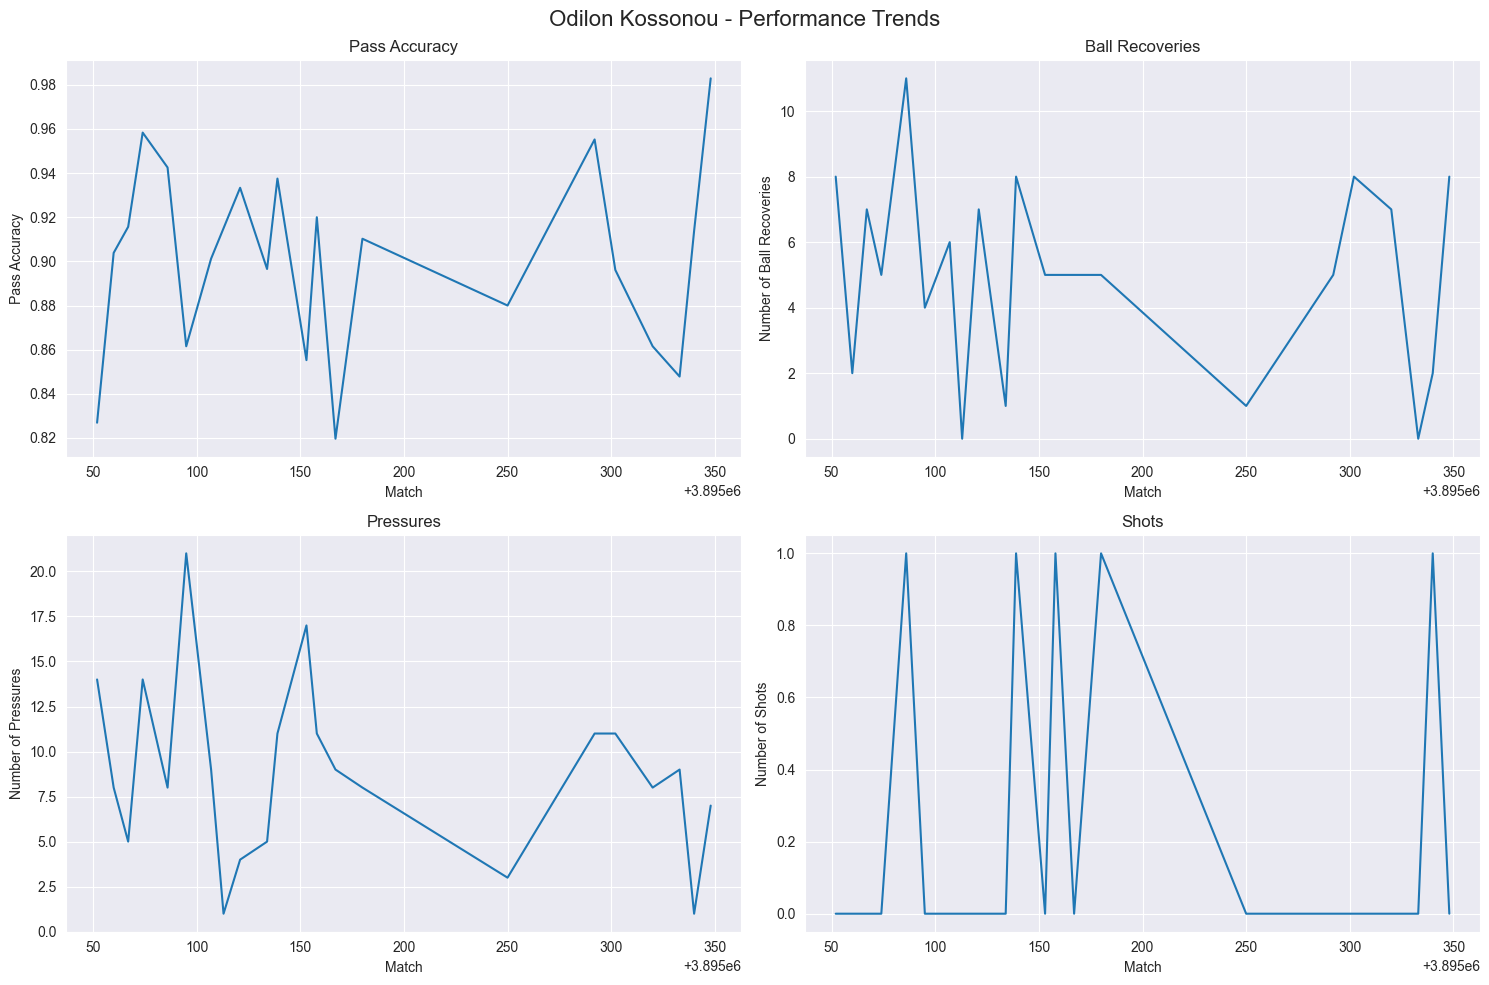


Summary Statistics for Odilon Kossonou:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     22.000000          22.000000        22.000000  22.000000  22.000000   
mean      64.636364          58.545455         5.000000   8.863636   0.227273   
std       23.326963          22.593145         2.976095   4.892126   0.428932   
min        0.000000           0.000000         0.000000   1.000000   0.000000   
25%       52.000000          46.250000         2.500000   5.500000   0.000000   
50%       66.000000          60.000000         5.000000   8.500000   0.000000   
75%       77.750000          70.750000         7.000000  11.000000   0.000000   
max      117.000000         115.000000        11.000000  21.000000   1.000000   

       pass_accuracy      match_id  
count      21.000000  2.200000e+01  
mean        0.900954  3.895177e+06  
std         0.043870  1.019506e+02  
min         0.819672  3.895052e+06  
25%         0.861538  3.895098e+06  
50%    

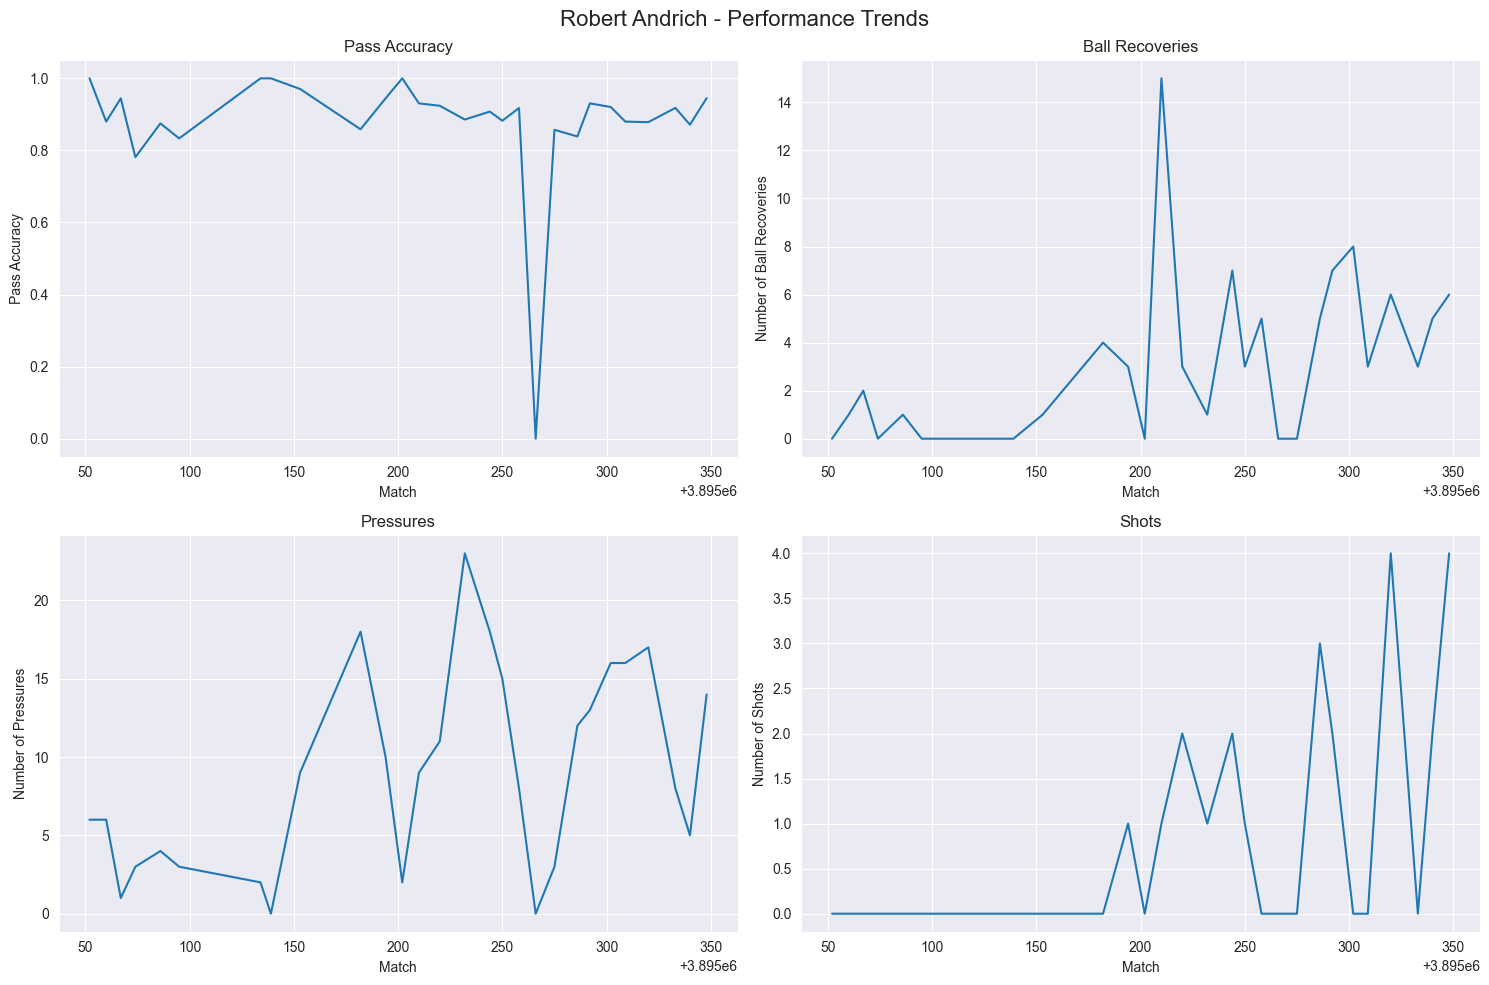


Summary Statistics for Robert Andrich:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     28.000000          28.000000        28.000000  28.000000  28.000000   
mean      53.607143          48.535714         3.178571   9.000000   0.821429   
std       38.382422          35.210985         3.443228   6.394442   1.248809   
min        1.000000           0.000000         0.000000   0.000000   0.000000   
25%       15.250000          13.750000         0.000000   3.000000   0.000000   
50%       63.000000          57.500000         3.000000   8.500000   0.000000   
75%       85.750000          78.000000         5.000000  14.250000   1.250000   
max      144.000000         134.000000        15.000000  23.000000   4.000000   

       pass_accuracy      match_id  
count      28.000000  2.800000e+01  
mean        0.877692  3.895212e+06  
std         0.180499  9.370105e+01  
min         0.000000  3.895052e+06  
25%         0.874107  3.895138e+06  
50%     

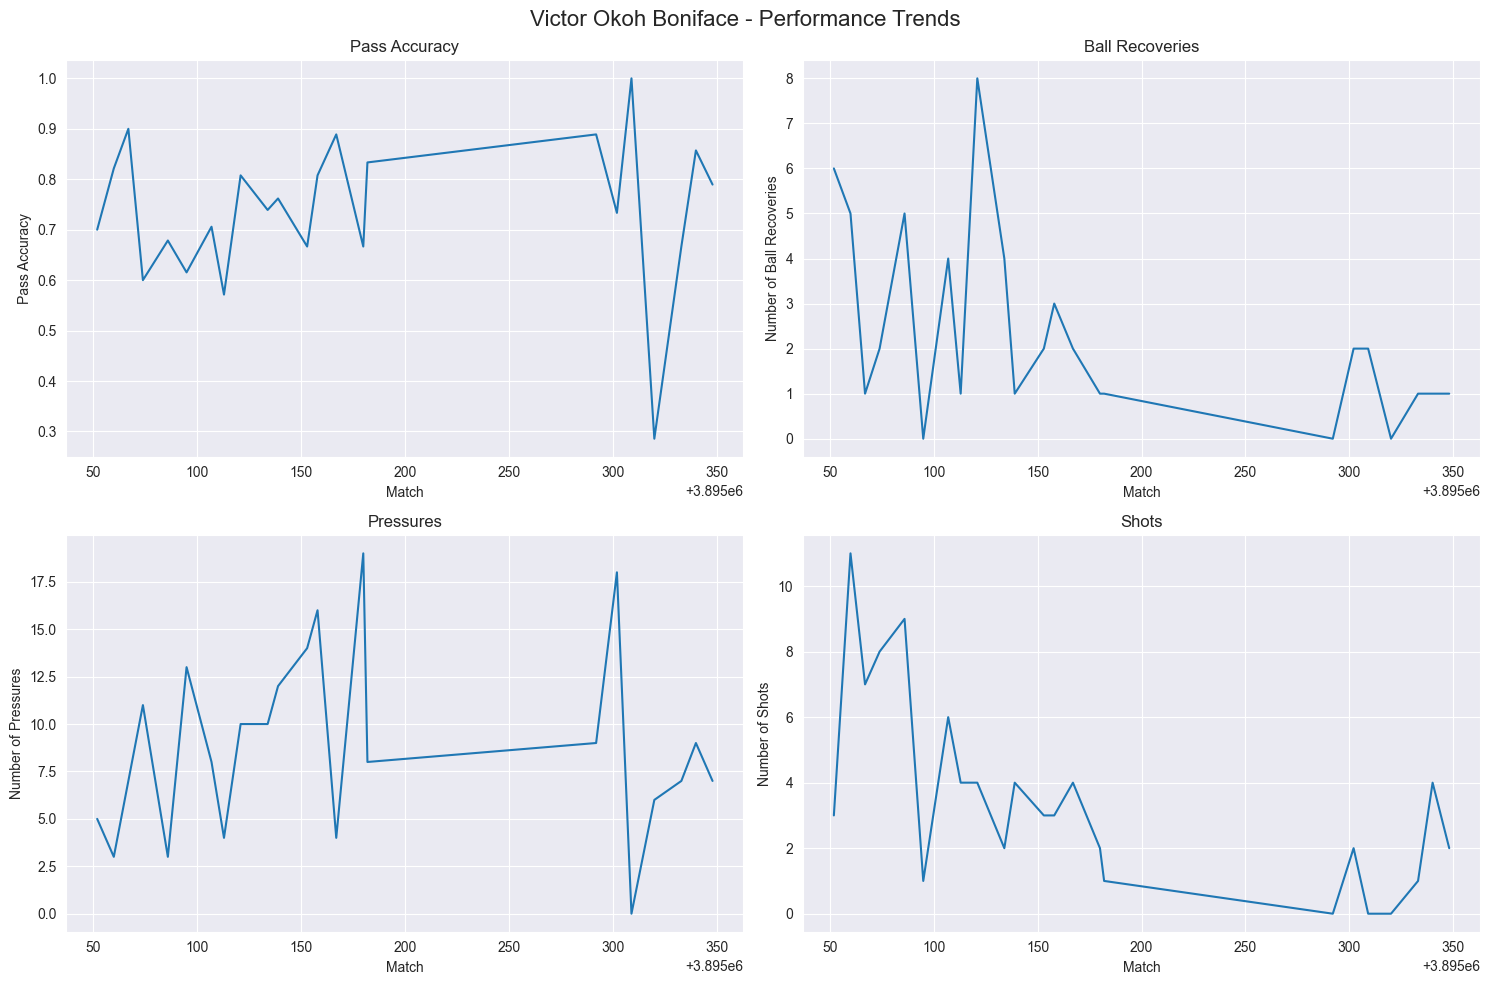


Summary Statistics for Victor Okoh Boniface:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     23.000000          23.000000        23.000000  23.000000  23.000000   
mean      17.000000          12.565217         2.304348   8.826087   3.521739   
std        8.522697           6.913926         2.098371   4.895751   2.952188   
min        1.000000           1.000000         0.000000   0.000000   0.000000   
25%        9.000000           8.000000         1.000000   5.500000   1.500000   
50%       17.000000          12.000000         2.000000   8.000000   3.000000   
75%       24.500000          16.500000         3.500000  11.500000   4.000000   
max       30.000000          27.000000         8.000000  19.000000  11.000000   

       pass_accuracy      match_id  
count      23.000000  2.300000e+01  
mean        0.738517  3.895180e+06  
std         0.146362  1.022989e+02  
min         0.285714  3.895052e+06  
25%         0.666667  3.895101e+06  
50

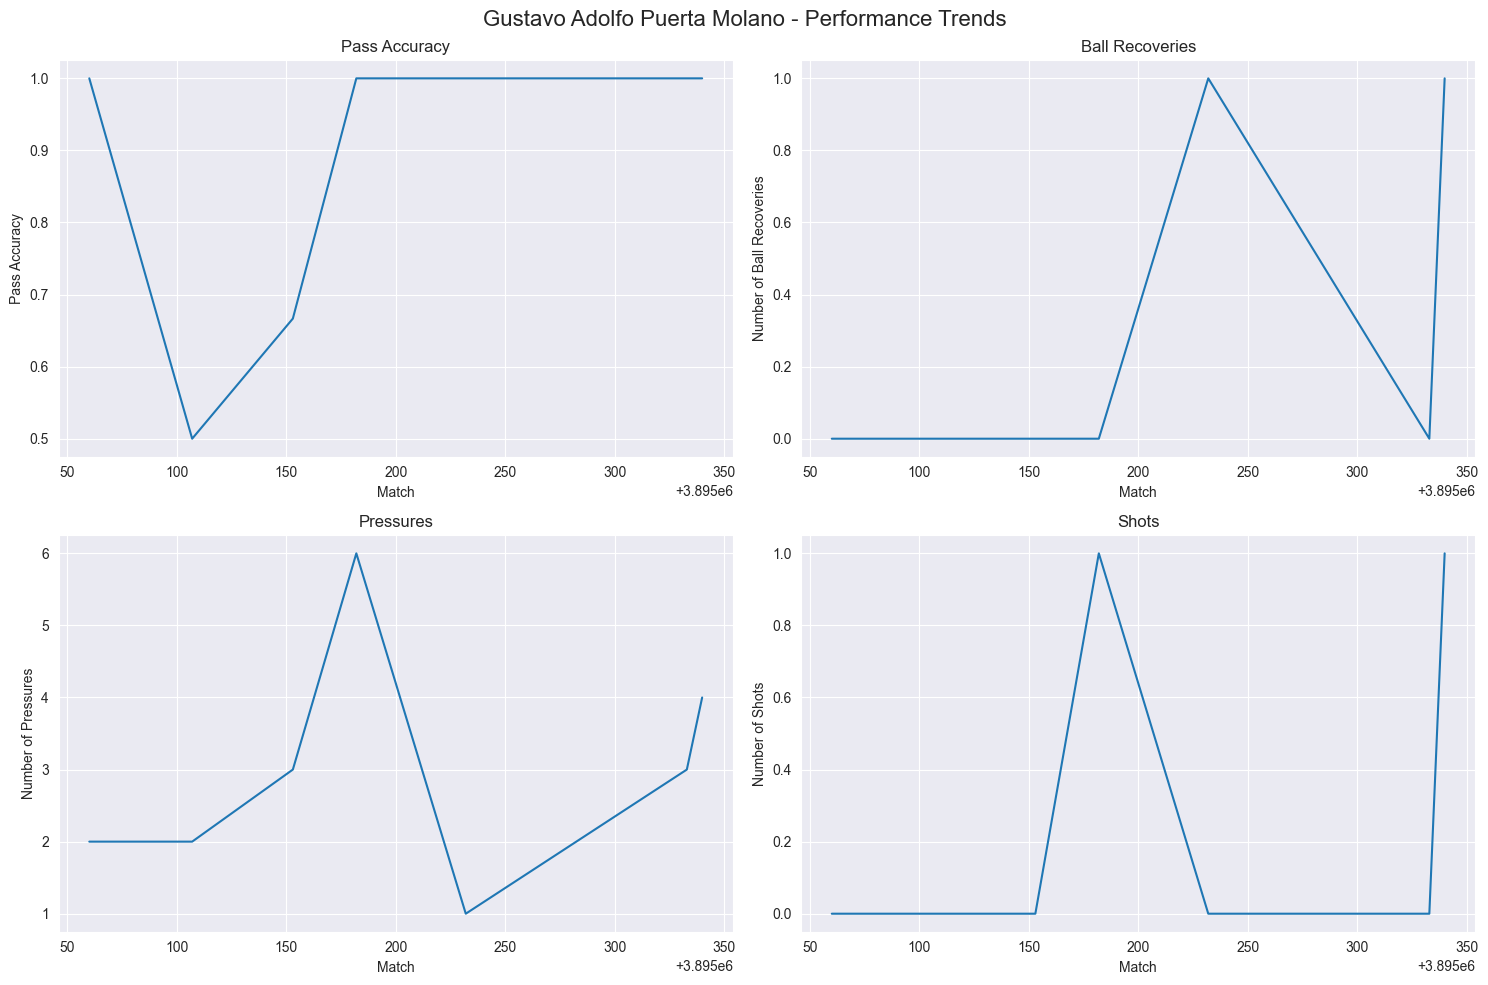


Summary Statistics for Gustavo Adolfo Puerta Molano:
       total_passes  successful_passes  ball_recoveries  pressures     shots  \
count      7.000000           7.000000         7.000000   7.000000  7.000000   
mean       6.142857           5.857143         0.285714   3.000000  0.285714   
std        6.792853           6.986381         0.487950   1.632993  0.487950   
min        1.000000           1.000000         0.000000   1.000000  0.000000   
25%        2.000000           1.500000         0.000000   2.000000  0.000000   
50%        3.000000           2.000000         0.000000   3.000000  0.000000   
75%        9.000000           9.000000         0.500000   3.500000  0.500000   
max       17.000000          17.000000         1.000000   6.000000  1.000000   

       pass_accuracy      match_id  
count       7.000000  7.000000e+00  
mean        0.880952  3.895201e+06  
std         0.208928  1.073064e+02  
min         0.500000  3.895060e+06  
25%         0.833333  3.895130e+06  
50%

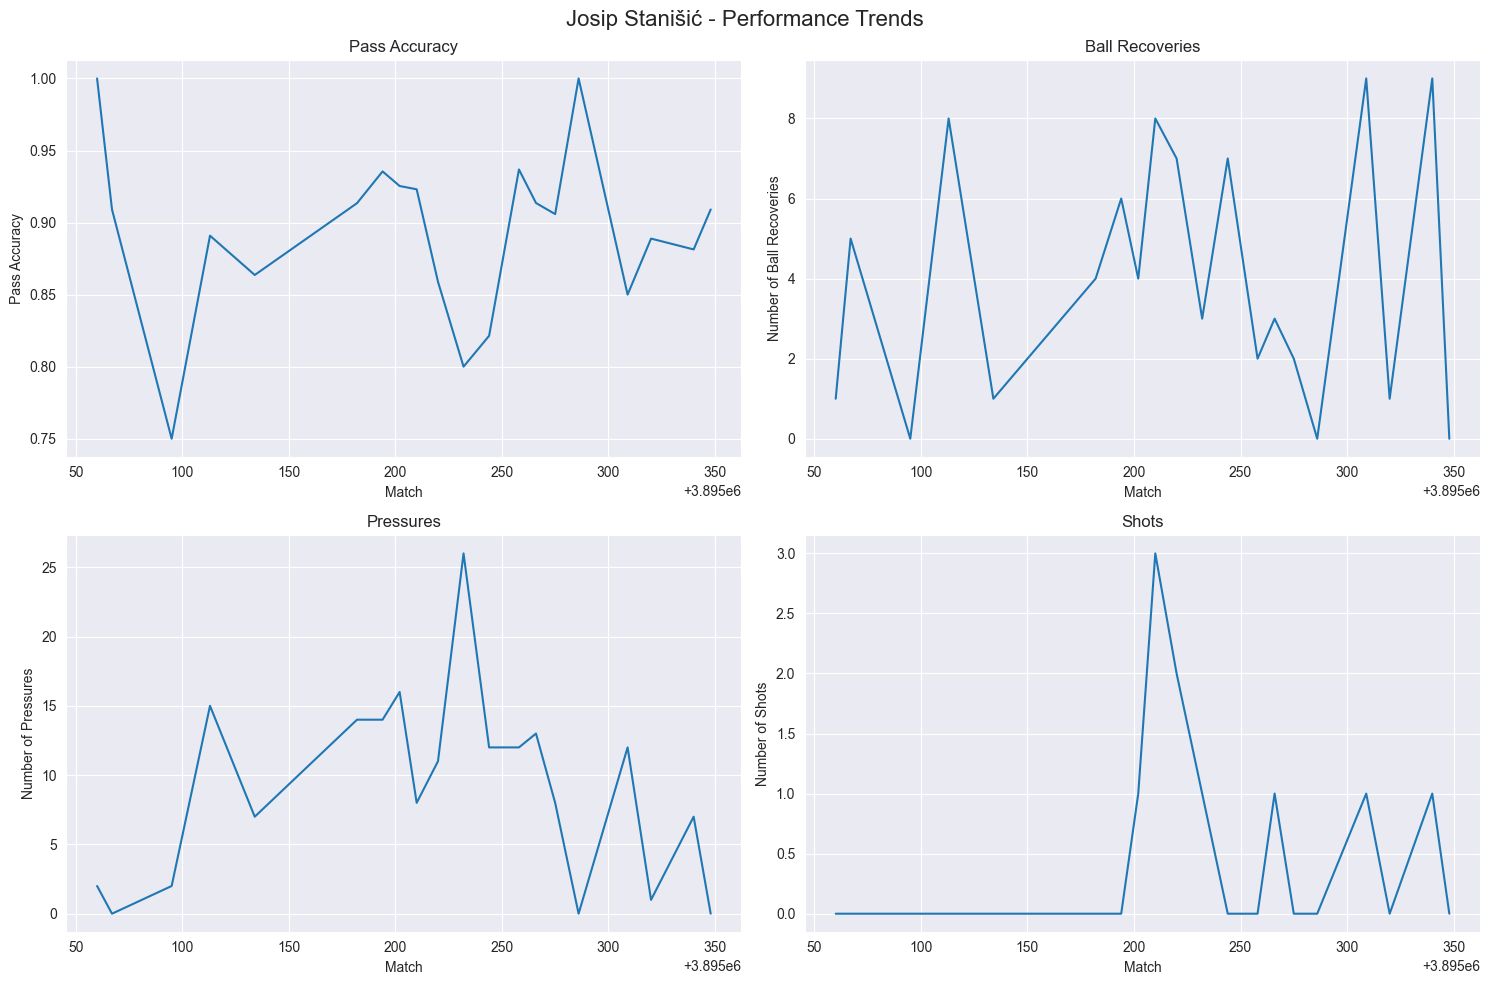


Summary Statistics for Josip Stanišić:
       total_passes  successful_passes  ball_recoveries  pressures     shots  \
count     20.000000          20.000000        20.000000  20.000000  20.00000   
mean      53.600000          48.150000         4.000000   9.000000   0.50000   
std       36.423532          33.583008         3.162278   6.828732   0.82717   
min        4.000000           3.000000         0.000000   0.000000   0.00000   
25%       19.250000          16.750000         1.000000   2.000000   0.00000   
50%       57.500000          50.000000         3.500000   9.500000   0.00000   
75%       82.000000          74.750000         7.000000  13.250000   1.00000   
max      117.000000         108.000000         9.000000  26.000000   3.00000   

       pass_accuracy      match_id  
count      20.000000  2.000000e+01  
mean        0.893854  3.895218e+06  
std         0.059972  8.774597e+01  
min         0.750000  3.895060e+06  
25%         0.862471  3.895170e+06  
50%         0.907

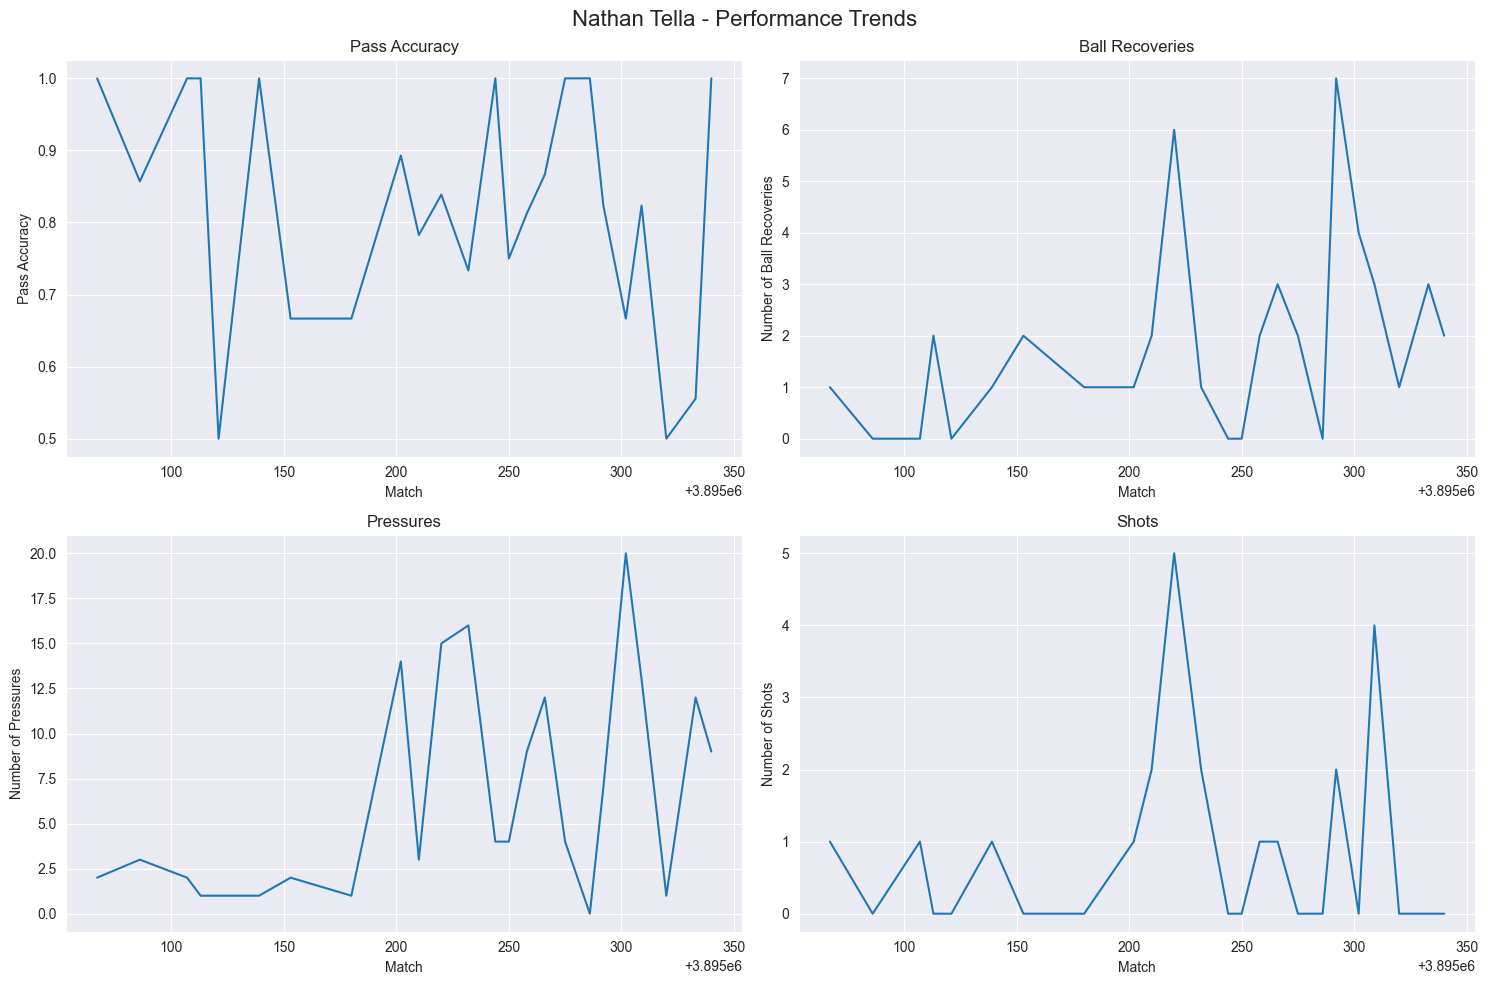


Summary Statistics for Nathan Tella:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     24.000000          24.000000        24.000000  24.000000  24.000000   
mean      14.250000          11.583333         1.833333   6.500000   0.875000   
std       11.233684           9.513910         1.833663   5.949059   1.329024   
min        2.000000           1.000000         0.000000   0.000000   0.000000   
25%        4.000000           3.750000         0.750000   1.750000   0.000000   
50%        9.500000           8.000000         1.500000   4.000000   0.000000   
75%       24.000000          19.500000         2.250000  12.000000   1.000000   
max       34.000000          28.000000         7.000000  20.000000   5.000000   

       pass_accuracy      match_id  
count      24.000000  2.400000e+01  
mean        0.822351  3.895221e+06  
std         0.165166  8.288047e+01  
min         0.500000  3.895067e+06  
25%         0.716667  3.895150e+06  
50%       

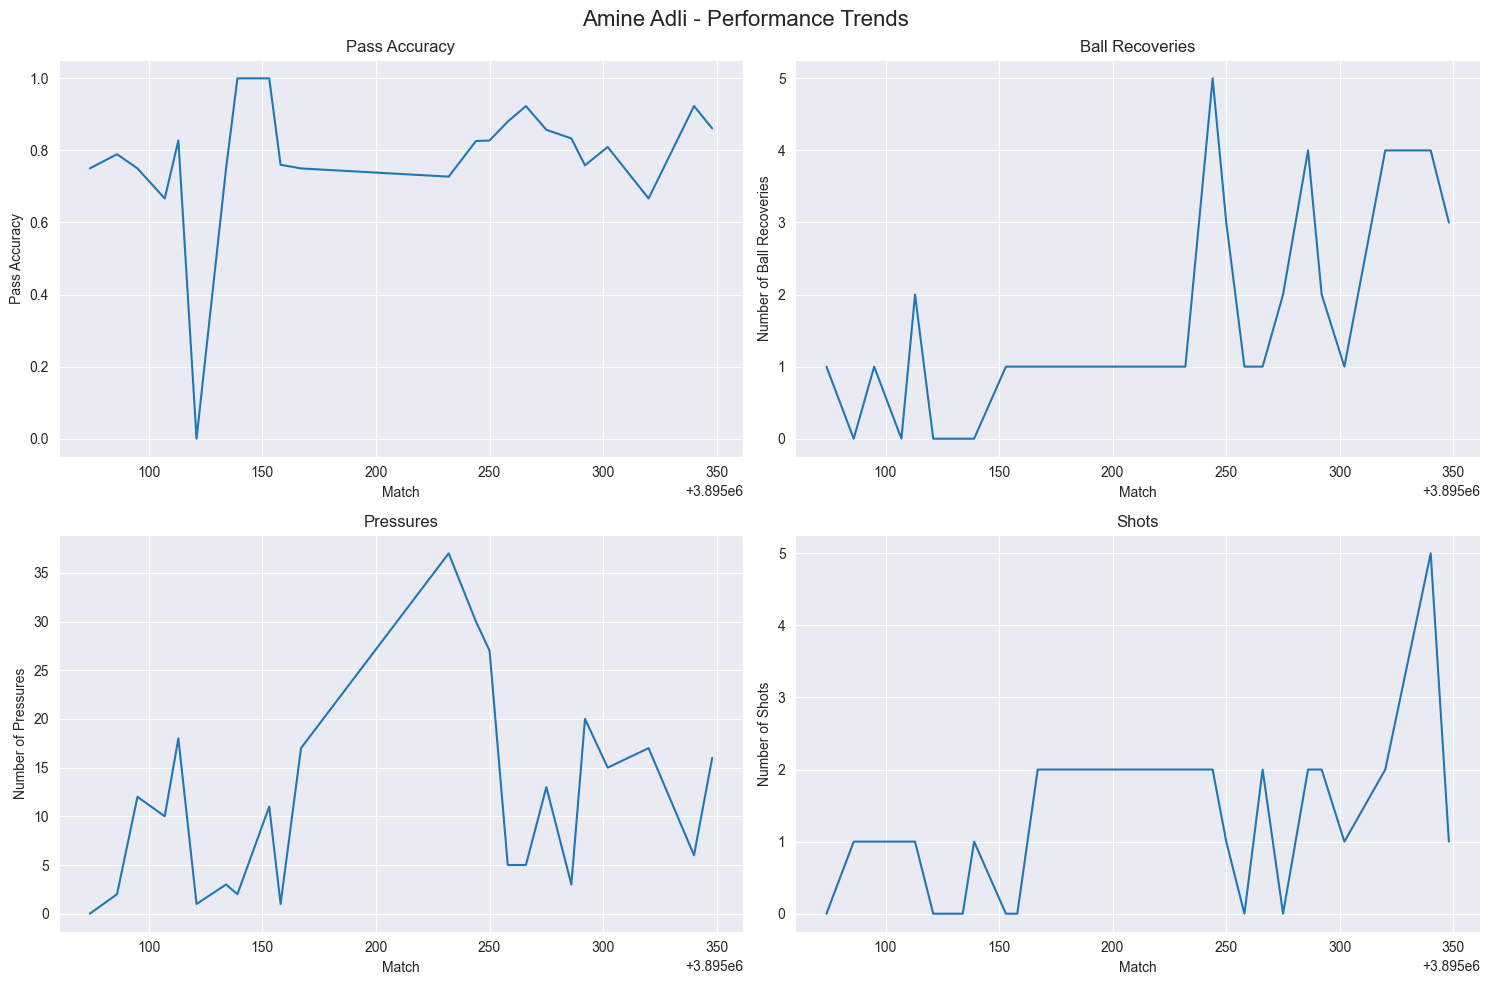


Summary Statistics for Amine Adli:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     23.000000          23.000000        23.000000  23.000000  23.000000   
mean      20.217391          16.260870         1.652174  11.782609   1.173913   
std       12.239862          10.014614         1.495712  10.081290   1.154130   
min        1.000000           0.000000         0.000000   0.000000   0.000000   
25%        8.500000           6.000000         1.000000   3.000000   0.000000   
50%       24.000000          18.000000         1.000000  11.000000   1.000000   
75%       29.000000          24.000000         2.500000  17.000000   2.000000   
max       46.000000          38.000000         5.000000  37.000000   5.000000   

       pass_accuracy      match_id  
count      23.000000  2.300000e+01  
mean        0.779879  3.895207e+06  
std         0.192124  8.927866e+01  
min         0.000000  3.895074e+06  
25%         0.750000  3.895128e+06  
50%         

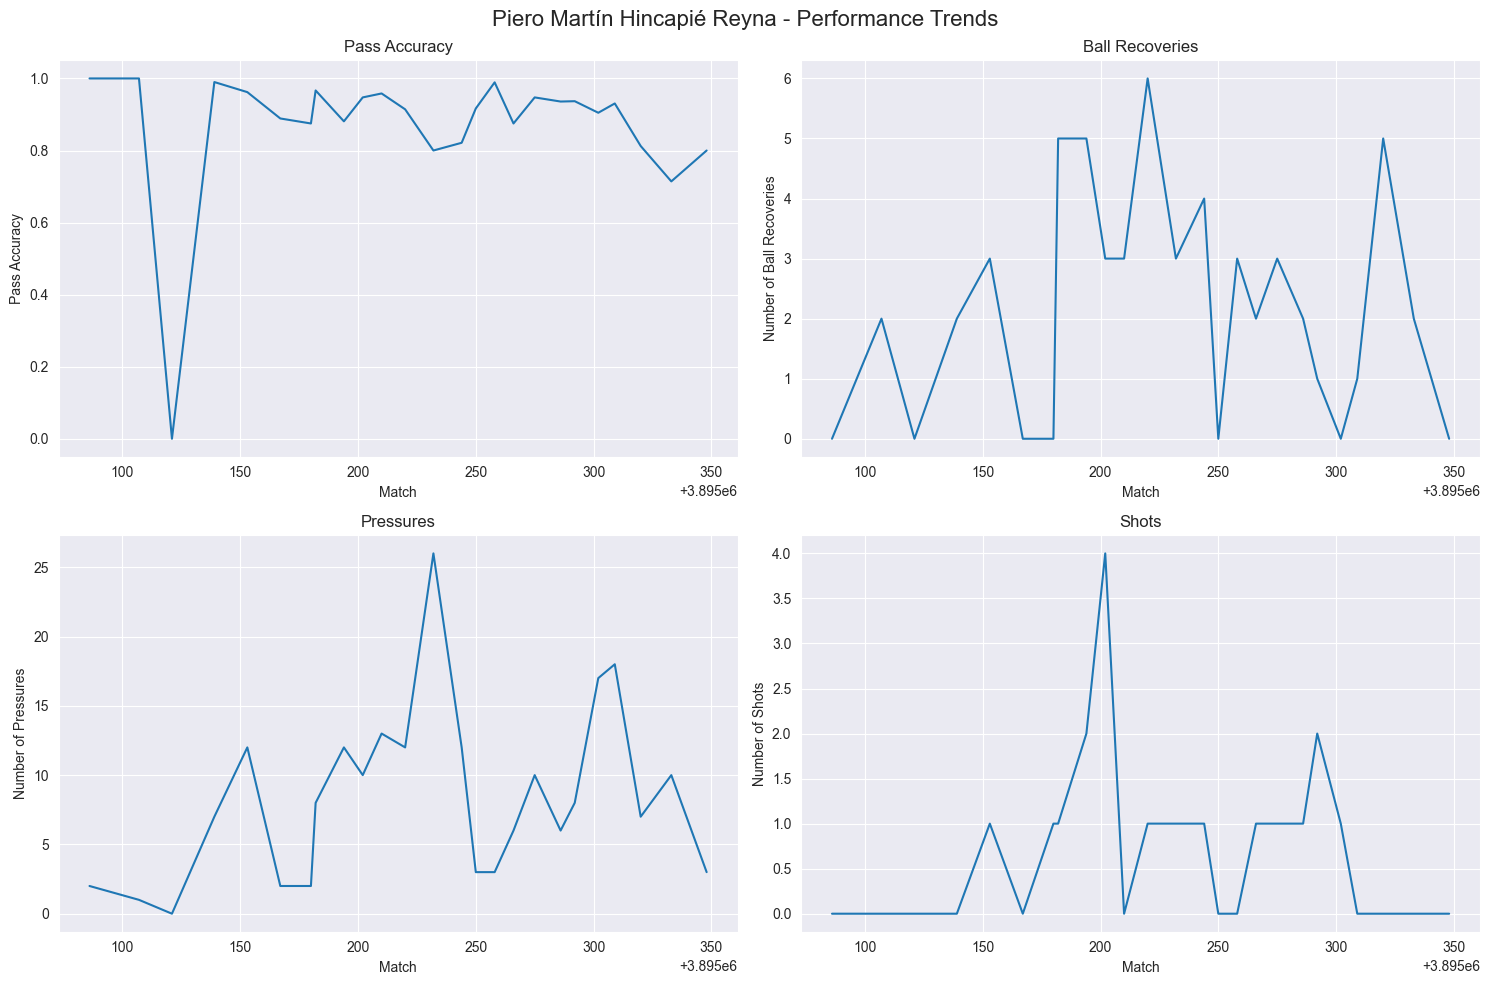


Summary Statistics for Piero Martín Hincapié Reyna:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     25.000000          25.000000        25.000000  25.000000  25.000000   
mean      56.920000          52.560000         2.200000   8.400000   0.720000   
std       36.764929          35.219644         1.848423   6.150881   0.936305   
min        1.000000           0.000000         0.000000   0.000000   0.000000   
25%       16.000000          16.000000         0.000000   3.000000   0.000000   
50%       64.000000          58.000000         2.000000   8.000000   1.000000   
75%       84.000000          76.000000         3.000000  12.000000   1.000000   
max      120.000000         115.000000         6.000000  26.000000   4.000000   

       pass_accuracy      match_id  
count      25.000000  2.500000e+01  
mean        0.870718  3.895227e+06  
std         0.195249  7.326691e+01  
min         0.000000  3.895086e+06  
25%         0.875000  3.895180e+

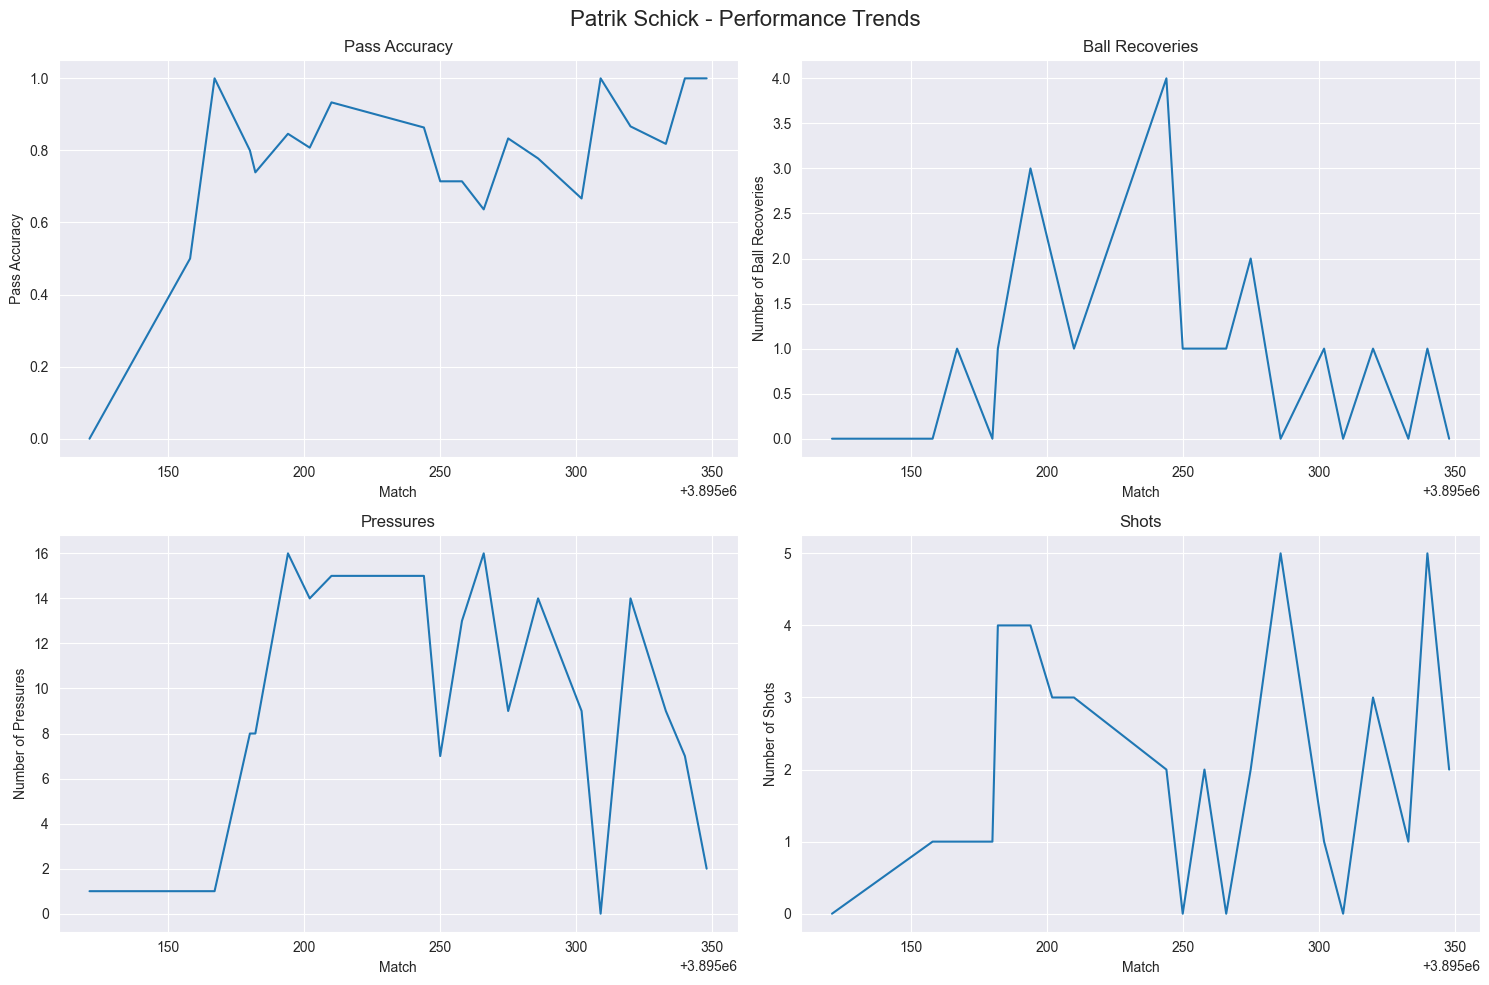


Summary Statistics for Patrik Schick:
       total_passes  successful_passes  ball_recoveries  pressures      shots  \
count     20.000000          20.000000        20.000000  20.000000  20.000000   
mean      11.450000           9.400000         1.000000   8.950000   2.000000   
std        8.531521           7.563068         1.076055   5.586403   1.622214   
min        1.000000           0.000000         0.000000   0.000000   0.000000   
25%        5.000000           4.000000         0.000000   5.750000   1.000000   
50%       10.000000           7.000000         1.000000   9.000000   2.000000   
75%       15.750000          13.500000         1.000000  14.000000   3.000000   
max       30.000000          28.000000         4.000000  16.000000   5.000000   

       pass_accuracy      match_id  
count      20.000000  2.000000e+01  
mean        0.775875  3.895247e+06  
std         0.226147  6.741925e+01  
min         0.000000  3.895121e+06  
25%         0.714286  3.895191e+06  
50%      

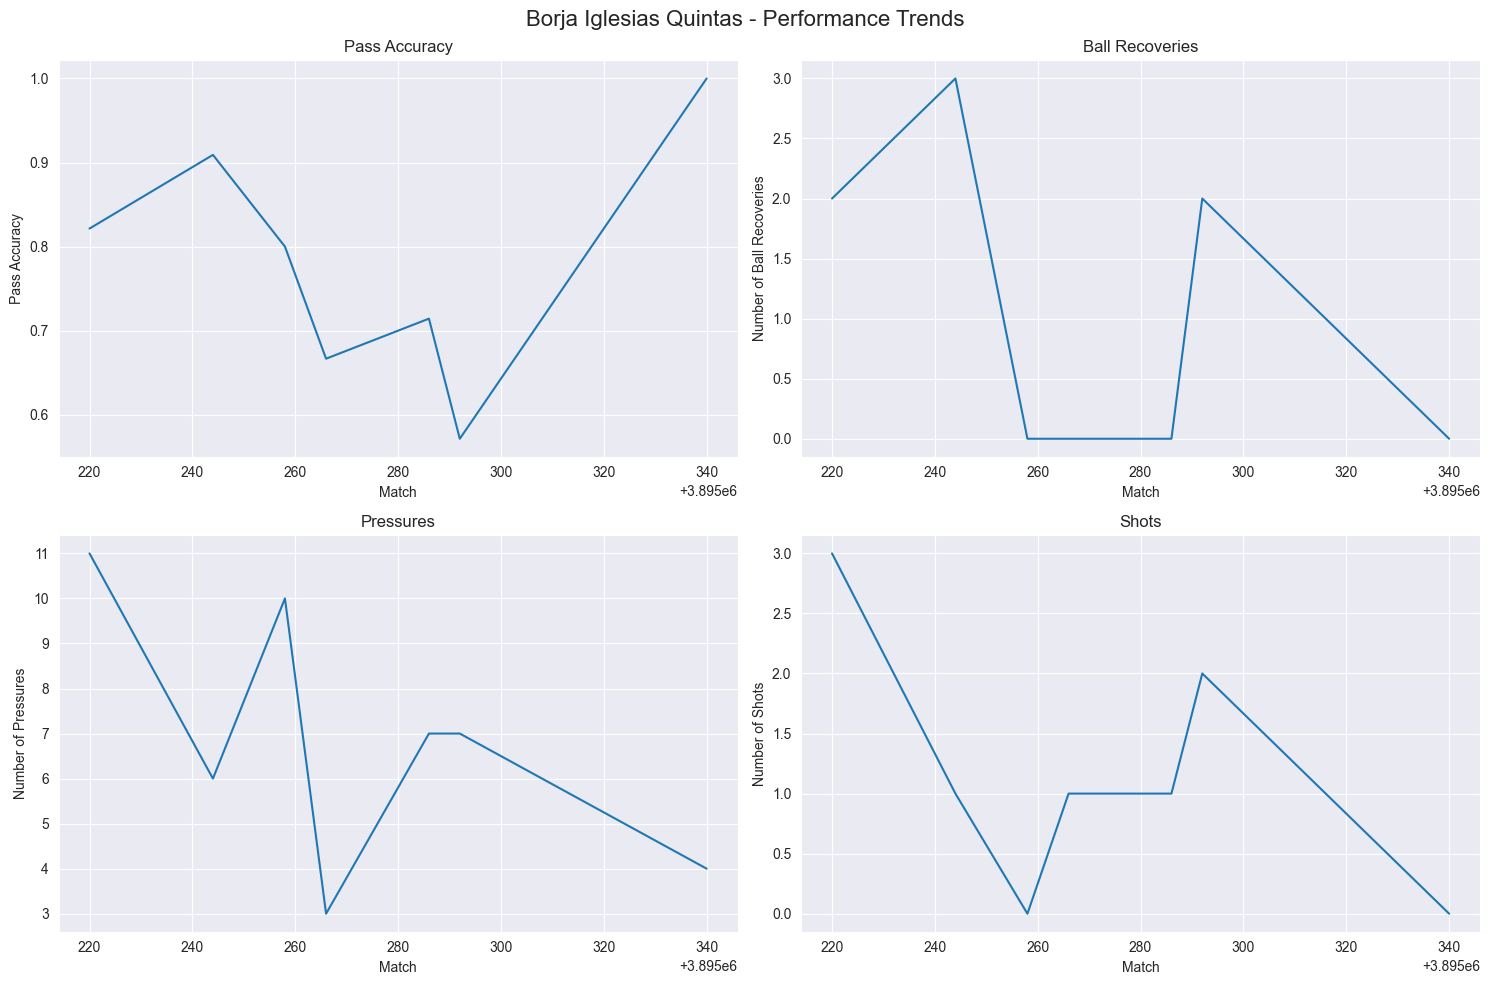


Summary Statistics for Borja Iglesias Quintas:
       total_passes  successful_passes  ball_recoveries  pressures     shots  \
count      7.000000           7.000000         7.000000   7.000000  7.000000   
mean      11.000000           8.571429         1.000000   6.857143  1.142857   
std        8.445906           6.924766         1.290994   2.911390  1.069045   
min        3.000000           2.000000         0.000000   3.000000  0.000000   
25%        5.500000           4.500000         0.000000   5.000000  0.500000   
50%       10.000000           8.000000         0.000000   7.000000  1.000000   
75%       12.500000           9.000000         2.000000   8.500000  1.500000   
max       28.000000          23.000000         3.000000  11.000000  3.000000   

       pass_accuracy      match_id  
count       7.000000  7.000000e+00  
mean        0.783271  3.895272e+06  
std         0.145928  3.859928e+01  
min         0.571429  3.895220e+06  
25%         0.690476  3.895251e+06  
50%      

In [194]:
# Function to get match stats for all players
def get_match_stats(match_events):
    stats = pd.DataFrame({
        'player': match_events['player'],
        'total_passes': match_events['type'] == 'Pass',
        'successful_passes': (match_events['type'] == 'Pass') & (match_events['pass_outcome'].isna()),
        'ball_recoveries': match_events['type'] == 'Ball Recovery',
        'pressures': match_events['type'] == 'Pressure',
        'shots': match_events['type'] == 'Shot'
    })
    
    stats = stats.groupby('player').sum().reset_index()
    stats['pass_accuracy'] = stats['successful_passes'] / stats['total_passes']
    stats['match_id'] = match_events['match_id'].iloc[0]
    
    return stats

# Create match-by-match stats
match_stats = events_df.groupby('match_id').apply(get_match_stats).reset_index(drop=True)

# Get list of players
players = match_stats['player'].unique()

# Create plots for each player
for player in players:
    player_stats = match_stats[match_stats['player'] == player]
    
    if len(player_stats) < 5:  # Skip players with too few appearances
        continue
    
    plt.figure(figsize=(15, 10))
    plt.suptitle(f"{player} - Performance Trends", fontsize=16)

    # Pass accuracy
    plt.subplot(2, 2, 1)
    sns.lineplot(data=player_stats, x='match_id', y='pass_accuracy')
    plt.title("Pass Accuracy")
    plt.xlabel('Match')
    plt.ylabel('Pass Accuracy')

    # Ball recoveries
    plt.subplot(2, 2, 2)
    sns.lineplot(data=player_stats, x='match_id', y='ball_recoveries')
    plt.title("Ball Recoveries")
    plt.xlabel('Match')
    plt.ylabel('Number of Ball Recoveries')

    # Pressures
    plt.subplot(2, 2, 3)
    sns.lineplot(data=player_stats, x='match_id', y='pressures')
    plt.title("Pressures")
    plt.xlabel('Match')
    plt.ylabel('Number of Pressures')

    # Shots (for attacking players)
    plt.subplot(2, 2, 4)
    sns.lineplot(data=player_stats, x='match_id', y='shots')
    plt.title("Shots")
    plt.xlabel('Match')
    plt.ylabel('Number of Shots')

    plt.tight_layout()
    plt.show()

    # Print summary statistics for the player
    print(f"\nSummary Statistics for {player}:")
    print(player_stats.describe())
    print("\n" + "="*50 + "\n")

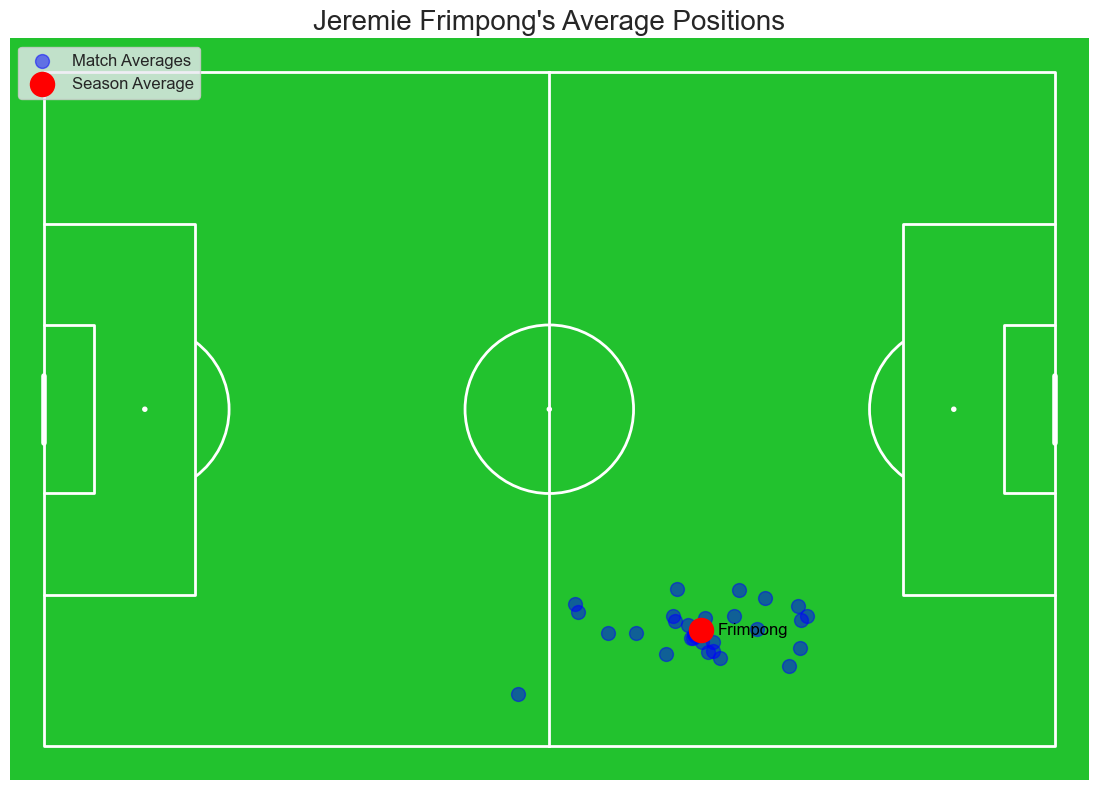

Frimpong's average position across the season: x=77.94, y=66.21


In [124]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import pandas as pd
import numpy as np

# Filter events for Frimpong
frimpong_events = events_df[events_df['player'] == 'Jeremie Frimpong']

# Calculate average position for each match
frimpong_positions = frimpong_events.groupby('match_id').agg({
    'x': 'mean',
    'y': 'mean'
}).reset_index()

# Calculate overall average position
average_x = frimpong_positions['x'].mean()
average_y = frimpong_positions['y'].mean()

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22c22e', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))

# Plot average positions for each match
scatter = pitch.scatter(frimpong_positions['x'], frimpong_positions['y'], ax=ax, 
                        s=100, color='blue', alpha=0.5, label='Match Averages')

# Plot overall average position
pitch.scatter(average_x, average_y, ax=ax, s=300, color='red', 
              label='Season Average')

# Add labels
ax.text(average_x + 2, average_y, 'Frimpong', fontsize=12, color='black', 
        ha='left', va='center')

# Add title and legend
ax.set_title("Jeremie Frimpong's Average Positions", fontsize=20)
ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Frimpong's average position across the season: x={average_x:.2f}, y={average_y:.2f}")

In [125]:
import pandas as pd

# Define a list of defensive positions
defensive_positions = [
    'Center Back',
    'Right Center Back',
    'Left Center Back',
    'Right Wing Back',
    'Left Wing Back',
    'Right Back',
    'Left Back'
]

# Filter the dataframe for Bayer Leverkusen defenders and get unique player-position pairs
leverkusen_defenders = events_df[(events_df['team'] == 'Bayer Leverkusen') & 
                                 (events_df['position'].isin(defensive_positions))][['player', 'position']].drop_duplicates()

# Sort defenders by position and then by name
leverkusen_defenders = leverkusen_defenders.sort_values(['position', 'player'])

# Print out the Bayer Leverkusen defenders
print("Identified Bayer Leverkusen Defenders:")
for _, row in leverkusen_defenders.iterrows():
    print(f"{row['player']}: {row['position']}")

# Create a list of Bayer Leverkusen defender names
leverkusen_defender_names = leverkusen_defenders['player'].tolist()

print("\nList of Bayer Leverkusen Defender Names:")
print(leverkusen_defender_names)

Identified Bayer Leverkusen Defenders:
Edmond Fayçal Tapsoba: Center Back
Jonathan Tah: Center Back
Josip Stanišić: Center Back
Odilon Kossonou: Center Back
Robert Andrich: Center Back
Alejandro Grimaldo García: Left Back
Amine Adli: Left Back
Piero Martín Hincapié Reyna: Left Back
Alejandro Grimaldo García: Left Center Back
Edmond Fayçal Tapsoba: Left Center Back
Jonathan Tah: Left Center Back
Odilon Kossonou: Left Center Back
Piero Martín Hincapié Reyna: Left Center Back
Alejandro Grimaldo García: Left Wing Back
Amine Adli: Left Wing Back
Arthur Augusto de Matos Soares: Left Wing Back
Jonas Hofmann: Left Wing Back
Nathan Tella: Left Wing Back
Piero Martín Hincapié Reyna: Left Wing Back
Jeremie Frimpong: Right Back
Josip Stanišić: Right Back
Nathan Tella: Right Back
Odilon Kossonou: Right Back
Edmond Fayçal Tapsoba: Right Center Back
Jonas Hofmann: Right Center Back
Jonathan Tah: Right Center Back
Josip Stanišić: Right Center Back
Odilon Kossonou: Right Center Back
Amine Adli: Right W

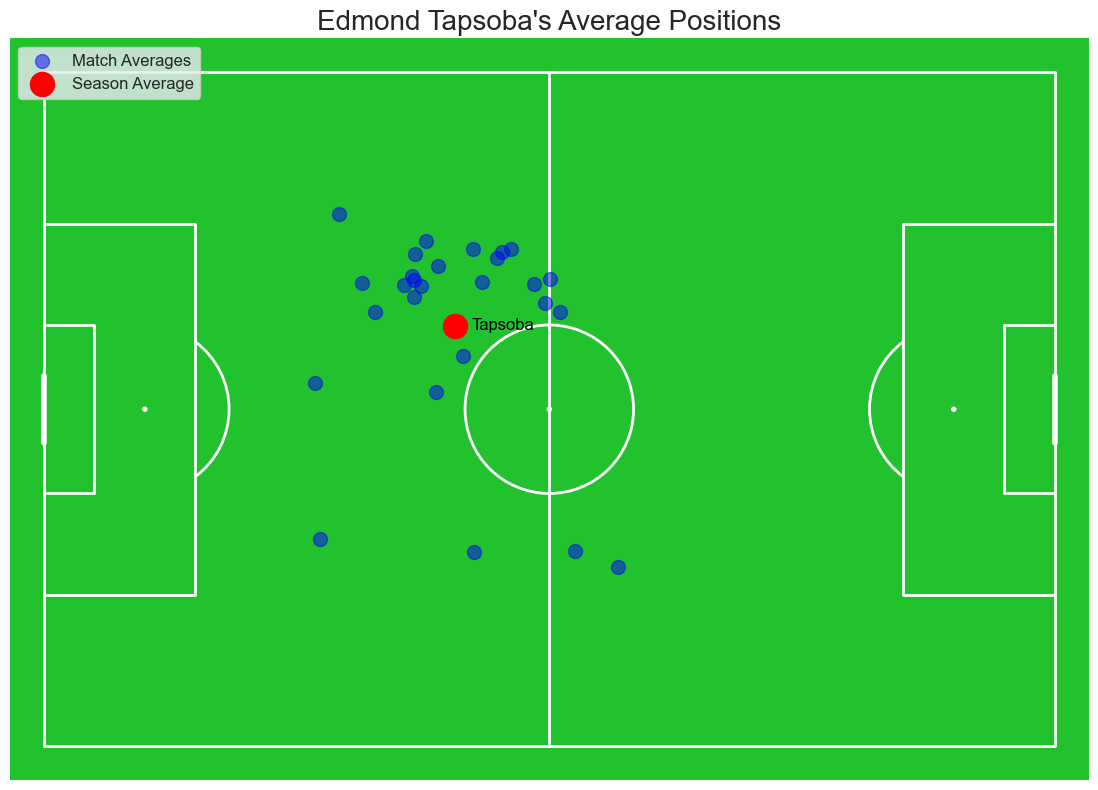

Tapsoba's average position across the season: x=48.76, y=30.12
Number of matches with data: 27


In [126]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import pandas as pd
import numpy as np

# Filter events for Tapsoba
tapsoba_events = events_df[events_df['player'] == 'Edmond Fayçal Tapsoba']

# Calculate average position for each match
tapsoba_positions = tapsoba_events.groupby('match_id').agg({
    'x': 'mean',
    'y': 'mean'
}).reset_index()

# Calculate overall average position
average_x = tapsoba_positions['x'].mean()
average_y = tapsoba_positions['y'].mean()

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22c22e', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))

# Plot average positions for each match
scatter = pitch.scatter(tapsoba_positions['x'], tapsoba_positions['y'], ax=ax, 
                        s=100, color='blue', alpha=0.5, label='Match Averages')

# Plot overall average position
pitch.scatter(average_x, average_y, ax=ax, s=300, color='red', 
              label='Season Average')

# Add labels
ax.text(average_x + 2, average_y, 'Tapsoba', fontsize=12, color='black', 
        ha='left', va='center')

# Add title and legend
ax.set_title("Edmond Tapsoba's Average Positions", fontsize=20)
ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Tapsoba's average position across the season: x={average_x:.2f}, y={average_y:.2f}")
print(f"Number of matches with data: {len(tapsoba_positions)}")

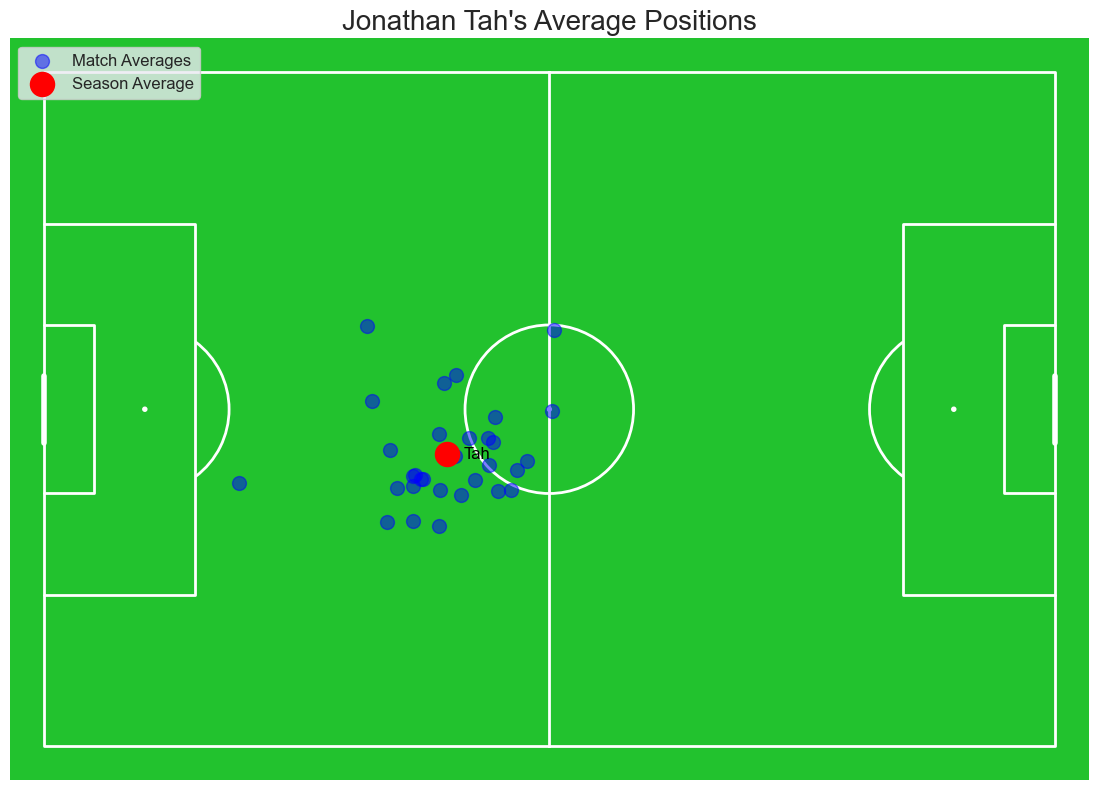

Tah's average position across the season: x=47.84, y=45.33
Number of matches with data: 31


In [127]:
# Filter events for Tah
tah_events = events_df[events_df['player'] == 'Jonathan Tah']

# Calculate average position for each match
tah_positions = tah_events.groupby('match_id').agg({
    'x': 'mean',
    'y': 'mean'
}).reset_index()

# Calculate overall average position
average_x = tah_positions['x'].mean()
average_y = tah_positions['y'].mean()

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22c22e', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))

# Plot average positions for each match
scatter = pitch.scatter(tah_positions['x'], tah_positions['y'], ax=ax, 
                        s=100, color='blue', alpha=0.5, label='Match Averages')

# Plot overall average position
pitch.scatter(average_x, average_y, ax=ax, s=300, color='red', 
              label='Season Average')

# Add labels
ax.text(average_x + 2, average_y, 'Tah', fontsize=12, color='black', 
        ha='left', va='center')

# Add title and legend
ax.set_title("Jonathan Tah's Average Positions", fontsize=20)
ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Tah's average position across the season: x={average_x:.2f}, y={average_y:.2f}")
print(f"Number of matches with data: {len(tah_positions)}")

Jonathan Tah:
  Average position: x=47.84, y=45.33
  Number of matches: 31

Edmond Fayçal Tapsoba:
  Average position: x=48.76, y=30.12
  Number of matches: 27

Odilon Kossonou:
  Average position: x=55.31, y=62.86
  Number of matches: 22

Piero Martín Hincapié Reyna:
  Average position: x=54.68, y=17.31
  Number of matches: 25



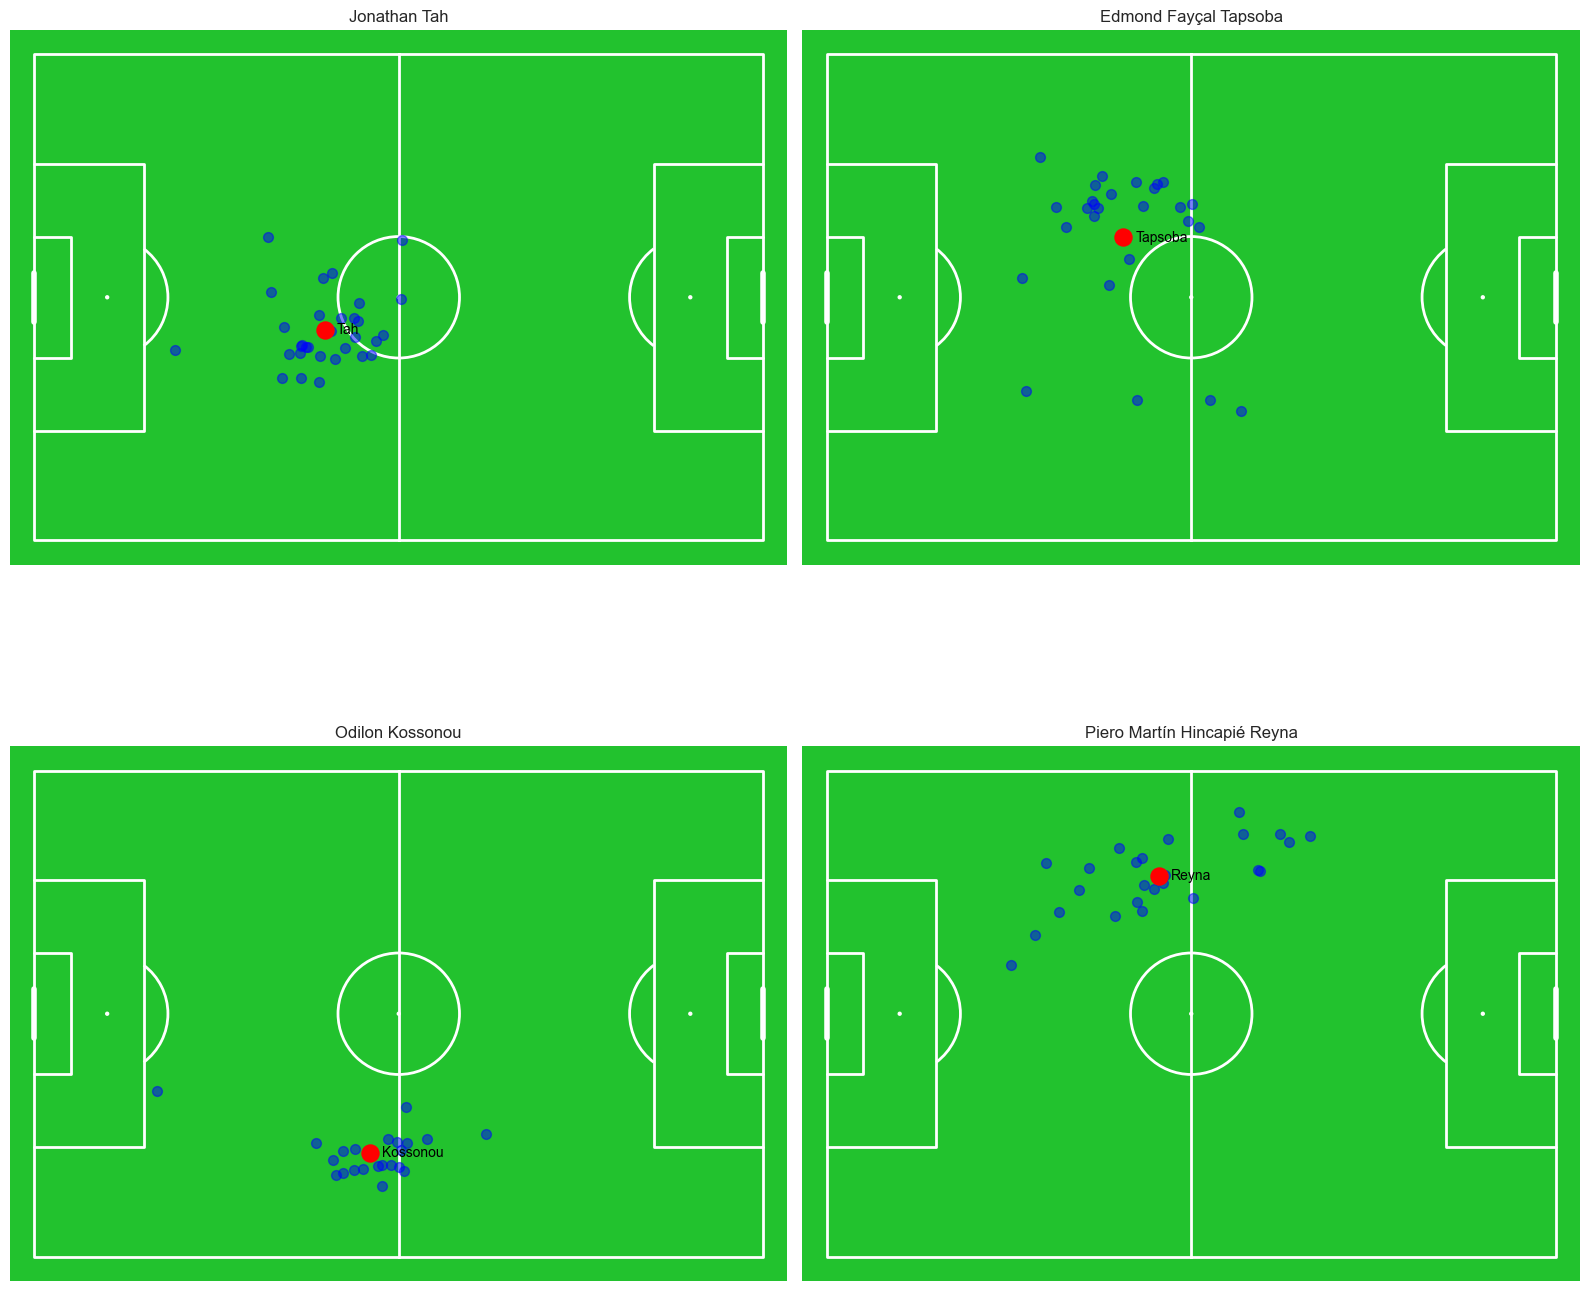

In [128]:
def plot_player_positions(events_df, player_name, ax):
    player_events = events_df[events_df['player'] == player_name]
    player_positions = player_events.groupby('match_id').agg({
        'x': 'mean',
        'y': 'mean'
    }).reset_index()
    
    average_x = player_positions['x'].mean()
    average_y = player_positions['y'].mean()
    
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#22c22e', line_color='white')
    pitch.draw(ax=ax)
    
    scatter = pitch.scatter(player_positions['x'], player_positions['y'], ax=ax, 
                            s=50, color='blue', alpha=0.5)
    pitch.scatter(average_x, average_y, ax=ax, s=150, color='red')
    
    ax.text(average_x + 2, average_y, player_name.split()[-1], fontsize=10, color='black', 
            ha='left', va='center')
    
    ax.set_title(f"{player_name}", fontsize=12)
    
    return average_x, average_y, len(player_positions)

defenders = [
    'Jonathan Tah',
    'Edmond Fayçal Tapsoba',
    'Odilon Kossonou',
    'Piero Martín Hincapié Reyna'
]

fig, axs = plt.subplots(2, 2, figsize=(16, 16))
axs = axs.flatten()

for i, defender in enumerate(defenders):
    avg_x, avg_y, num_matches = plot_player_positions(events_df, defender, axs[i])
    print(f"{defender}:")
    print(f"  Average position: x={avg_x:.2f}, y={avg_y:.2f}")
    print(f"  Number of matches: {num_matches}")
    print()

plt.tight_layout()
plt.show()

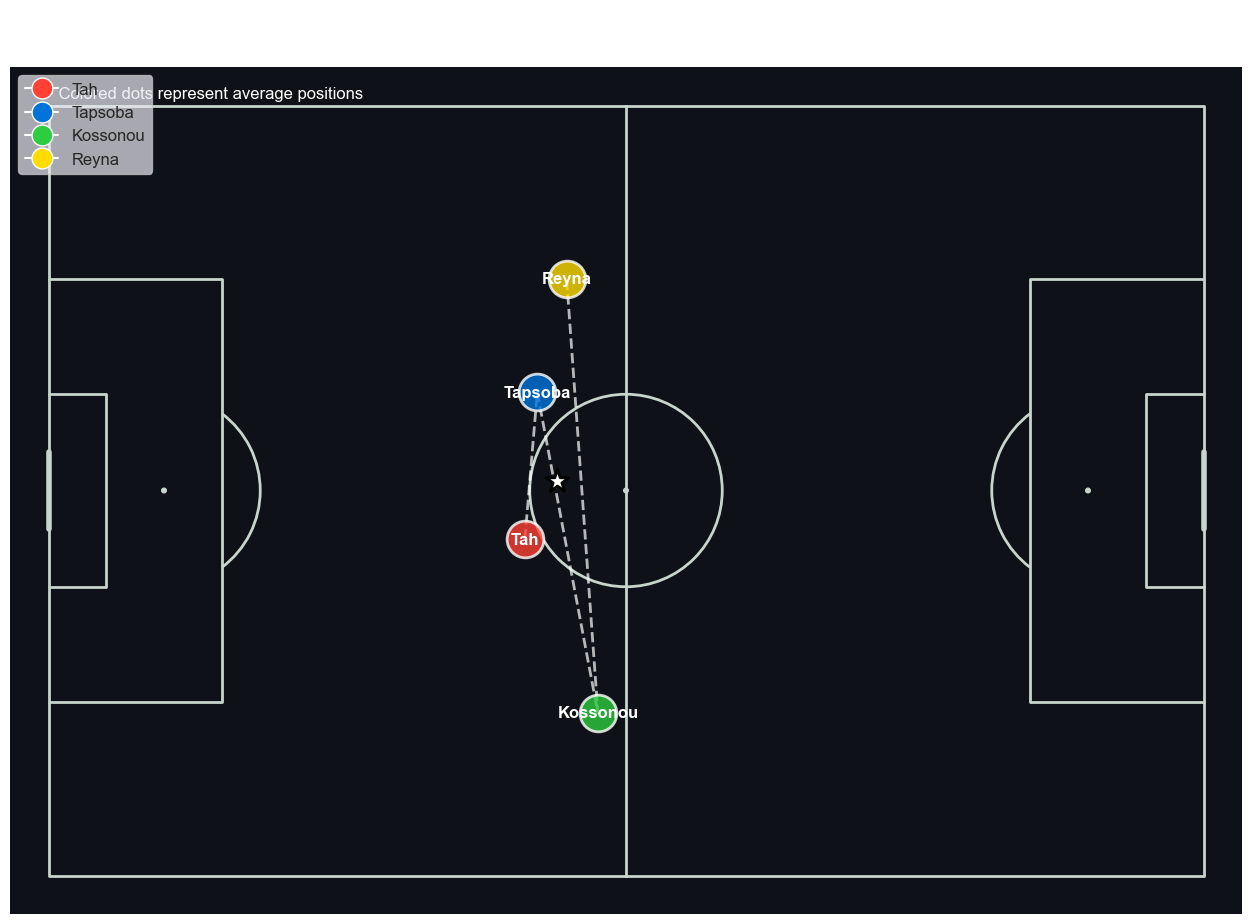

In [129]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import pandas as pd
import numpy as np

def get_player_avg_position(events_df, player_name):
    player_events = events_df[events_df['player'] == player_name]
    avg_position = player_events[['x', 'y']].mean()
    return avg_position['x'], avg_position['y']

defenders = [
    'Jonathan Tah',
    'Edmond Fayçal Tapsoba',
    'Odilon Kossonou',
    'Piero Martín Hincapié Reyna'
]

# Create pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#0E1117', line_color='#c7d5cc', stripe=False)
fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)

# Get average positions
positions = [get_player_avg_position(events_df, defender) for defender in defenders]

# Plot average positions
colors = ['#FF4136', '#0074D9', '#2ECC40', '#FFDC00']
for (x, y), color, name in zip(positions, colors, defenders):
    pitch.scatter(x, y, ax=ax, s=700, color=color, edgecolors='white', linewidths=2, alpha=0.8, zorder=3)
    ax.annotate(name.split()[-1], (x, y), xytext=(0, 0), textcoords='offset points', ha='center', va='center',
                fontsize=12, fontweight='bold', color='white', zorder=4)

# Draw lines connecting the positions
ax.plot([pos[0] for pos in positions], [pos[1] for pos in positions], color='white', linestyle='--', linewidth=2, alpha=0.7, zorder=2)

# Add a midpoint marker
midpoint_x = sum(pos[0] for pos in positions) / len(positions)
midpoint_y = sum(pos[1] for pos in positions) / len(positions)
ax.scatter(midpoint_x, midpoint_y, s=300, color='white', edgecolors='black', linewidths=2, marker='*', zorder=5)

# Add title
ax.set_title("Average Positions of Bayer Leverkusen's Center-Backs", fontsize=24, fontweight='bold', color='white', pad=20)

# Add explanatory text
ax.text(0, -2, "• Colored dots represent average positions", fontsize=12, ha='left', va='top', color='white')
ax.text(0, -6, "• White star represents the midpoint of all positions", fontsize=12, ha='left', va='top', color='white')
ax.text(0, -10, "• Dashed line connects the positions", fontsize=12, ha='left', va='top', color='white')

# Add legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=name.split()[-1],
                              markerfacecolor=color, markersize=15) for name, color in zip(defenders, colors)]
ax.legend(handles=legend_elements, loc='upper left', fontsize=12, framealpha=0.7)

plt.show()

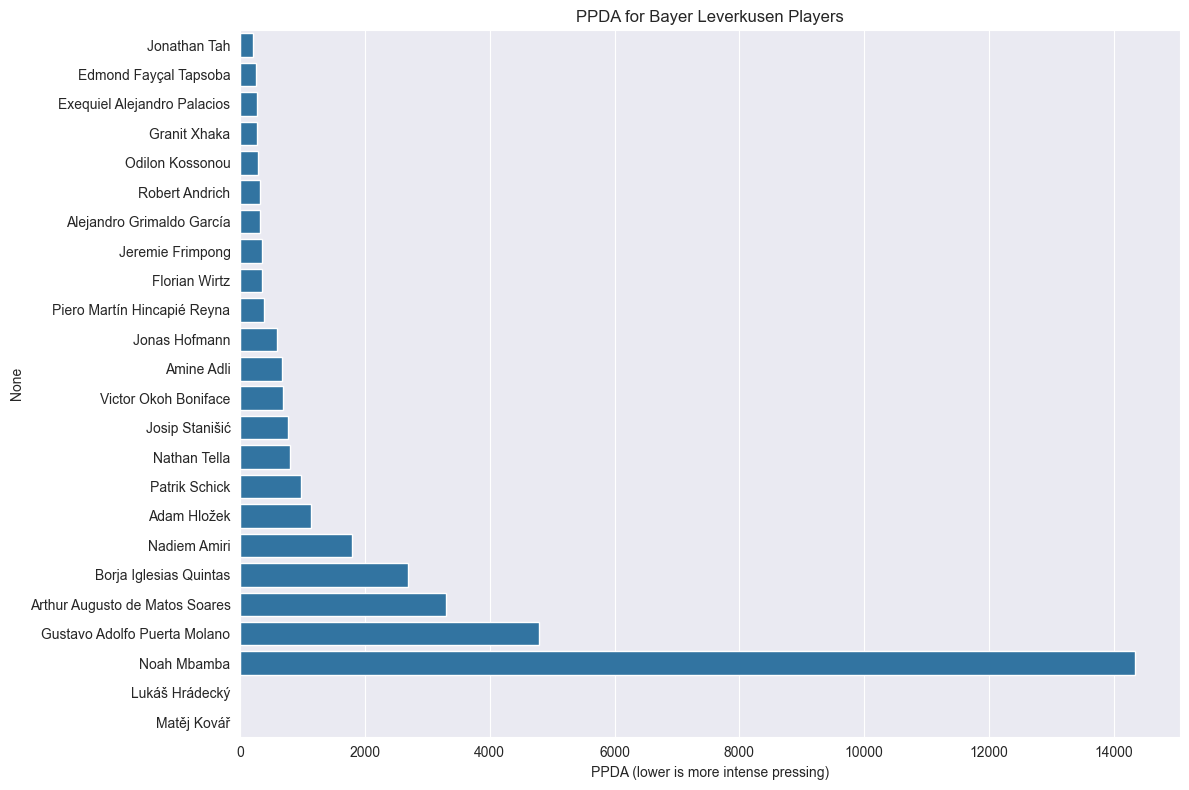

Jonathan Tah                      2.010526e+02
Edmond Fayçal Tapsoba             2.494035e+02
Exequiel Alejandro Palacios       2.682264e+02
Granit Xhaka                      2.706923e+02
Odilon Kossonou                   2.917727e+02
Robert Andrich                    3.124048e+02
Alejandro Grimaldo García         3.260455e+02
Jeremie Frimpong                  3.519000e+02
Florian Wirtz                     3.557381e+02
Piero Martín Hincapié Reyna       3.800286e+02
Jonas Hofmann                     5.956400e+02
Amine Adli                        6.630476e+02
Victor Okoh Boniface              6.831429e+02
Josip Stanišić                    7.735556e+02
Nathan Tella                      7.952500e+02
Patrik Schick                     9.692667e+02
Adam Hložek                       1.130462e+03
Nadiem Amiri                      1.788333e+03
Borja Iglesias Quintas            2.682500e+03
Arthur Augusto de Matos Soares    3.307000e+03
Gustavo Adolfo Puerta Molano      4.782000e+03
Noah Mbamba  

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming events_df is your dataframe with all event data

def calculate_player_ppda(events_df, team_name='Bayer Leverkusen'):
    # Filter for Bayer Leverkusen players
    bayer_players = events_df[events_df['team'] == team_name]['player'].unique()
    
    player_ppda = {}
    for player in bayer_players:
        # Get player's time on field (you might need to adjust this based on your data structure)
        player_minutes = events_df[(events_df['player'] == player) & (events_df['type'] == 'Substitution')]['minute'].max()
        if pd.isna(player_minutes):
            player_minutes = 90  # Assume full game if no substitution
        
        # Count opponent passes while player was on field
        opponent_passes = events_df[(events_df['team'] != team_name) & 
                                    (events_df['type'] == 'Pass') & 
                                    (events_df['minute'] <= player_minutes)].shape[0]
        
        # Count player's defensive actions
        defensive_actions = events_df[(events_df['player'] == player) & 
                                      (events_df['type'].isin(['Interception', 'Tackle', 'Foul Committed', 'Challenge']))].shape[0]
        
        if defensive_actions > 0:
            ppda = opponent_passes / defensive_actions
        else:
            ppda = float('inf')  # or some large number to indicate no defensive actions
        
        player_ppda[player] = ppda
    
    return pd.Series(player_ppda).sort_values()

# Calculate PPDA for Bayer Leverkusen players
bayer_ppda = calculate_player_ppda(events_df)

# Visualize the results
plt.figure(figsize=(12, 8))
sns.barplot(x=bayer_ppda.values, y=bayer_ppda.index)
plt.title('PPDA for Bayer Leverkusen Players')
plt.xlabel('PPDA (lower is more intense pressing)')
plt.tight_layout()
plt.show()

# Print the values
print(bayer_ppda)

In [131]:
# Filter passes from Xhaka to Wirtz
xhaka_to_wirtz = events_df[
    (events_df['player'] == 'Granit Xhaka') & 
    (events_df['pass_recipient'] == 'Florian Wirtz') &
    (events_df['type'] == 'Pass')
]

# Calculate pass success rate
success_rate = xhaka_to_wirtz['pass_outcome'].isna().mean()
print(f"Pass success rate from Xhaka to Wirtz: {success_rate:.2%}")

# Count total passes
total_passes = len(xhaka_to_wirtz)
print(f"Total passes from Xhaka to Wirtz: {total_passes}")

Pass success rate from Xhaka to Wirtz: 88.80%
Total passes from Xhaka to Wirtz: 393


In [132]:
# Filter all passes from Xhaka to Wirtz
xhaka_to_wirtz = events_df[
    (events_df['player'] == 'Granit Xhaka') & 
    (events_df['pass_recipient'] == 'Florian Wirtz') &
    (events_df['type'] == 'Pass')
]

# Identify key passes (including assists)
key_passes = xhaka_to_wirtz[(xhaka_to_wirtz['pass_shot_assist'] == True) | (xhaka_to_wirtz['pass_goal_assist'] == True)]

print(f"Total passes from Xhaka to Wirtz: {len(xhaka_to_wirtz)}")
print(f"Key passes from Xhaka to Wirtz (including assists): {len(key_passes)}")

Total passes from Xhaka to Wirtz: 393
Key passes from Xhaka to Wirtz (including assists): 9


In [133]:
print(xhaka_to_wirtz.head())

     50_50 bad_behaviour_card ball_receipt_outcome ball_recovery_offensive  \
1105   NaN                NaN                  NaN                     NaN   
1127   NaN                NaN                  NaN                     NaN   
1202   NaN                NaN                  NaN                     NaN   
1218   NaN                NaN                  NaN                     NaN   
1389   NaN                NaN                  NaN                     NaN   

     ball_recovery_recovery_failure block_deflection block_offensive  \
1105                            NaN              NaN             NaN   
1127                            NaN              NaN             NaN   
1202                            NaN              NaN             NaN   
1218                            NaN              NaN             NaN   
1389                            NaN              NaN             NaN   

     block_save_block carry_end_location clearance_aerial_won  ... team_id  \
1105              Na

In [134]:
if len(xhaka_to_wirtz) > 0:
    success_rate = (successful_passes / len(xhaka_to_wirtz)) * 100
else:
    success_rate = 0

In [135]:
   print(len(xhaka_to_wirtz))
   print(xhaka_to_wirtz['pass_outcome'].isna().sum())

393
349


In [136]:
success_rate = (xhaka_to_wirtz['pass_outcome'].isna().sum() / len(xhaka_to_wirtz)) * 100

In [137]:
total_passes = len(xhaka_to_wirtz)
successful_passes = xhaka_to_wirtz['pass_outcome'].isna().sum()

if total_passes > 0:
    success_rate = (successful_passes / total_passes) * 100
else:
    success_rate = 0

print(f"Success rate: {success_rate:.2f}%")

Success rate: 88.80%


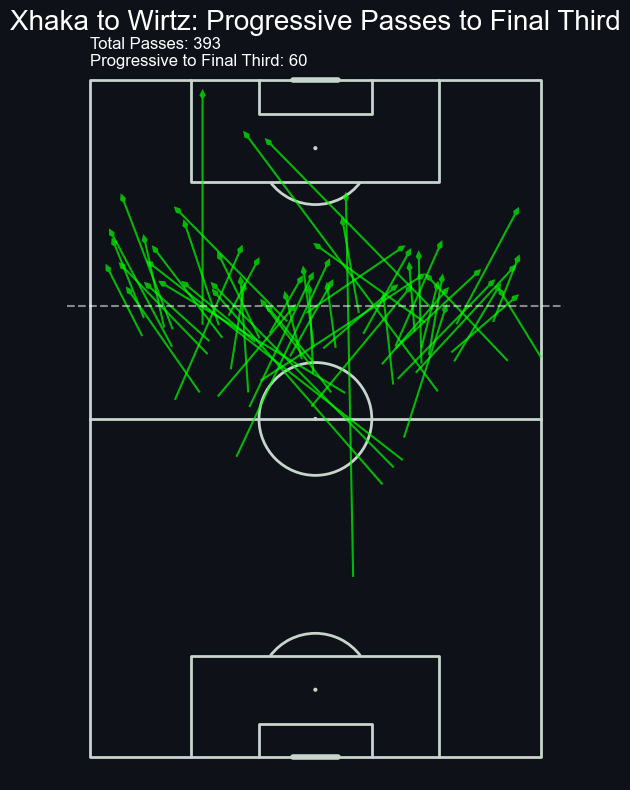

In [138]:
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch

# Filter progressive passes to the final third
progressive_final_third = xhaka_to_wirtz[
    (xhaka_to_wirtz['pass_end_x'] - xhaka_to_wirtz['x'] > 10) &  # Progressive
    (xhaka_to_wirtz['x'] < 80) &  # Starting before final third
    (xhaka_to_wirtz['pass_end_x'] >= 80)  # Ending in final third
]

# Set up the pitch
pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#0E1117', line_color='#c7d5cc', stripe=False)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 8))
fig.set_facecolor('#0E1117')

# Draw the pitch
pitch.draw(ax=ax)

# Plot progressive passes to final third
pitch.arrows(progressive_final_third['x'], progressive_final_third['y'],
             progressive_final_third['pass_end_x'], progressive_final_third['pass_end_y'],
             ax=ax, color='#00FF00', width=1.5, headwidth=3, headlength=3, 
             alpha=0.7, zorder=2)

# Draw the final third line
ax.axhline(80, color='white', linestyle='--', alpha=0.5)

# Set title
ax.set_title("Xhaka to Wirtz: Progressive Passes to Final Third", fontsize=20, color='white', pad=20)

# Add statistics
stats_text = (f"Total Passes: {len(xhaka_to_wirtz)}\n"
              f"Progressive to Final Third: {len(progressive_final_third)}")
ax.text(0, 122, stats_text, color='white', fontsize=12, ha='left', va='bottom')

# Show the plot
plt.tight_layout()
plt.show()

In [199]:
# Display a sample of passing events for Bayer Leverkusen
team_passes_sample = events_df[(events_df['team'] == 'Bayer Leverkusen') & (events_df['type'] == 'Pass')].head(10)
print(team_passes_sample[['player', 'pass_recipient', 'location', 'pass_end_location']])

                    player         pass_recipient      location  \
213           Nathan Tella         Lukáš Hrádecký  [33.3, 43.2]   
214         Lukáš Hrádecký  Edmond Fayçal Tapsoba   [8.5, 33.8]   
215  Edmond Fayçal Tapsoba         Robert Andrich  [22.3, 19.5]   
216         Robert Andrich  Edmond Fayçal Tapsoba  [38.1, 19.5]   
217  Edmond Fayçal Tapsoba           Jonathan Tah  [48.1, 28.6]   
218           Jonathan Tah        Odilon Kossonou  [54.5, 54.3]   
219        Odilon Kossonou           Jonathan Tah  [56.6, 66.6]   
220           Jonathan Tah           Granit Xhaka  [48.6, 55.6]   
221           Granit Xhaka           Jonathan Tah  [57.1, 20.8]   
222           Jonathan Tah           Nathan Tella  [61.8, 54.3]   

    pass_end_location  
213       [8.5, 33.8]  
214      [15.1, 21.5]  
215      [38.1, 19.5]  
216      [29.9, 19.5]  
217      [48.6, 49.7]  
218      [56.4, 66.1]  
219      [49.4, 56.4]  
220      [51.2, 25.2]  
221      [56.4, 44.2]  
222      [82.7, 75.1] 

In [203]:
# Print the first few rows of the filtered passes
print(team_passes[['player', 'pass_recipient', 'location', 'pass_end_location']].head())

# Print the number of passes
print(f"Number of passes: {len(team_passes)}")

# Print unique players
print("Unique players:")
print(team_passes['player'].unique())

                    player         pass_recipient      location  \
213           Nathan Tella         Lukáš Hrádecký  [33.3, 43.2]   
214         Lukáš Hrádecký  Edmond Fayçal Tapsoba   [8.5, 33.8]   
215  Edmond Fayçal Tapsoba         Robert Andrich  [22.3, 19.5]   
216         Robert Andrich  Edmond Fayçal Tapsoba  [38.1, 19.5]   
217  Edmond Fayçal Tapsoba           Jonathan Tah  [48.1, 28.6]   

    pass_end_location  
213       [8.5, 33.8]  
214      [15.1, 21.5]  
215      [38.1, 19.5]  
216      [29.9, 19.5]  
217      [48.6, 49.7]  
Number of passes: 24244
Unique players:
['Nathan Tella' 'Lukáš Hrádecký' 'Edmond Fayçal Tapsoba' 'Robert Andrich'
 'Jonathan Tah' 'Odilon Kossonou' 'Granit Xhaka' 'Victor Okoh Boniface'
 'Jonas Hofmann' 'Piero Martín Hincapié Reyna' 'Amine Adli'
 'Florian Wirtz' 'Jeremie Frimpong' 'Patrik Schick'
 'Alejandro Grimaldo García' 'Exequiel Alejandro Palacios'
 'Borja Iglesias Quintas' 'Adam Hložek' 'Arthur Augusto de Matos Soares'
 'Gustavo Adolfo Puerta

In [204]:
# Print player positions
print("Player positions:")
for player, pos in player_positions.items():
    print(f"{player}: {pos}")

Player positions:
('Adam Hložek', 0): 72.55483870967743
('Adam Hložek', 1): 37.73354838709677
('Alejandro Grimaldo García', 0): 73.30490968040759
('Alejandro Grimaldo García', 1): 16.092218619731355
('Amine Adli', 0): 78.83935483870968
('Amine Adli', 1): 27.061505376344083
('Arthur Augusto de Matos Soares', 0): 72.95
('Arthur Augusto de Matos Soares', 1): 25.496296296296297
('Borja Iglesias Quintas', 0): 86.64155844155843
('Borja Iglesias Quintas', 1): 34.65974025974025
('Edmond Fayçal Tapsoba', 0): 51.86623843782116
('Edmond Fayçal Tapsoba', 1): 29.790596094552928
('Exequiel Alejandro Palacios', 0): 63.1446587537092
('Exequiel Alejandro Palacios', 1): 37.99475766567755
('Florian Wirtz', 0): 78.72683324280281
('Florian Wirtz', 1): 34.47718631178707
('Granit Xhaka', 0): 64.09518035768414
('Granit Xhaka', 1): 38.586207941800545
('Gustavo Adolfo Puerta Molano', 0): 62.46279069767441
('Gustavo Adolfo Puerta Molano', 1): 36.14186046511628
('Jeremie Frimpong', 0): 80.56483622350673
('Jeremie

In [205]:
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print("Edges:")
for edge in G.edges(data=True):
    print(edge)

Number of nodes: 25
Number of edges: 478
Edges:
('Nathan Tella', 'Lukáš Hrádecký', {'weight': 6})
('Nathan Tella', 'Victor Okoh Boniface', {'weight': 6})
('Nathan Tella', 'Granit Xhaka', {'weight': 41})
('Nathan Tella', 'Piero Martín Hincapié Reyna', {'weight': 14})
('Nathan Tella', 'Odilon Kossonou', {'weight': 31})
('Nathan Tella', 'Jonas Hofmann', {'weight': 27})
('Nathan Tella', nan, {'weight': 22})
('Nathan Tella', 'Amine Adli', {'weight': 11})
('Nathan Tella', 'Florian Wirtz', {'weight': 43})
('Nathan Tella', 'Borja Iglesias Quintas', {'weight': 6})
('Nathan Tella', 'Alejandro Grimaldo García', {'weight': 17})
('Nathan Tella', 'Robert Andrich', {'weight': 13})
('Nathan Tella', 'Jonathan Tah', {'weight': 8})
('Nathan Tella', 'Patrik Schick', {'weight': 19})
('Nathan Tella', 'Adam Hložek', {'weight': 9})
('Nathan Tella', 'Exequiel Alejandro Palacios', {'weight': 12})
('Nathan Tella', 'Josip Stanišić', {'weight': 44})
('Nathan Tella', 'Arthur Augusto de Matos Soares', {'weight': 1})

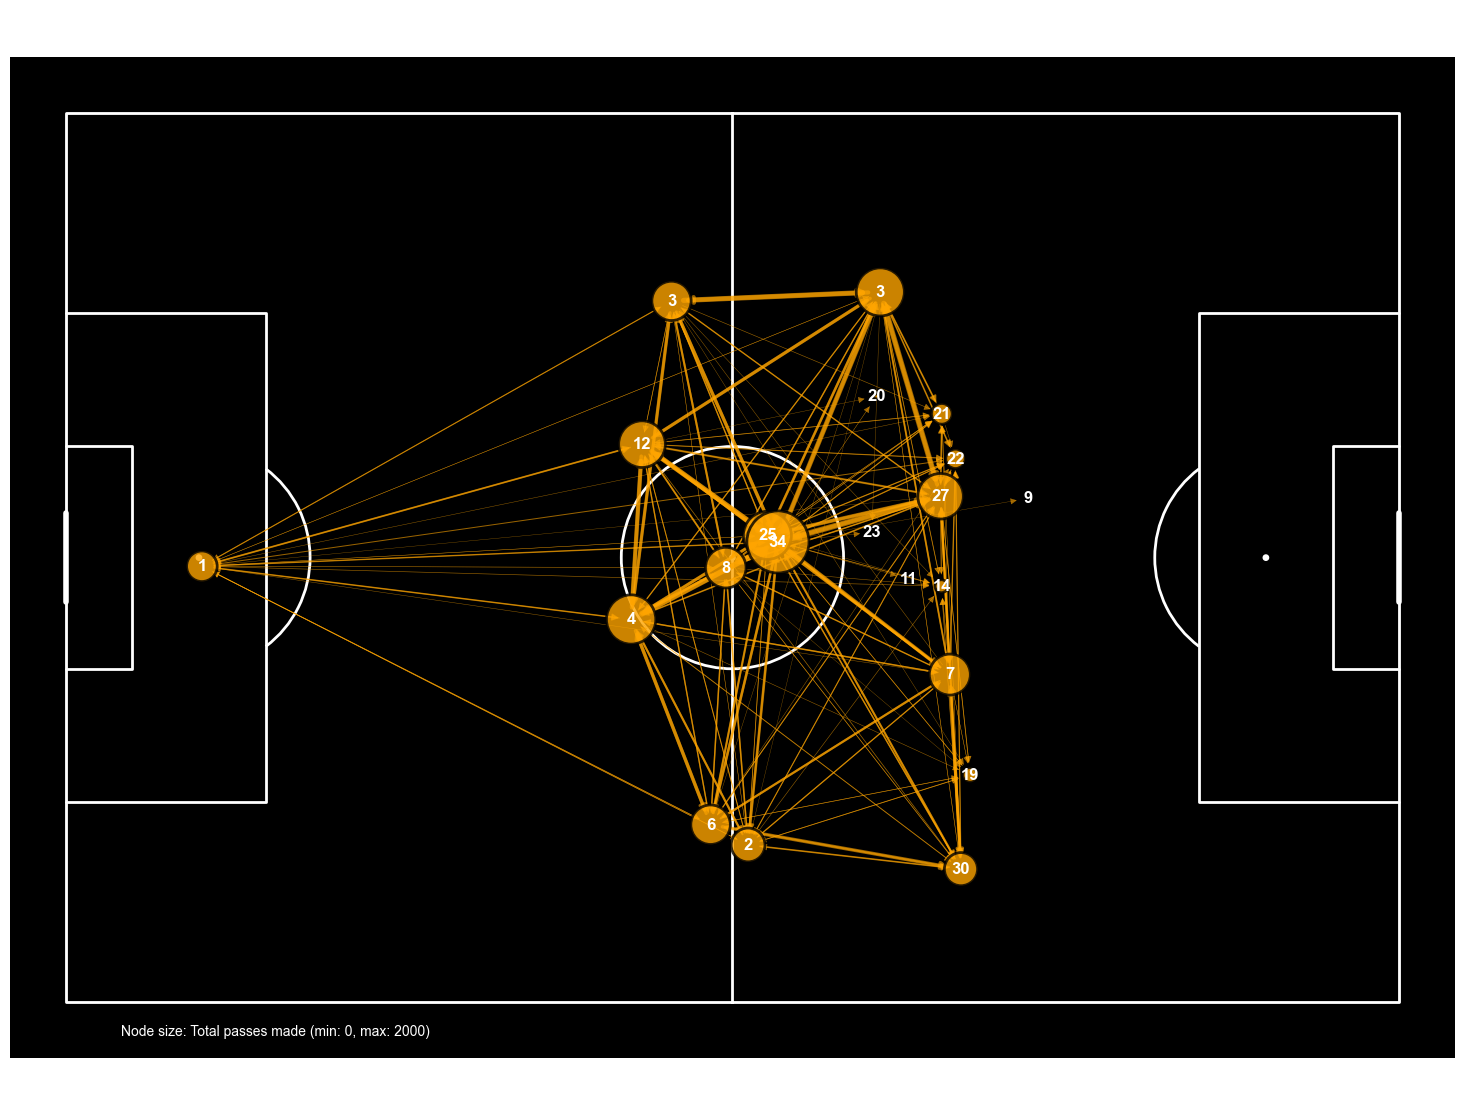


Top 5 passers:
Granit Xhaka: 3280 passes
Jonathan Tah: 2066 passes
Alejandro Grimaldo García: 1969 passes
Exequiel Alejandro Palacios: 1960 passes
Edmond Fayçal Tapsoba: 1854 passes

Top 5 pass combinations:
Exequiel Alejandro Palacios to Granit Xhaka: 467 passes
Granit Xhaka to Florian Wirtz: 393 passes
Jonathan Tah to Granit Xhaka: 385 passes
Alejandro Grimaldo García to Florian Wirtz: 370 passes
Granit Xhaka to Exequiel Alejandro Palacios: 356 passes


In [235]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mplsoccer import Pitch

# Mapping of player names to kit numbers for the 2023-2024 season
kit_numbers = {
    'Lukáš Hrádecký': 1,
    'Nathan Tella': 19,
    'Edmond Fayçal Tapsoba': 12,
    'Robert Andrich': 8,
    'Jonathan Tah': 4,
    'Odilon Kossonou': 6,
    'Granit Xhaka': 34,
    'Victor Okoh Boniface': 22,
    'Jonas Hofmann': 7,
    'Piero Martín Hincapié Reyna': 3,
    'Amine Adli': 21,
    'Florian Wirtz': 27,
    'Jeremie Frimpong': 30,
    'Patrik Schick': 14,
    'Alejandro Grimaldo García': 3,
    'Exequiel Alejandro Palacios': 25,
    'Borja Iglesias Quintas': 9,
    'Adam Hložek': 23,
    'Arthur Augusto de Matos Soares': 20,
    'Gustavo Adolfo Puerta Molano': 18,
    'Josip Stanišić': 2,
    'Noah Mbamba': 24,
    'Nadiem Amiri': 11,
    'Matěj Kovář': 36
}

# Filter passes for Bayer Leverkusen
team_name = 'Bayer Leverkusen'
team_passes = events_df[(events_df['team'] == team_name) & (events_df['type'] == 'Pass')]

# Create a DataFrame with pass connections
pass_connections = team_passes.groupby(['player', 'pass_recipient']).size().reset_index(name='pass_count')

# Create a directed graph
G = nx.DiGraph()

# Add nodes and edges (filter for significant connections)
min_passes = 20  # Increase the threshold to reduce clutter
for _, row in pass_connections.iterrows():
    if row['pass_count'] >= min_passes:
        G.add_edge(row['player'], row['pass_recipient'], weight=row['pass_count'])

# Calculate node sizes based on total passes made
node_sizes = dict(G.out_degree(weight='weight'))
max_passes = max(node_sizes.values())
node_sizes = {player: (count / max_passes) * 2000 for player, count in node_sizes.items()}  # Adjust size scaling

# Calculate node positions based on average player locations
player_positions = team_passes.groupby('player')['location'].apply(lambda x: np.mean(x.tolist(), axis=0)).to_dict()
pos = {player: (loc[0], 80 - loc[1]) for player, loc in player_positions.items() if player in G.nodes()}

# Create the plot
pitch = Pitch(pitch_type='statsbomb', pitch_color='black', line_color='white', stripe=False)
fig, ax = plt.subplots(figsize=(16, 11), constrained_layout=True)
pitch.draw(ax=ax)

# Draw edges
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_edge_weight = max(edge_weights)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='orange', width=[w / max_edge_weight * 5 for w in edge_weights], alpha=0.6)

# Draw nodes
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=[node_sizes[node] for node in G.nodes()], node_color='orange', edgecolors='black', linewidths=2, alpha=0.8)

# Use kit numbers for labels
labels = {node: kit_numbers.get(node, '') for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=12, font_color='white', font_weight='bold')

# Customize the plot
ax.set_title(f"{team_name} Passing Network", fontsize=20, color='white', pad=20)
ax.set_xlim(-5, 125)
ax.set_ylim(-5, 85)

# Add a pitch outline
pitch_outline = plt.Rectangle((0, 0), 120, 80, fill=False, color='white')
ax.add_patch(pitch_outline)

# Add a legend
plt.text(5, -3, f"Node size: Total passes made (min: {min(node_sizes.values()):.0f}, max: {max(node_sizes.values()):.0f})", color='white')
plt.text(5, -7, f"Edge thickness: Passes between players (min: {min_passes}, max: {max_edge_weight})", color='white')

plt.tight_layout()
plt.show()

# Print top passers and pass combinations
top_passers = sorted(node_sizes.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 passers:")
for player, size in top_passers:
    print(f"{player}: {G.out_degree(player, weight='weight')} passes")

top_combinations = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
print("\nTop 5 pass combinations:")
for passer, receiver, data in top_combinations:
    print(f"{passer} to {receiver}: {data['weight']} passes")

In [231]:
# Filter the DataFrame for Bayer Leverkusen
team_name = 'Bayer Leverkusen'
bayer_players = events_df[events_df['team'] == team_name]['player'].unique()

# Print the names of Bayer Leverkusen players
print("Bayer Leverkusen Players:")
for player in bayer_players:
    print(player)

Bayer Leverkusen Players:
nan
Nathan Tella
Lukáš Hrádecký
Edmond Fayçal Tapsoba
Robert Andrich
Jonathan Tah
Odilon Kossonou
Granit Xhaka
Victor Okoh Boniface
Jonas Hofmann
Piero Martín Hincapié Reyna
Amine Adli
Florian Wirtz
Jeremie Frimpong
Patrik Schick
Alejandro Grimaldo García
Exequiel Alejandro Palacios
Borja Iglesias Quintas
Adam Hložek
Arthur Augusto de Matos Soares
Gustavo Adolfo Puerta Molano
Josip Stanišić
Noah Mbamba
Nadiem Amiri
Matěj Kovář


In [237]:
import pandas as pd

# Assuming events_df is your DataFrame
# Filter for shot events
shots_df = events_df[events_df['type'] == 'Shot']

# Calculate total goals for each player
goals_df = shots_df[shots_df['shot_outcome'] == 'Goal'].groupby('player').size().reset_index(name='Goals')

# Calculate total xG for each player
xg_df = shots_df.groupby('player')['shot_statsbomb_xg'].sum().reset_index(name='xG')

# Merge the two DataFrames
player_stats_df = pd.merge(goals_df, xg_df, on='player')

# Display the DataFrame
print(player_stats_df)

                         player  Goals         xG
0                   Adam Hložek      2   3.010453
1     Alejandro Grimaldo García     10   5.209482
2                    Amine Adli      4   3.085179
3                   Anton Stach      1   0.051356
4                 Chris Führich      2   1.096848
5          Daniel Olmo Carvajal      1   0.129345
6                   Deniz Undav      1   0.629300
7                  Dominik Kohr      1   0.298051
8              Eren Sami Dinkçi      1   0.080330
9   Exequiel Alejandro Palacios      4   2.694172
10                Florian Wirtz     11   8.470831
11                 Granit Xhaka      3   1.570920
12                   Harry Kane      1   0.889875
13                 Hugo Ekitike      1   0.265957
14            Ikoma Loïs Openda      2   1.358279
15             Jeremie Frimpong      9   8.719662
16                Jonas Hofmann      4   5.709160
17                 Jonathan Tah      4   1.805863
18               Josip Stanišić      3   0.789744


In [241]:
import pandas as pd

# Assuming events_df is your DataFrame
# Filter for shot events
shots_df = events_df[events_df['type'] == 'Shot']

# Calculate total goals for each match
goals_df = shots_df[shots_df['shot_outcome'] == 'Goal'].groupby('match_id').size().reset_index(name='Goals')

# Calculate total xG for each match
xg_df = shots_df.groupby('match_id')['shot_statsbomb_xg'].sum().reset_index(name='xG')

# Merge the two DataFrames
match_stats_df = pd.merge(goals_df, xg_df, on='match_id')

# Display the DataFrame
print(match_stats_df)

    match_id  Goals        xG
0    3895052      5  3.245474
1    3895060      3  3.519135
2    3895067      6  3.883844
3    3895074      4  4.427581
4    3895086      5  4.035160
5    3895095      2  1.228930
6    3895107      3  4.132633
7    3895113      3  3.161021
8    3895121      2  2.193617
9    3895134      5  2.757987
10   3895139      4  1.922119
11   3895153      2  1.277006
12   3895158      2  2.952457
13   3895167      2  3.935919
14   3895180      3  2.938153
15   3895182      4  3.688477
16   3895194      1  1.891401
17   3895202      5  2.967367
18   3895220      2  2.722812
19   3895232      3  1.651964
20   3895244      3  2.276324
21   3895250      3  2.253890
22   3895258      2  1.979784
23   3895266      2  2.012734
24   3895275      5  3.526796
25   3895286      3  3.419201
26   3895292      1  3.108626
27   3895302      5  3.687976
28   3895309      2  1.918948
29   3895320      4  3.451966
30   3895333      6  4.027343
31   3895340      5  4.615762
32   38953

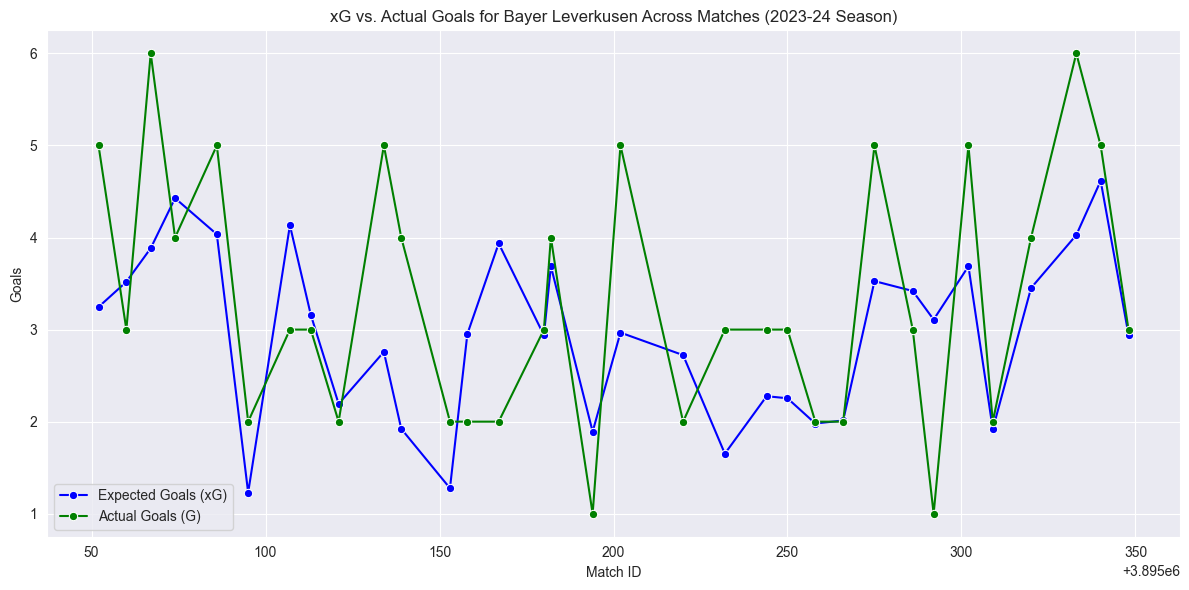

In [242]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=match_stats_df, x='match_id', y='xG', marker='o', label='Expected Goals (xG)', color='blue')
sns.lineplot(data=match_stats_df, x='match_id', y='Goals', marker='o', label='Actual Goals (G)', color='green')

# Set plot labels and title
plt.xlabel('Match ID')
plt.ylabel('Goals')
plt.title('xG vs. Actual Goals for Bayer Leverkusen Across Matches (2023-24 Season)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

In [243]:
import pandas as pd

# Assuming events_df is your DataFrame
# Extract unique match IDs and opponents
unique_matches = events_df[['match_id', 'team']].drop_duplicates()

# Display the unique match IDs and opponents
print(unique_matches)

    match_id                      team
0    3895302          Bayer Leverkusen
1    3895302             Werder Bremen
2    3895292              Union Berlin
3    3895292          Bayer Leverkusen
4    3895333       Eintracht Frankfurt
5    3895333          Bayer Leverkusen
6    3895340                    Bochum
7    3895340          Bayer Leverkusen
8    3895348          Bayer Leverkusen
9    3895348                  Augsburg
10   3895286          Bayer Leverkusen
11   3895286                Hoffenheim
12   3895220              Darmstadt 98
13   3895220          Bayer Leverkusen
14   3895250          Bayer Leverkusen
15   3895250              FSV Mainz 05
16   3895266          Bayer Leverkusen
17   3895266                 Wolfsburg
18   3895275                  Freiburg
19   3895275          Bayer Leverkusen
20   3895180          Bayer Leverkusen
21   3895180       Eintracht Frankfurt
22   3895134                Hoffenheim
23   3895134          Bayer Leverkusen
24   3895121          Bay

In [250]:
# Group by match_id to see all opponents
opponents_per_match = unique_matches.groupby('match_id')['team'].unique().reset_index()

# Display the DataFrame
print(opponents_per_match)

    match_id                                          team
0    3895052                [Bayer Leverkusen, RB Leipzig]
1    3895060  [Borussia Mönchengladbach, Bayer Leverkusen]
2    3895067              [Bayer Leverkusen, Darmstadt 98]
3    3895074             [Bayern Munich, Bayer Leverkusen]
4    3895086             [Bayer Leverkusen, FC Heidenheim]
5    3895095              [FSV Mainz 05, Bayer Leverkusen]
6    3895107                   [Bayer Leverkusen, FC Köln]
7    3895113                 [Wolfsburg, Bayer Leverkusen]
8    3895121                  [Bayer Leverkusen, Freiburg]
9    3895134                [Hoffenheim, Bayer Leverkusen]
10   3895139              [Bayer Leverkusen, Union Berlin]
11   3895153             [Werder Bremen, Bayer Leverkusen]
12   3895158         [Bayer Leverkusen, Borussia Dortmund]
13   3895167             [VfB Stuttgart, Bayer Leverkusen]
14   3895180       [Bayer Leverkusen, Eintracht Frankfurt]
15   3895182                    [Bayer Leverkusen, Bochu

In [260]:
import pandas as pd

# Assuming events_df is your DataFrame
# Filter for shot events
shots_df = events_df[events_df['type'] == 'Shot']

# Calculate total goals for each match
goals_df = shots_df[shots_df['shot_outcome'] == 'Goal'].groupby('match_id').size().reset_index(name='Goals')

# Calculate total xG for each match
xg_df = shots_df.groupby('match_id')['shot_statsbomb_xg'].sum().reset_index(name='xG')

# Merge the two DataFrames
match_stats_df = pd.merge(goals_df, xg_df, on='match_id')

# Display the DataFrame
print(match_stats_df)

    match_id  Goals        xG
0    3895052      5  3.245474
1    3895060      3  3.519135
2    3895067      6  3.883844
3    3895074      4  4.427581
4    3895086      5  4.035160
5    3895095      2  1.228930
6    3895107      3  4.132633
7    3895113      3  3.161021
8    3895121      2  2.193617
9    3895134      5  2.757987
10   3895139      4  1.922119
11   3895153      2  1.277006
12   3895158      2  2.952457
13   3895167      2  3.935919
14   3895180      3  2.938153
15   3895182      4  3.688477
16   3895194      1  1.891401
17   3895202      5  2.967367
18   3895220      2  2.722812
19   3895232      3  1.651964
20   3895244      3  2.276324
21   3895250      3  2.253890
22   3895258      2  1.979784
23   3895266      2  2.012734
24   3895275      5  3.526796
25   3895286      3  3.419201
26   3895292      1  3.108626
27   3895302      5  3.687976
28   3895309      2  1.918948
29   3895320      4  3.451966
30   3895333      6  4.027343
31   3895340      5  4.615762
32   38953

In [263]:
import pandas as pd

# Assuming events_df is your DataFrame
# Filter for shot events
shots_df = events_df[events_df['type'] == 'Shot']

# Calculate total goals for each match
goals_df = shots_df[shots_df['shot_outcome'] == 'Goal'].groupby('match_id').size().reset_index(name='Goals')

# Calculate total xG for each match
xg_df = shots_df.groupby('match_id')['shot_statsbomb_xg'].sum().reset_index(name='xG')

# Merge the two DataFrames
match_stats_df = pd.merge(goals_df, xg_df, on='match_id')

# Sort by match_id to ensure correct order
match_stats_df = match_stats_df.sort_values('match_id').reset_index(drop=True)

# Create a new column for match number
match_stats_df['Match Number'] = match_stats_df.index + 1

# Display the DataFrame
print(match_stats_df)

    match_id  Goals        xG  Match Number
0    3895052      5  3.245474             1
1    3895060      3  3.519135             2
2    3895067      6  3.883844             3
3    3895074      4  4.427581             4
4    3895086      5  4.035160             5
5    3895095      2  1.228930             6
6    3895107      3  4.132633             7
7    3895113      3  3.161021             8
8    3895121      2  2.193617             9
9    3895134      5  2.757987            10
10   3895139      4  1.922119            11
11   3895153      2  1.277006            12
12   3895158      2  2.952457            13
13   3895167      2  3.935919            14
14   3895180      3  2.938153            15
15   3895182      4  3.688477            16
16   3895194      1  1.891401            17
17   3895202      5  2.967367            18
18   3895220      2  2.722812            19
19   3895232      3  1.651964            20
20   3895244      3  2.276324            21
21   3895250      3  2.253890   

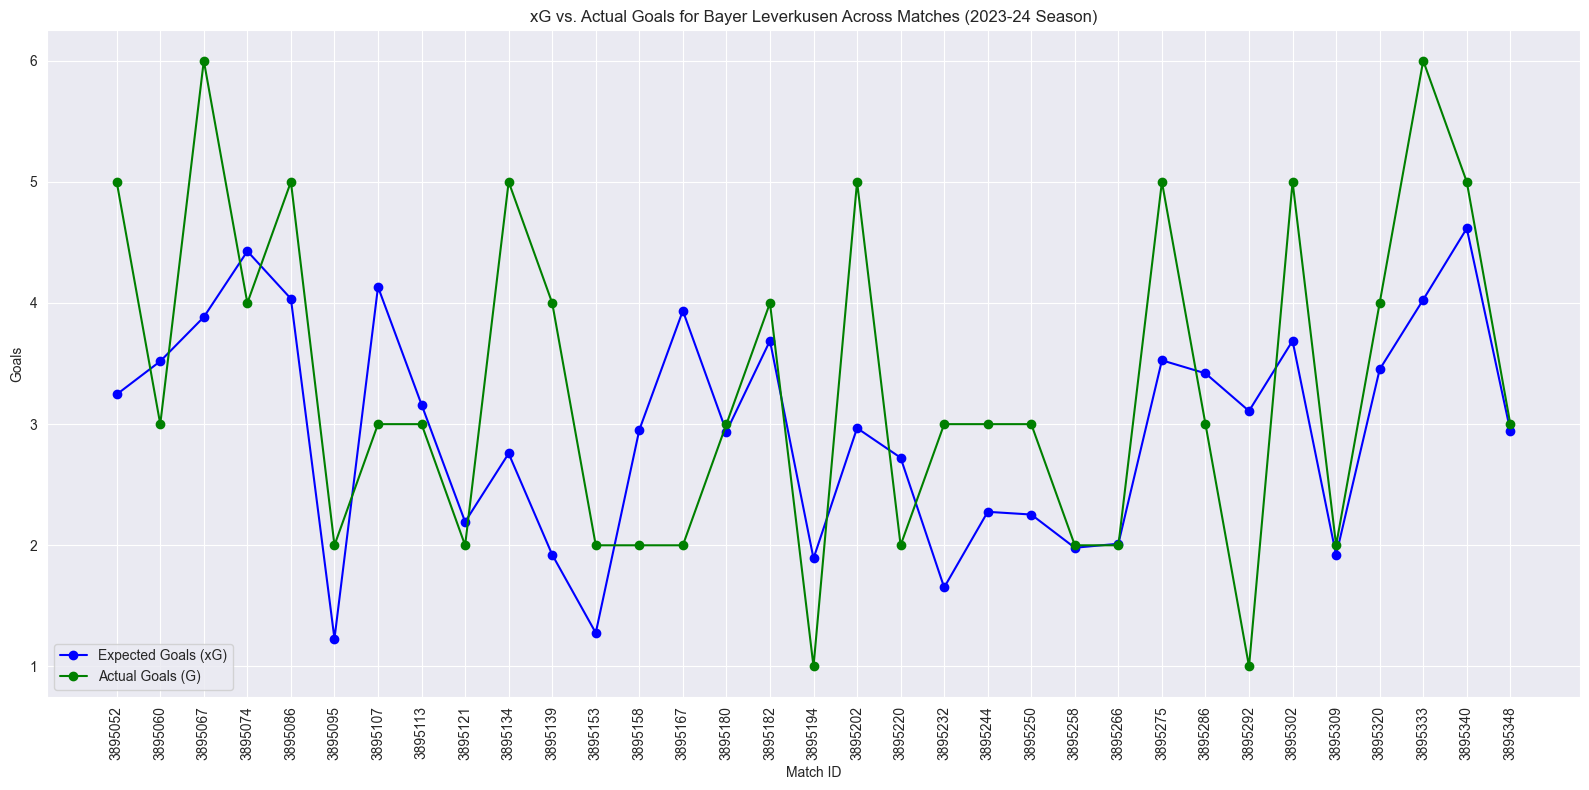

    match_id  Goals        xG
0    3895052      5  3.245474
1    3895060      3  3.519135
2    3895067      6  3.883844
3    3895074      4  4.427581
4    3895086      5  4.035160
5    3895095      2  1.228930
6    3895107      3  4.132633
7    3895113      3  3.161021
8    3895121      2  2.193617
9    3895134      5  2.757987
10   3895139      4  1.922119
11   3895153      2  1.277006
12   3895158      2  2.952457
13   3895167      2  3.935919
14   3895180      3  2.938153
15   3895182      4  3.688477
16   3895194      1  1.891401
17   3895202      5  2.967367
18   3895220      2  2.722812
19   3895232      3  1.651964
20   3895244      3  2.276324
21   3895250      3  2.253890
22   3895258      2  1.979784
23   3895266      2  2.012734
24   3895275      5  3.526796
25   3895286      3  3.419201
26   3895292      1  3.108626
27   3895302      5  3.687976
28   3895309      2  1.918948
29   3895320      4  3.451966
30   3895333      6  4.027343
31   3895340      5  4.615762
32   38953

In [266]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming events_df is your DataFrame
# Filter for shot events
shots_df = events_df[events_df['type'] == 'Shot']

# Calculate total goals for each match
goals_df = shots_df[shots_df['shot_outcome'] == 'Goal'].groupby('match_id').size().reset_index(name='Goals')

# Calculate total xG for each match
xg_df = shots_df.groupby('match_id')['shot_statsbomb_xg'].sum().reset_index(name='xG')

# Merge the two DataFrames
match_stats_df = pd.merge(goals_df, xg_df, on='match_id')

# Sort by match_id to ensure correct order
match_stats_df = match_stats_df.sort_values('match_id').reset_index(drop=True)

# Create the plot
fig, ax = plt.subplots(figsize=(16, 8))

# Plot xG and Goals
ax.plot(range(len(match_stats_df)), match_stats_df['xG'], marker='o', label='Expected Goals (xG)', color='blue')
ax.plot(range(len(match_stats_df)), match_stats_df['Goals'], marker='o', label='Actual Goals (G)', color='green')

# Set x-axis ticks and labels
ax.set_xticks(range(len(match_stats_df)))
ax.set_xticklabels(match_stats_df['match_id'], rotation=90)

# Set plot labels and title
ax.set_xlabel('Match ID')
ax.set_ylabel('Goals')
ax.set_title('xG vs. Actual Goals for Bayer Leverkusen Across Matches (2023-24 Season)')
ax.legend()
ax.grid(True)

# Adjust layout to prevent cutting off x-axis labels
plt.tight_layout()

# Show the plot
plt.show()

# Display the DataFrame
print(match_stats_df)

In [267]:
# Filter for Bayer Leverkusen's goals after the 80-minute mark
late_goals = events_df[(events_df['team'] == 'Bayer Leverkusen') & 
                       (events_df['type'] == 'Shot') & 
                       (events_df['shot_outcome'] == 'Goal') & 
                       (events_df['minute'] >= 80)]

# Sort by match_id and minute
late_goals = late_goals.sort_values(['match_id', 'minute'])

# Display the relevant information
print("Bayer Leverkusen's goals after the 80-minute mark:")
for _, goal in late_goals.iterrows():
    print(f"Match ID: {goal['match_id']}, Minute: {goal['minute']}, Player: {goal['player']}")

# Print the total number of late goals
print(f"\nTotal late goals: {len(late_goals)}")

Bayer Leverkusen's goals after the 80-minute mark:
Match ID: 3895067, Minute: 82, Player: Adam Hložek
Match ID: 3895074, Minute: 93, Player: Exequiel Alejandro Palacios
Match ID: 3895086, Minute: 81, Player: Amine Adli
Match ID: 3895139, Minute: 82, Player: Nathan Tella
Match ID: 3895194, Minute: 93, Player: Exequiel Alejandro Palacios
Match ID: 3895202, Minute: 90, Player: Piero Martín Hincapié Reyna
Match ID: 3895232, Minute: 94, Player: Jeremie Frimpong
Match ID: 3895244, Minute: 80, Player: Amine Adli
Match ID: 3895266, Minute: 85, Player: Florian Wirtz
Match ID: 3895286, Minute: 87, Player: Robert Andrich
Match ID: 3895286, Minute: 90, Player: Patrik Schick
Match ID: 3895302, Minute: 82, Player: Florian Wirtz
Match ID: 3895302, Minute: 89, Player: Florian Wirtz
Match ID: 3895309, Minute: 96, Player: Josip Stanišić
Match ID: 3895320, Minute: 95, Player: Robert Andrich
Match ID: 3895333, Minute: 88, Player: Victor Okoh Boniface
Match ID: 3895340, Minute: 85, Player: Josip Stanišić
M

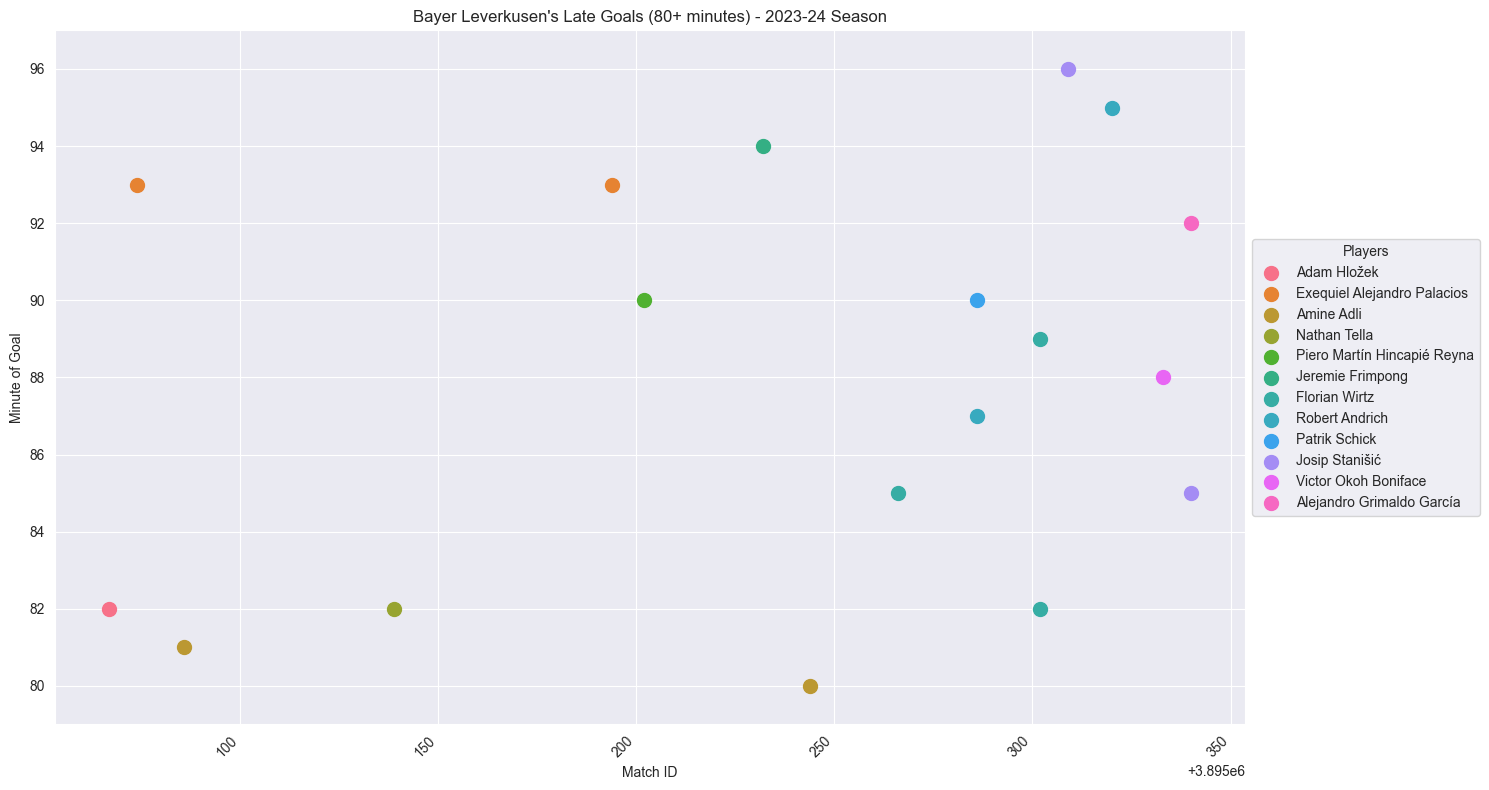

In [268]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming late_goals is your DataFrame with the late goals data

# Create a color map for players
players = late_goals['player'].unique()
color_map = dict(zip(players, sns.color_palette("husl", n_colors=len(players))))

# Create the plot
plt.figure(figsize=(15, 8))

# Plot each goal
for _, goal in late_goals.iterrows():
    plt.scatter(goal['match_id'], goal['minute'], 
                color=color_map[goal['player']], 
                s=100, 
                label=goal['player'])

# Remove duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Players", 
           loc='center left', bbox_to_anchor=(1, 0.5))

# Set labels and title
plt.xlabel('Match ID')
plt.ylabel('Minute of Goal')
plt.title("Bayer Leverkusen's Late Goals (80+ minutes) - 2023-24 Season")

# Set y-axis limits
plt.ylim(79, 97)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Show the plot
plt.show()

/var/folders/5l/_w0625xs2ldb8v6t7h_d5hrh0000gn/T/ipykernel_88916/3327500653.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  late_goals['interval'] = pd.cut(late_goals['minute'], bins=bins, labels=labels, right=False)


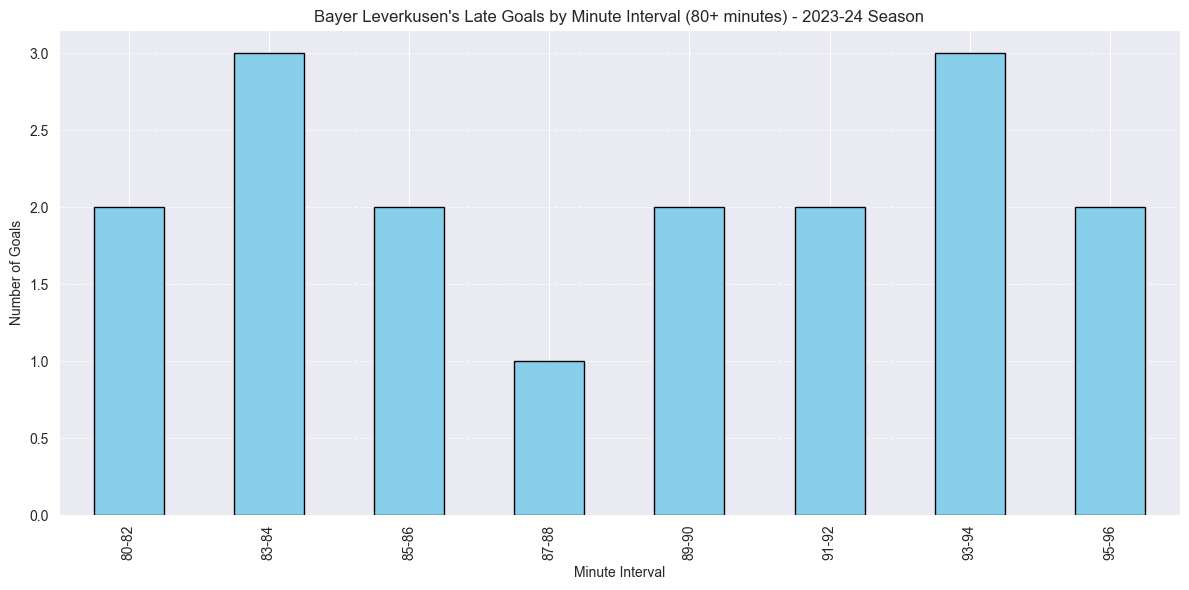

In [270]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming late_goals is your DataFrame with the late goals data

# Define the intervals
bins = [80, 82, 84, 86, 88, 90, 92, 94, 96]
labels = ['80-82', '83-84', '85-86', '87-88', '89-90', '91-92', '93-94', '95-96']

# Create a new column for the interval
late_goals['interval'] = pd.cut(late_goals['minute'], bins=bins, labels=labels, right=False)

# Count the number of goals in each interval
interval_counts = late_goals['interval'].value_counts().sort_index()

# Create the bar plot
plt.figure(figsize=(12, 6))
interval_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Set labels and title
plt.xlabel('Minute Interval')
plt.ylabel('Number of Goals')
plt.title("Bayer Leverkusen's Late Goals by Minute Interval (80+ minutes) - 2023-24 Season")

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()